In [2]:
## Necessary for running locally (Natascha's laptop)
## Make sure running in amiga_env

import sys

sys.path.append('/Users/nataschaspahr/code/aisynbiopipeline/aisynbiopipeline/workflows')

In [52]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [107]:
from roboticALE import load_and_verify_plate_layout

layout = load_and_verify_plate_layout(
    '/Users/nataschaspahr/data/robotic_OD_data/TFMN4_CHANGEDATE/plate_layout.csv'
)

layout


,Name,Experiment,Type,Condition,Strain name,Transforming DNA,Protocol,Parent sample,Replicate samples,Plate name,Microtiter plate well,Plotting group,Plotting group name,Blank
0,NaN,TFMN4,mt_plate,Pyruvate 20 mM + Kan,NaN,NaN,NaN,NaN,NaN,exp1,A1,NaN,\nPyruvate 20 mM + Kan,True
1,NaN,TFMN4,mt_plate,Pyruvate 20 mM + Kan,NaN,NaN,NaN,NaN,NaN,exp1,A2,NaN,\nPyruvate 20 mM + Kan,True
2,NaN,TFMN4,mt_plate,Pyruvate 20 mM + Kan,NaN,NaN,NaN,NaN,NaN,exp1,A3,NaN,\nPyruvate 20 mM + Kan,True
3,NaN,TFMN4,mt_plate,Pyruvate 20 mM + Kan,NaN,NaN,NaN,NaN,NaN,exp1,A4,NaN,\nPyruvate 20 mM + Kan,True
4,NaN,TFMN4,mt_plate,Pyruvate 20 mM + Kan,NaN,NaN,NaN,NaN,NaN,exp1,A5,NaN,\nPyruvate 20 mM + Kan,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,NaN,TFMN4,mt_plate,Methoxybenzoate 4 mM + Kan,NaN,NaN,NaN,NaN,NaN,exp2,H8,NaN,\nMethoxybenzoate 4 mM + Kan,True
188,NaN,TFMN4,mt_plate,Methoxybenzoate 4 mM + Kan,NaN,NaN,NaN,NaN,NaN,exp2,H9,NaN,\nMethoxybenzoate 4 mM + Kan,True
189,NaN,TFMN4,mt_plate,Methoxybenzoate 4 mM + Kan,NaN,NaN,NaN,NaN,NaN,exp2,H10,NaN,\nMethoxybenzoate 4 mM + Kan,True
190,NaN,TFMN4,mt_plate,Methoxybenzoate 4 mM + Kan,NaN,NaN,NaN,NaN,NaN,exp2,H11,NaN,\nMethoxybenzoate 4 mM + Kan,True


In [108]:
from roboticALE import load_and_verify_robotic_od_data

fname_pattern = r'(?P<experiment>\w+)_(?P<timestamp>\d+)_(?P<uniqueID>\w+)_(?P<series>\w+)_(?P<transfer>\d+)_(?P<timepoint>\w+).txt'

files = load_and_verify_robotic_od_data(
    '/Users/nataschaspahr/data/robotic_OD_data/TFMN4_CHANGEDATE', 
    fname_pattern,
)

In [129]:
from roboticALE import extract_robotic_od_data_to_df

data = extract_robotic_od_data_to_df(files, fname_pattern)

data

,filename,experiment,file_ID,timestamp,series,plate_index,transfer,reading,row,column,od,well,datetime
0,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,0,0.034,A1,2026-02-16T00:32:30
1,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,1,0.034,A2,2026-02-16T00:32:30
2,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,2,0.035,A3,2026-02-16T00:32:30
3,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,3,0.035,A4,2026-02-16T00:32:30
4,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,4,0.036,A5,2026-02-16T00:32:30
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21499,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1770745901,exp1,6,6,T20,7,7,0.031,H8,2026-02-10T12:51:41
21500,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1770745901,exp1,6,6,T20,7,8,0.032,H9,2026-02-10T12:51:41
21501,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1770745901,exp1,6,6,T20,7,9,0.032,H10,2026-02-10T12:51:41
21502,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1770745901,exp1,6,6,T20,7,10,0.033,H11,2026-02-10T12:51:41


In [130]:
from roboticALE import map_plate_layout_to_data

data = map_plate_layout_to_data(data, layout)
data


,filename,experiment,file_ID,timestamp,series,plate_index,transfer,reading,row,column,...,Strain name,Transforming DNA,Protocol,Parent sample,Replicate samples,Plate name,Microtiter plate well,Plotting group,Plotting group name,Blank
0,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,0,...,NaN,NaN,NaN,NaN,NaN,exp1,A1,NaN,\nPyruvate 20 mM + Kan,True
1,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,1,...,NaN,NaN,NaN,NaN,NaN,exp1,A2,NaN,\nPyruvate 20 mM + Kan,True
2,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,2,...,NaN,NaN,NaN,NaN,NaN,exp1,A3,NaN,\nPyruvate 20 mM + Kan,True
3,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,3,...,NaN,NaN,NaN,NaN,NaN,exp1,A4,NaN,\nPyruvate 20 mM + Kan,True
4,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,4,...,NaN,NaN,NaN,NaN,NaN,exp1,A5,NaN,\nPyruvate 20 mM + Kan,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21499,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1770745901,exp1,6,6,T20,7,7,...,NaN,NaN,NaN,NaN,NaN,exp1,H8,NaN,\nPyruvate 20 mM + Kan,True
21500,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1770745901,exp1,6,6,T20,7,8,...,NaN,NaN,NaN,NaN,NaN,exp1,H9,NaN,\nPyruvate 20 mM + Kan,True
21501,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1770745901,exp1,6,6,T20,7,9,...,NaN,NaN,NaN,NaN,NaN,exp1,H10,NaN,\nPyruvate 20 mM + Kan,True
21502,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1770745901,exp1,6,6,T20,7,10,...,NaN,NaN,NaN,NaN,NaN,exp1,H11,NaN,\nPyruvate 20 mM + Kan,True


In [135]:
data.columns

Index(['filename', 'experiment', 'file_ID', 'timestamp', 'series',
       'plate_index', 'transfer', 'reading', 'row', 'column', 'od', 'well',
       'datetime', 'Name', 'Experiment', 'Type', 'Condition', 'Strain name',
       'Transforming DNA', 'Protocol', 'Parent sample', 'Replicate samples',
       'Plate name', 'Microtiter plate well', 'Plotting group',
       'Plotting group name', 'Blank', 'background', 'innoculation_timestamp',
       'timepoint'],
      dtype='object')

In [132]:
from roboticALE import compute_background, compute_inoculation

data = compute_background(data)
data = compute_inoculation(data)

data

,filename,experiment,file_ID,timestamp,series,plate_index,transfer,reading,row,column,...,Parent sample,Replicate samples,Plate name,Microtiter plate well,Plotting group,Plotting group name,Blank,background,innoculation_timestamp,timepoint
0,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,0,...,NaN,NaN,exp1,A1,NaN,\nPyruvate 20 mM + Kan,True,0.033333,2026-02-14T22:20:56,26.192778
1,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,1,...,NaN,NaN,exp1,A2,NaN,\nPyruvate 20 mM + Kan,True,0.033333,2026-02-14T22:20:56,26.192778
2,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,2,...,NaN,NaN,exp1,A3,NaN,\nPyruvate 20 mM + Kan,True,0.033333,2026-02-14T22:20:56,26.192778
3,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,3,...,NaN,NaN,exp1,A4,NaN,\nPyruvate 20 mM + Kan,True,0.033333,2026-02-14T22:20:56,26.192778
4,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1771219950,exp1,11,11,T24,0,4,...,NaN,NaN,exp1,A5,NaN,\nPyruvate 20 mM + Kan,True,0.033333,2026-02-14T22:20:56,26.192778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21499,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1770745901,exp1,6,6,T20,7,7,...,NaN,NaN,exp1,H8,NaN,\nPyruvate 20 mM + Kan,True,0.033694,2026-02-09T12:50:37,24.017778
21500,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1770745901,exp1,6,6,T20,7,8,...,NaN,NaN,exp1,H9,NaN,\nPyruvate 20 mM + Kan,True,0.033694,2026-02-09T12:50:37,24.017778
21501,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1770745901,exp1,6,6,T20,7,9,...,NaN,NaN,exp1,H10,NaN,\nPyruvate 20 mM + Kan,True,0.033694,2026-02-09T12:50:37,24.017778
21502,/Users/nataschaspahr/data/robotic_OD_data/TFMN...,TFMN3,01KH4ARRP85RKKXBF5SZKT7QF3,1770745901,exp1,6,6,T20,7,10,...,NaN,NaN,exp1,H11,NaN,\nPyruvate 20 mM + Kan,True,0.033694,2026-02-09T12:50:37,24.017778


In [136]:
from roboticALE import verify_and_write_processed_data

verify_and_write_processed_data(data)

In [137]:
import pandas as pd

# Test data
test = data.loc[
    (data['Blank'] == False) & (data['reading'] != 'contam') # exclude blanks and contam readings
]
# ][['experiment', 'Name', 'transfer', 'datetime', 'Strain name', 'Condition',
#     'Transforming DNA', 'Replicate samples', 'Plate name', 'Microtiter plate well', 
#     'od', 'background', 'column', 'row']
# ].sort_values(['Plate name', 'column', 'datetime'])

# test['Transforming DNA'] = test['Transforming DNA'].fillna('No DNA')

contam = data.loc[(data['reading'] == 'contam')]
blank = data.loc[(data['Blank'] == True)]

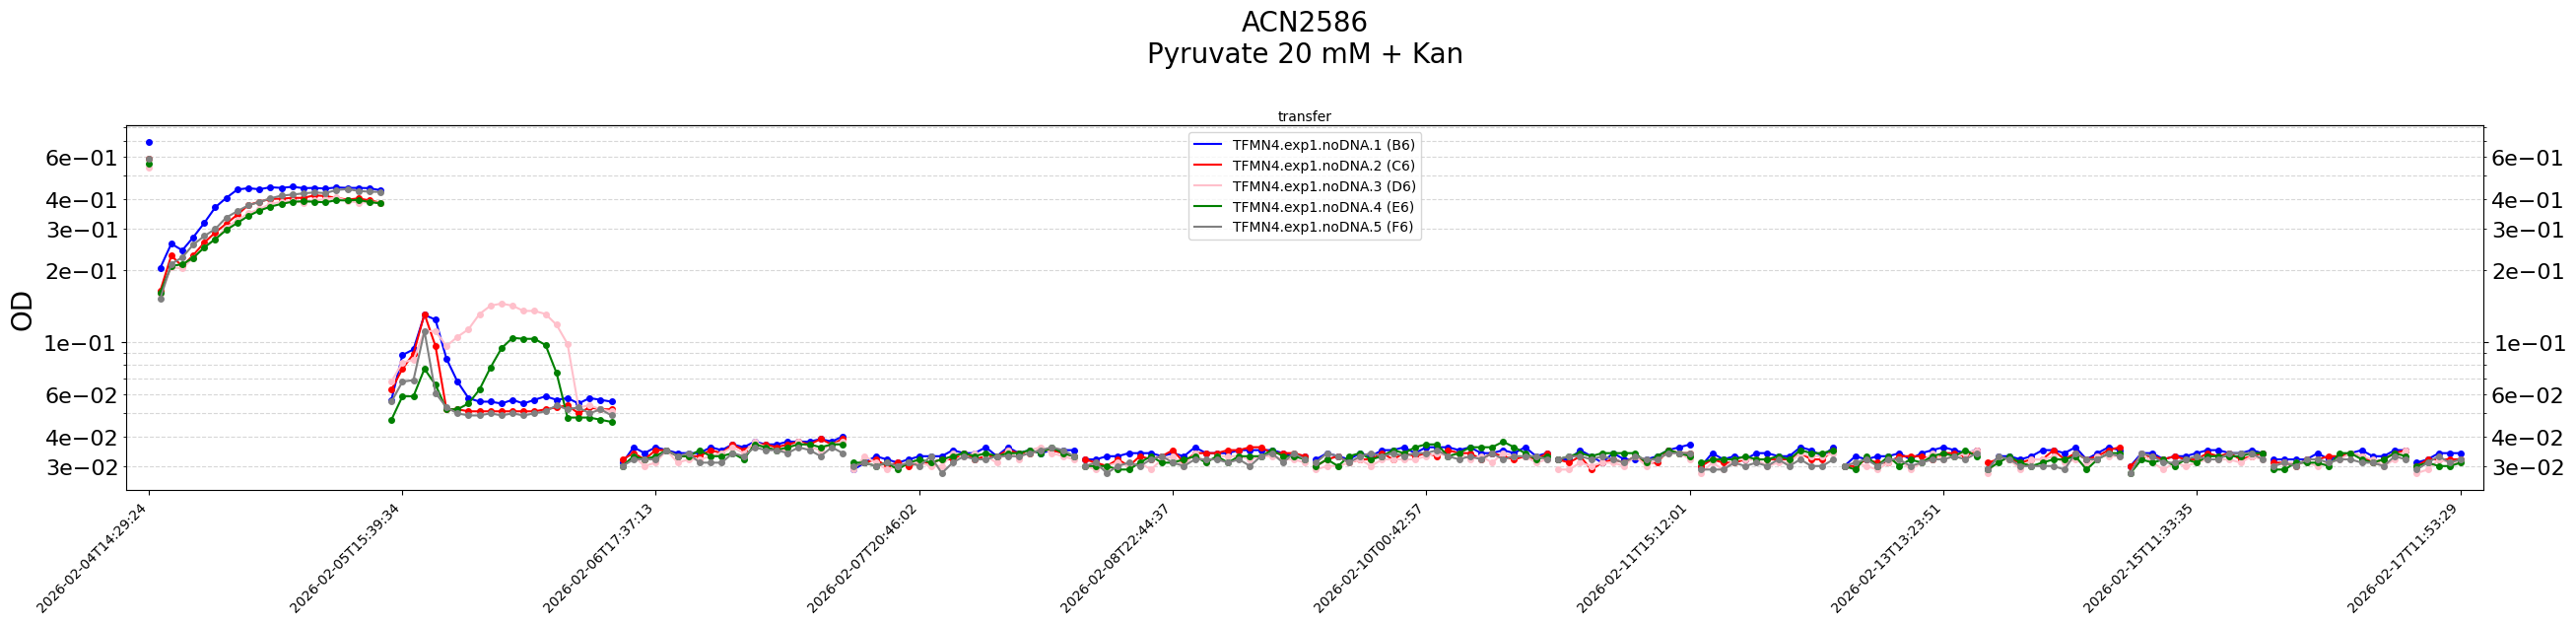

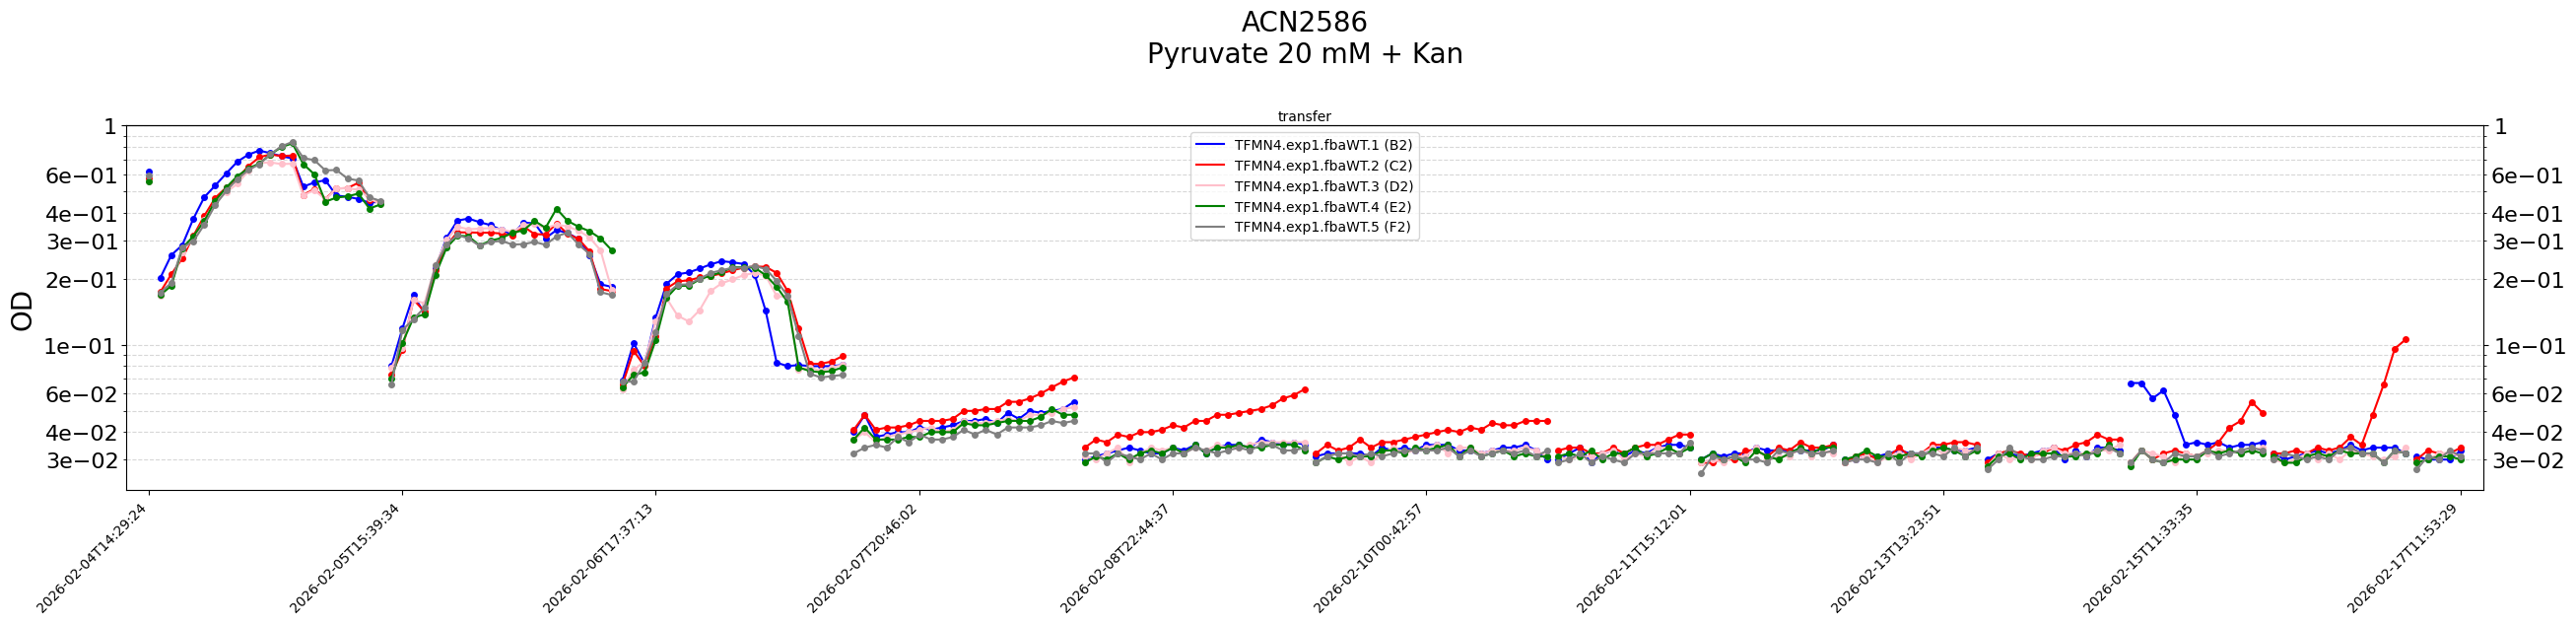

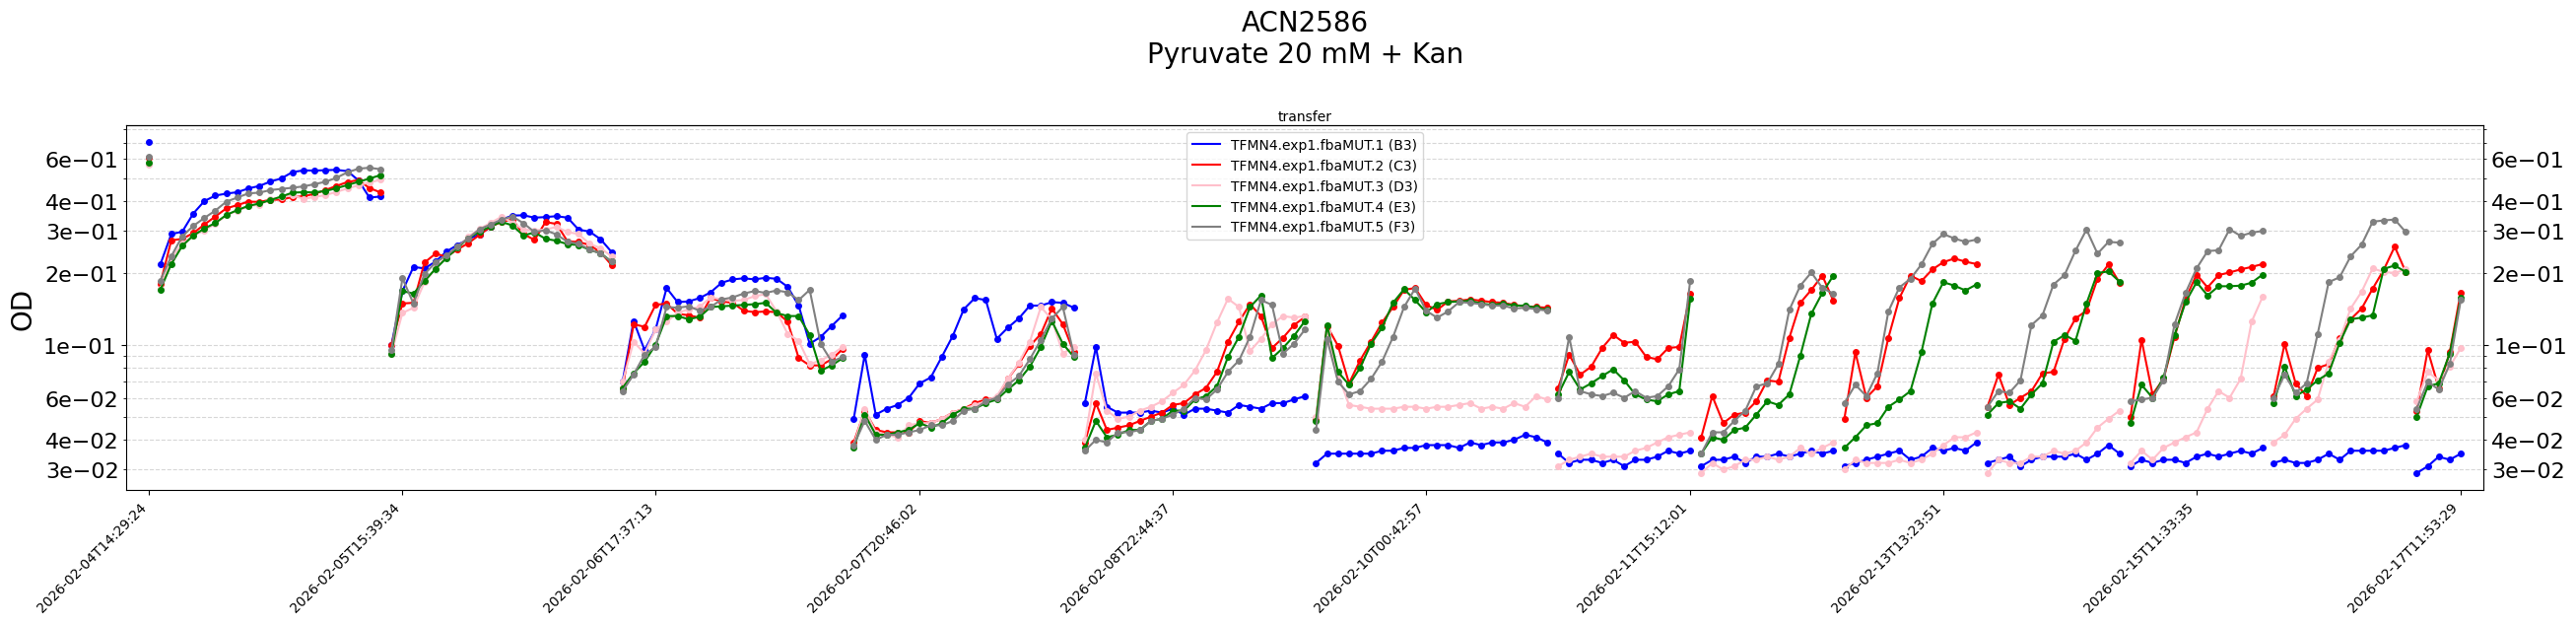

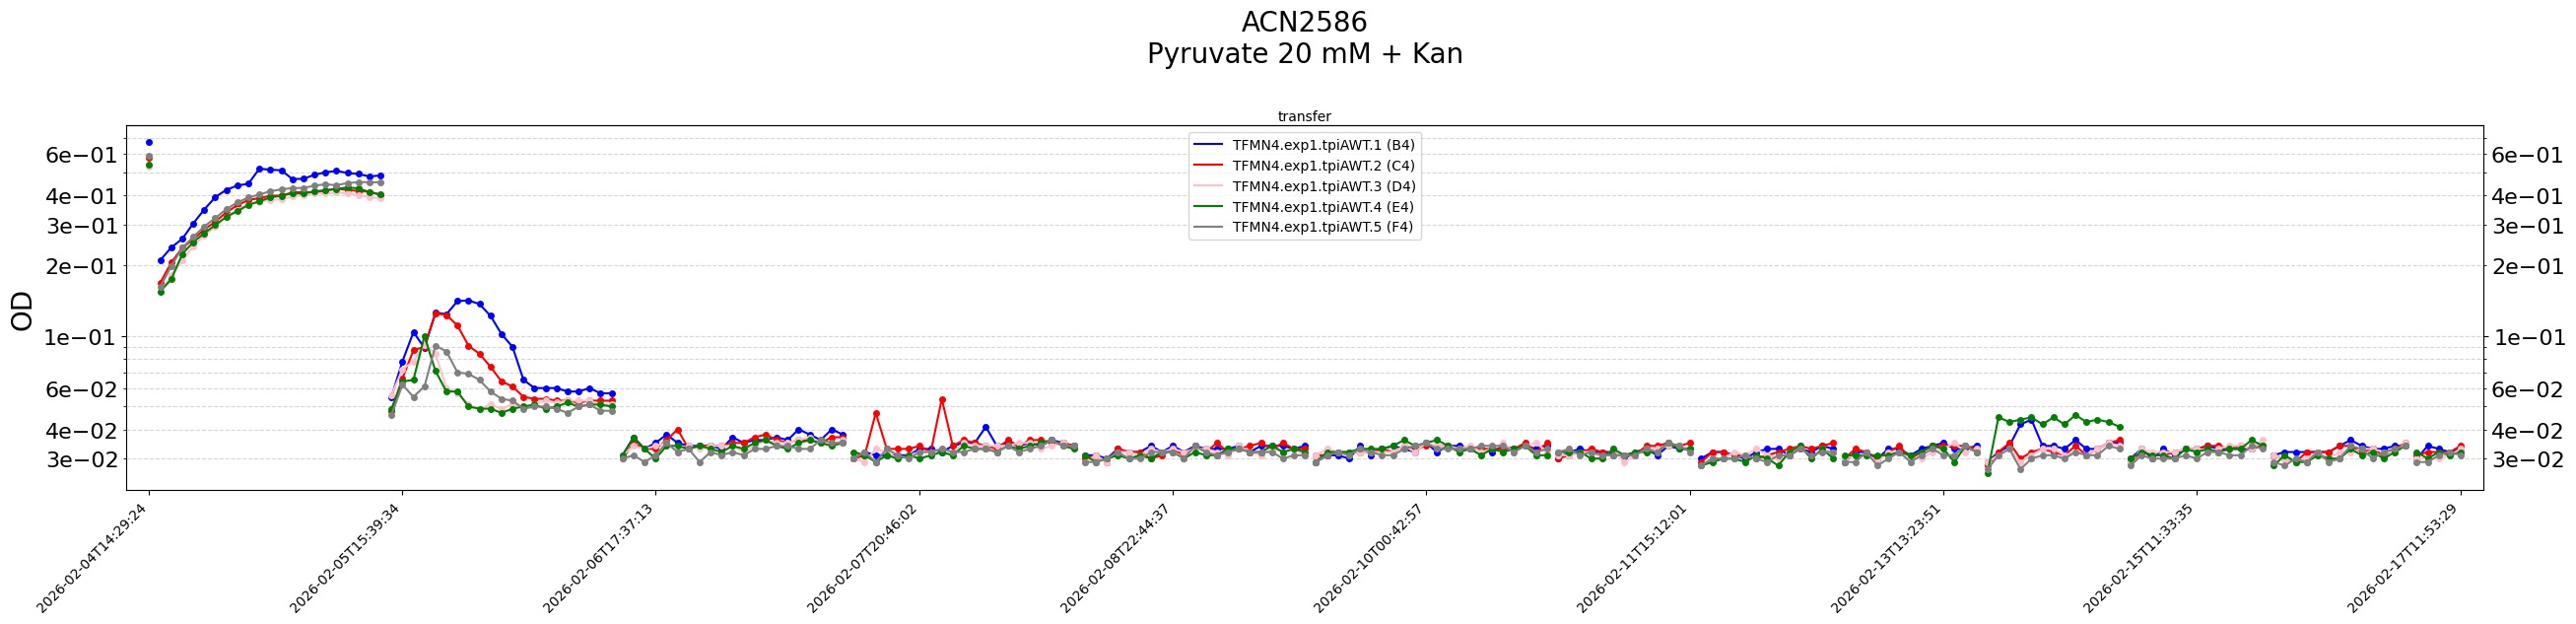

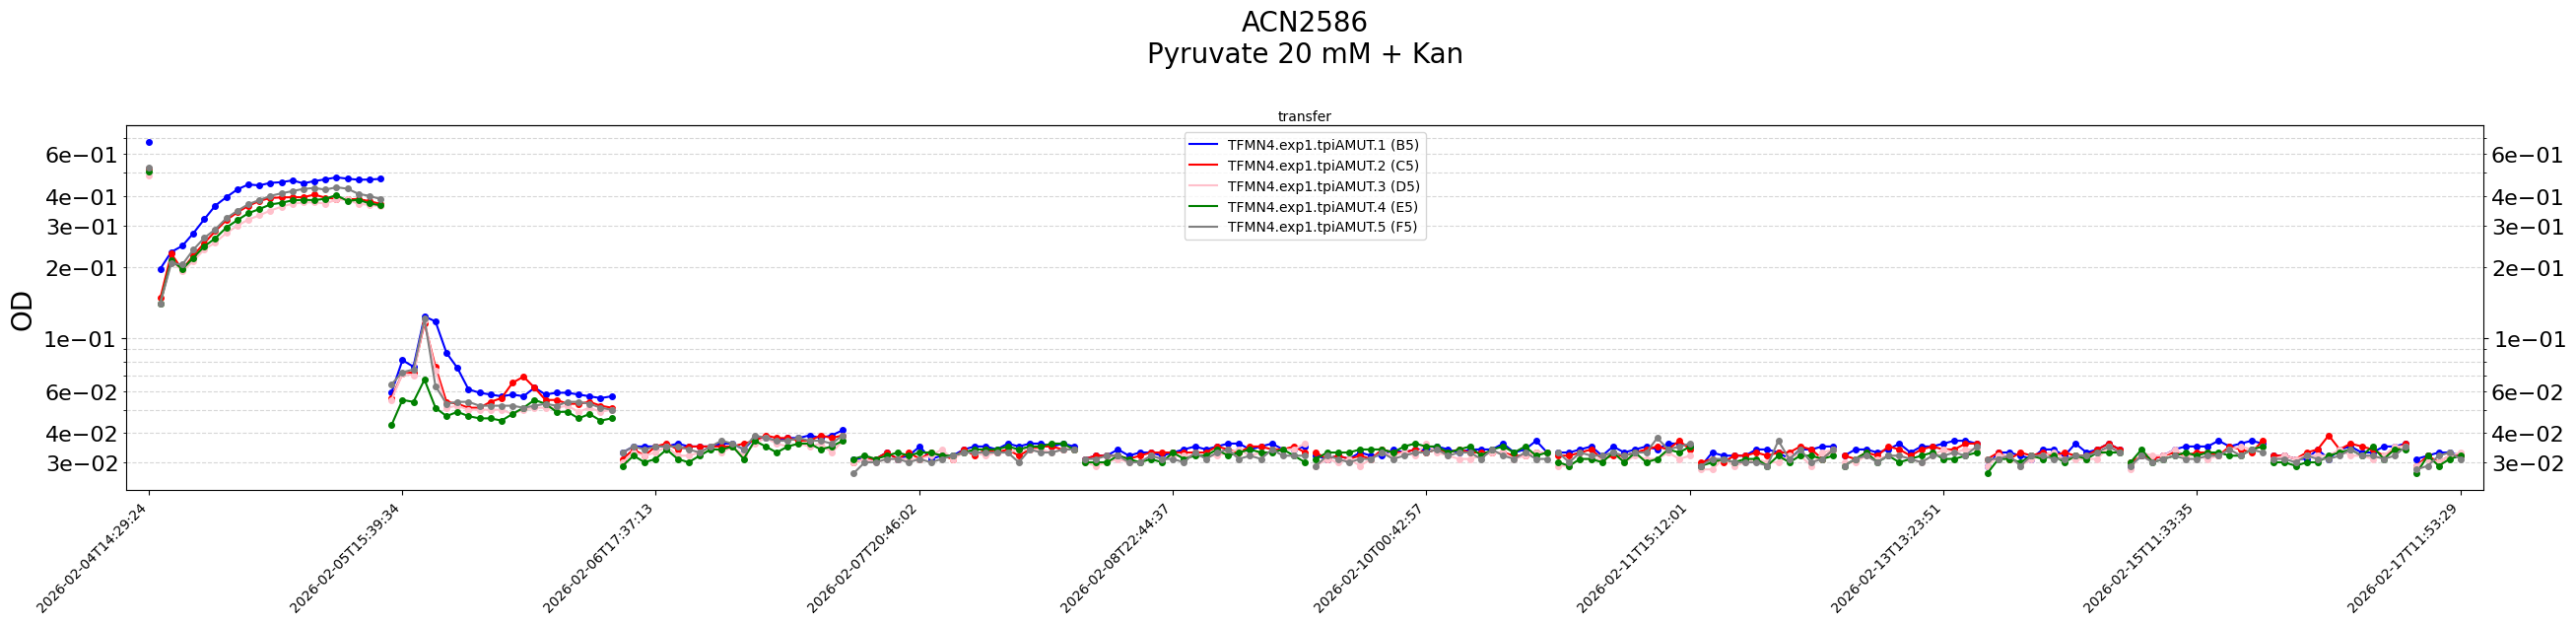

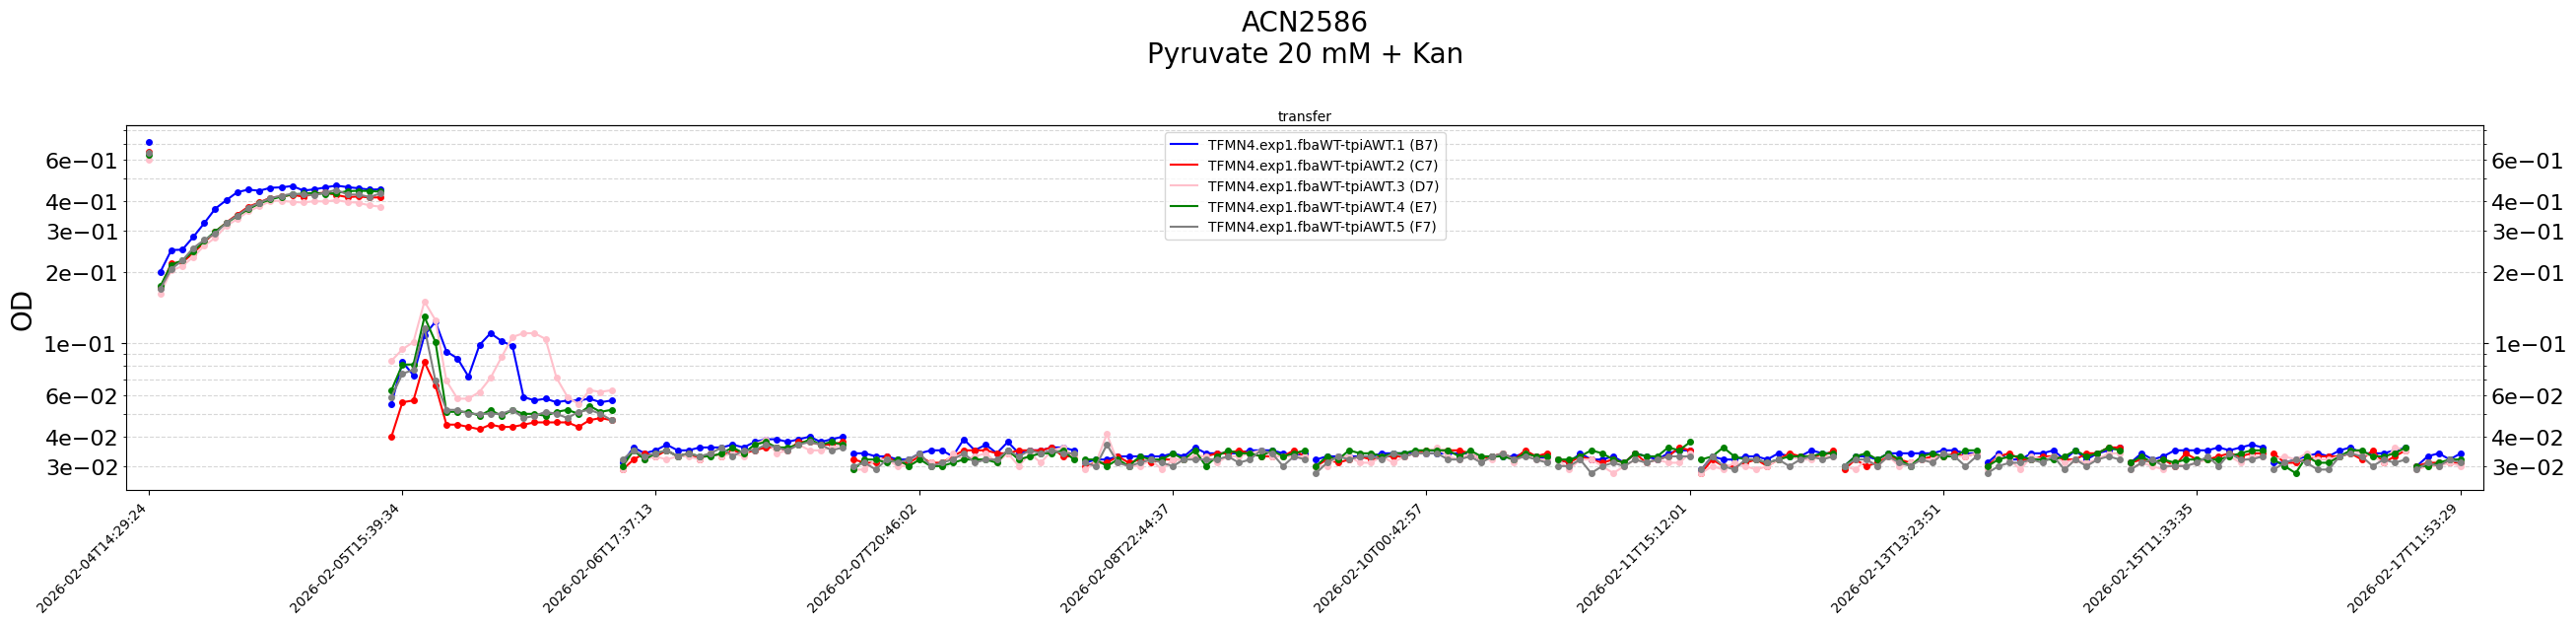

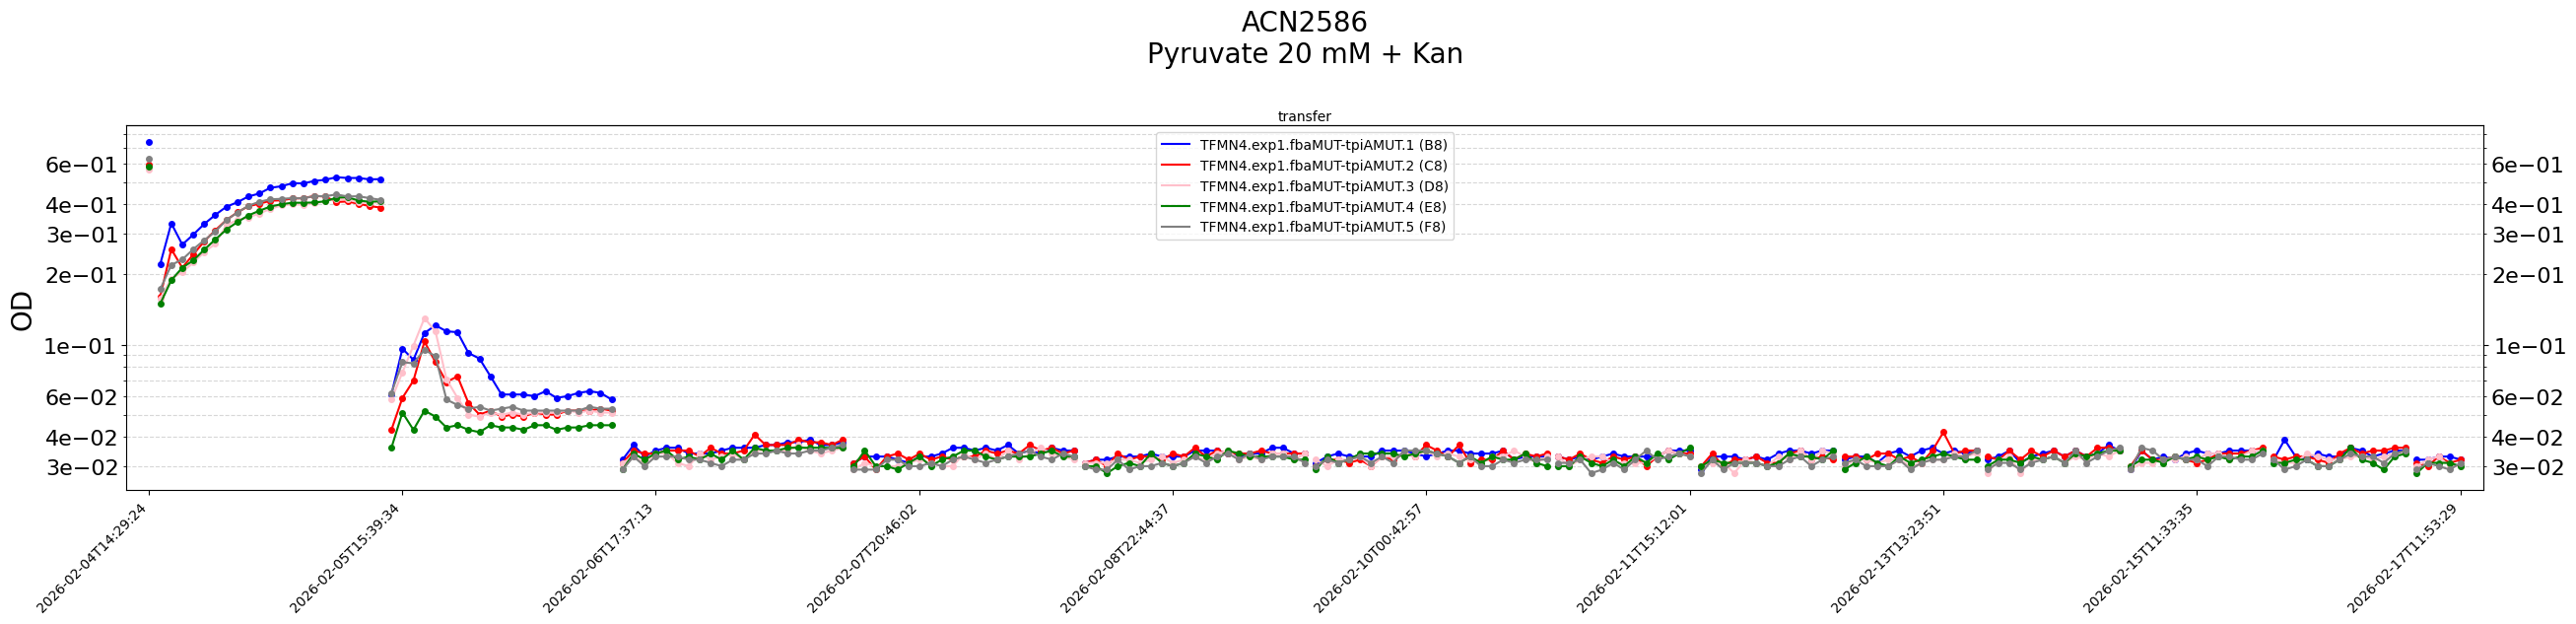

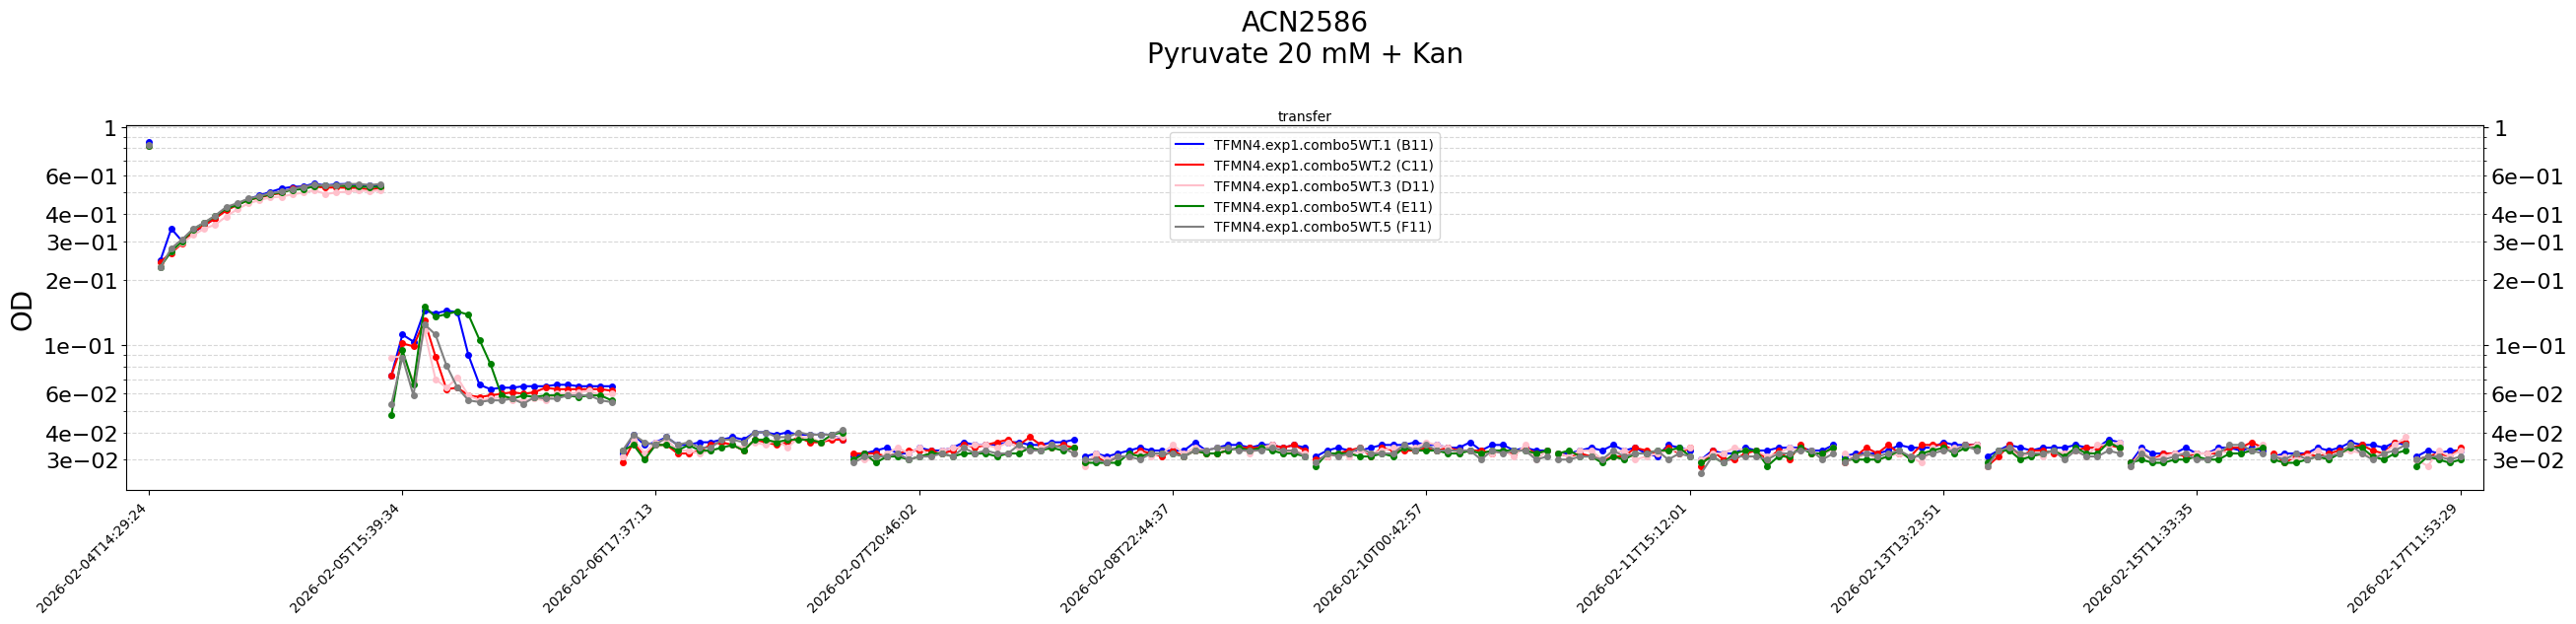

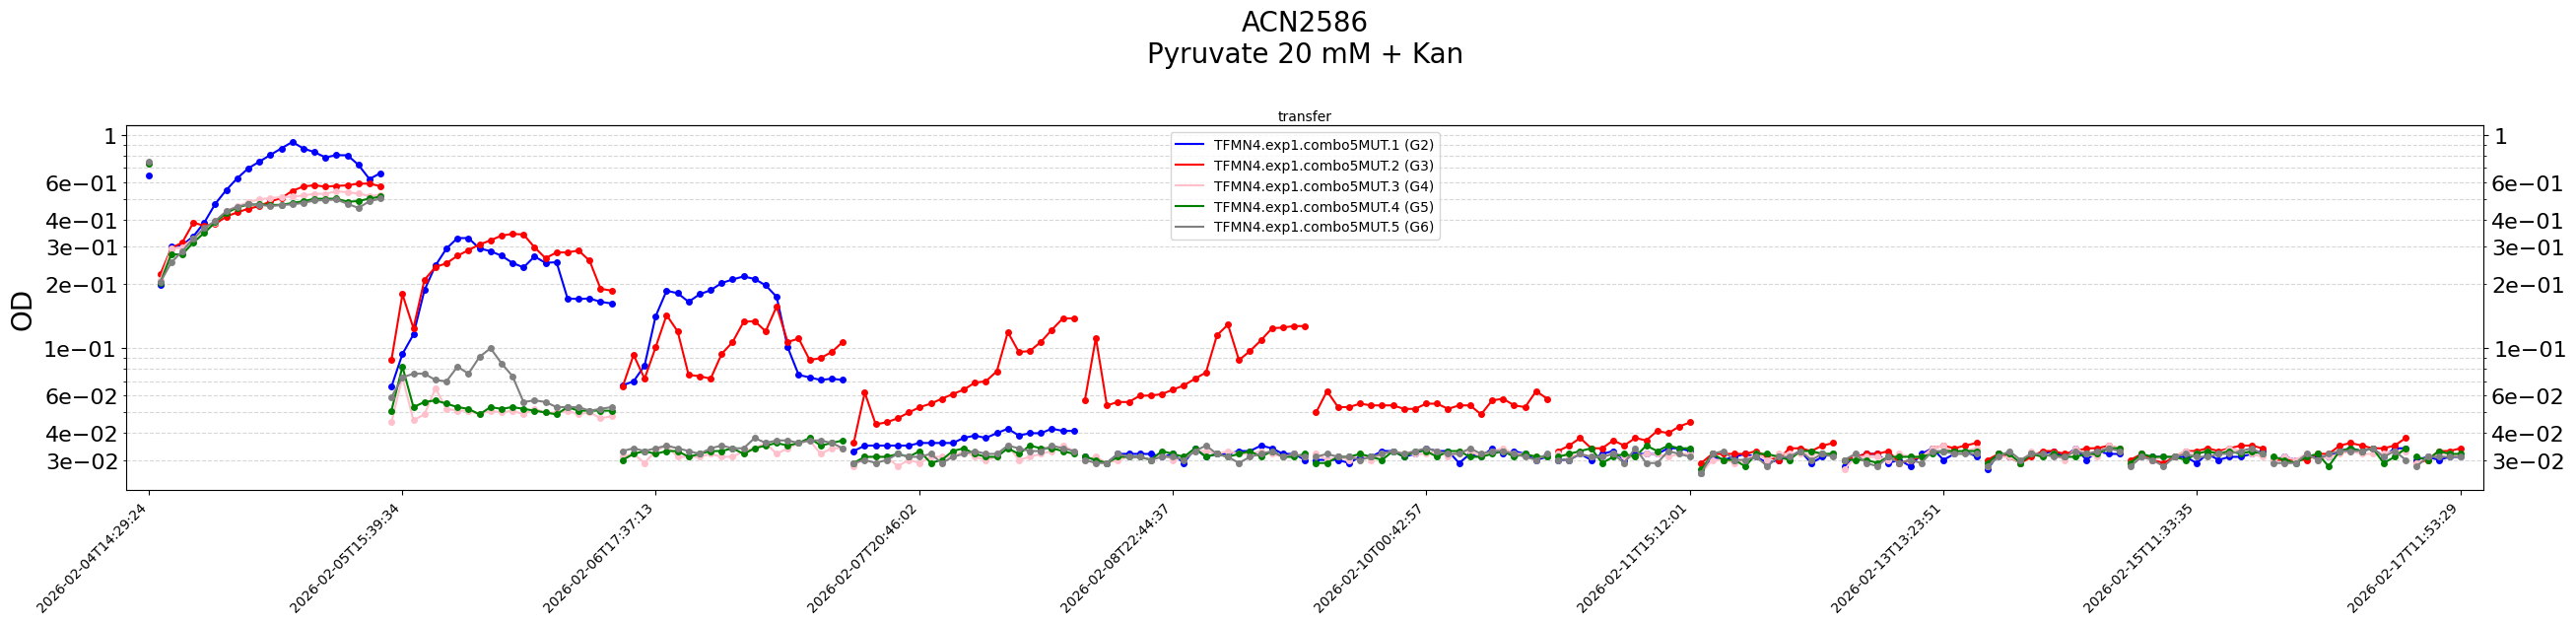

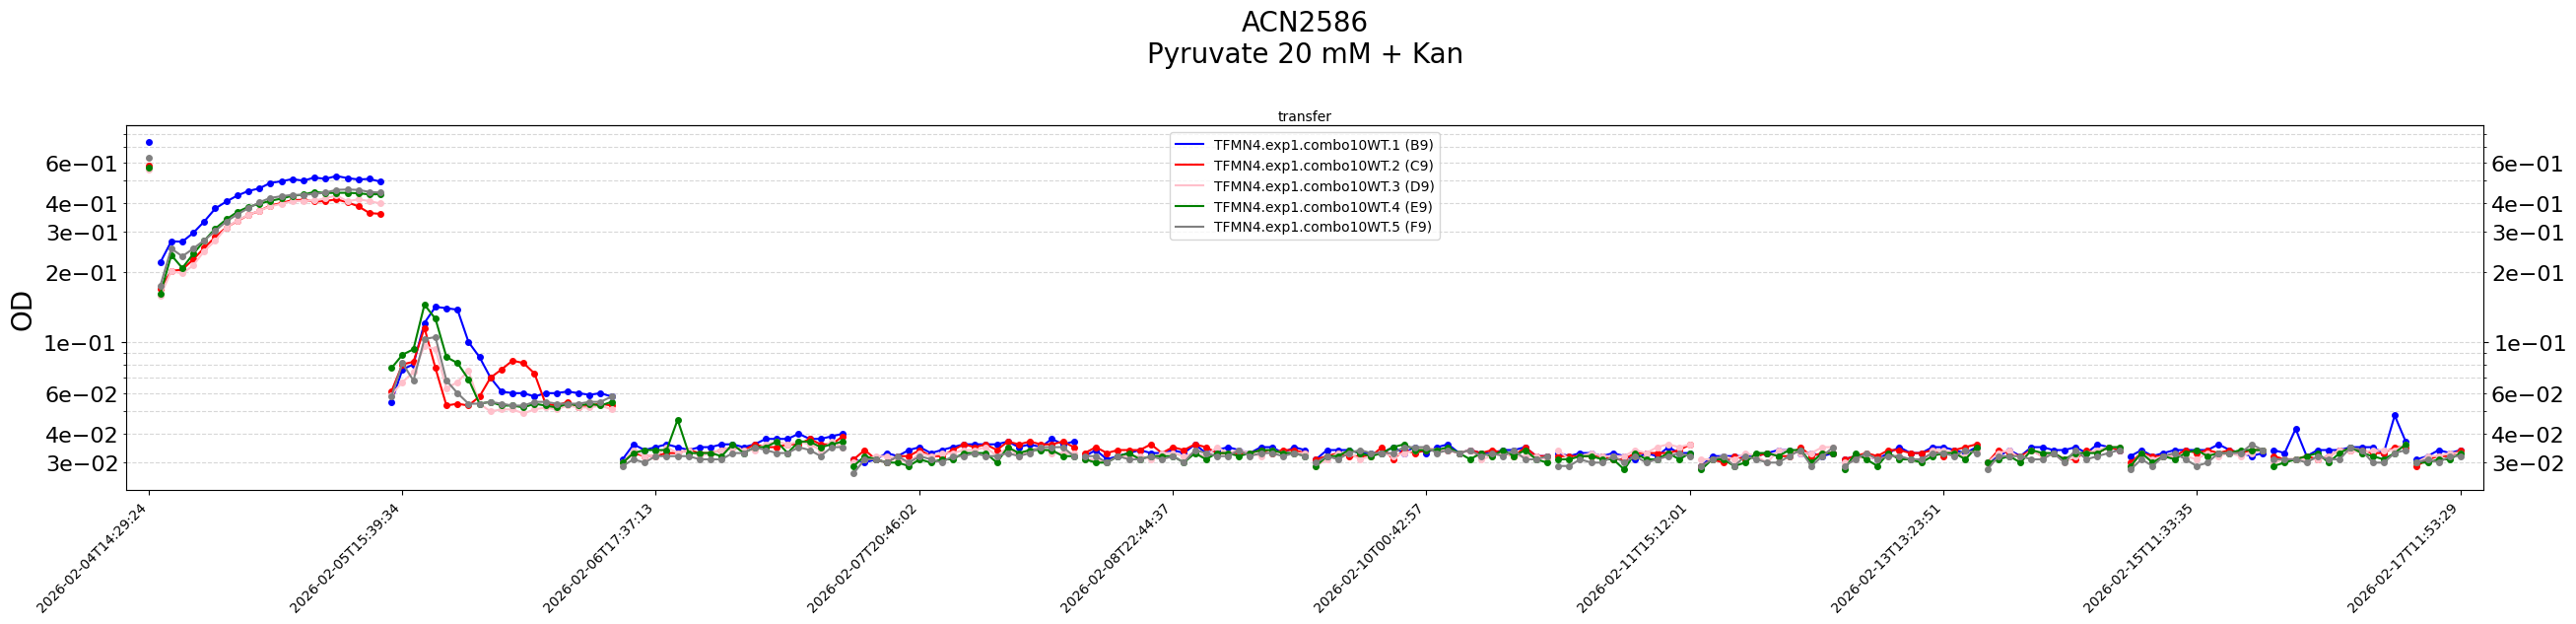

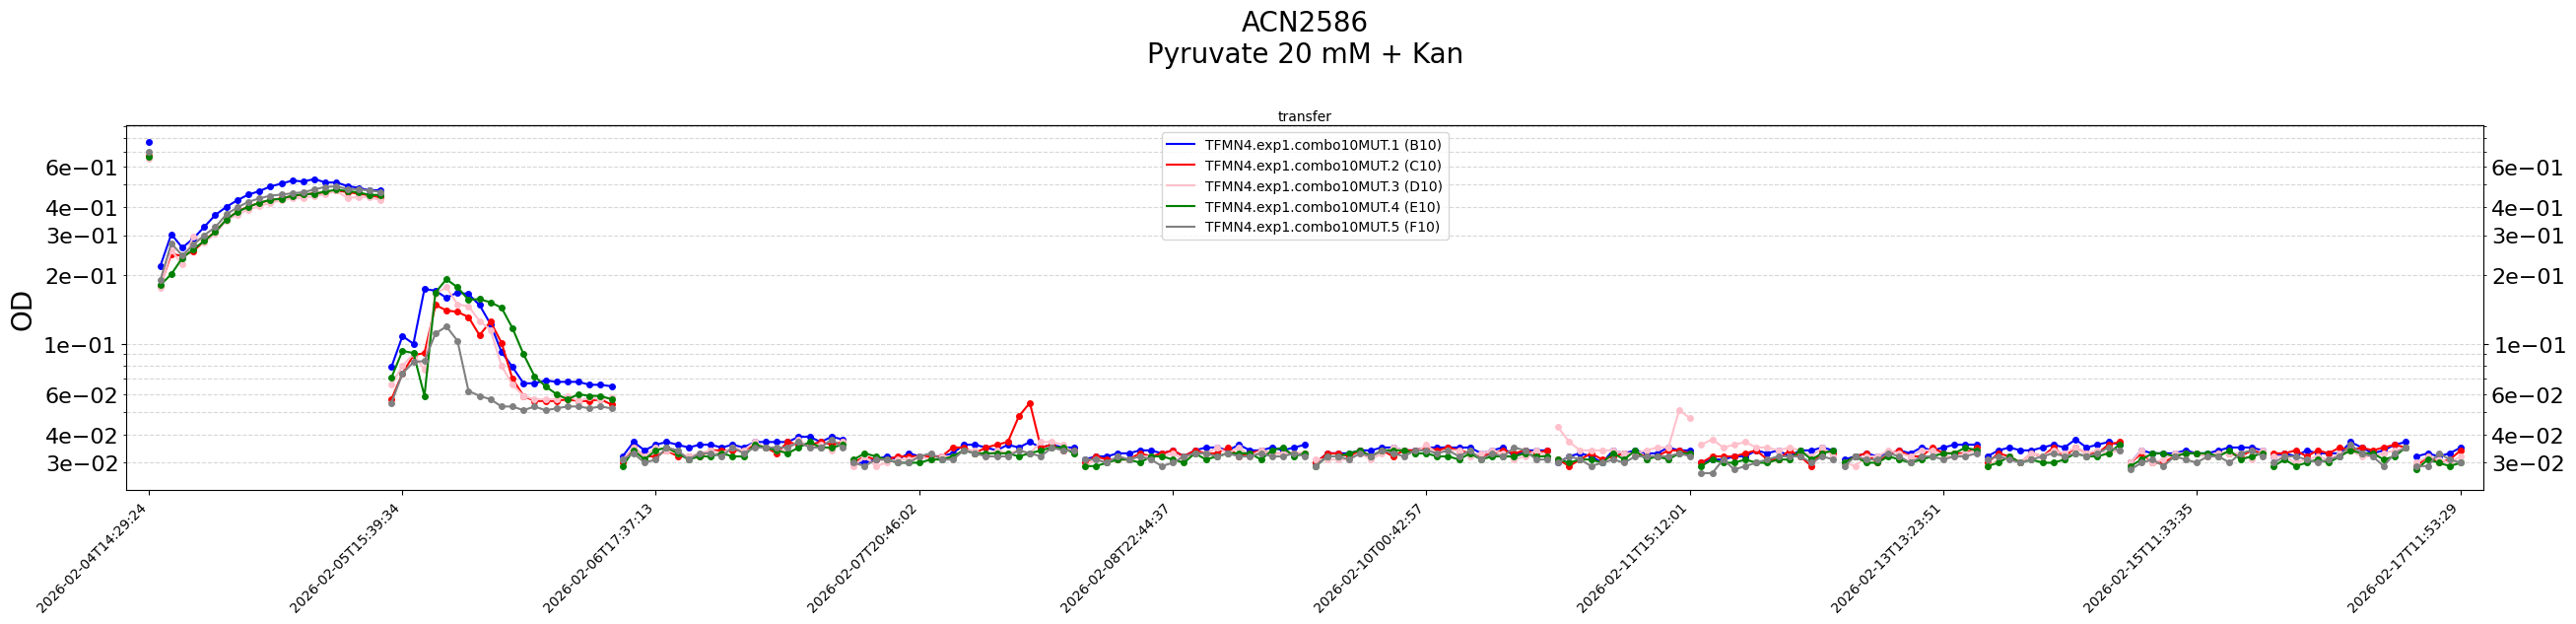

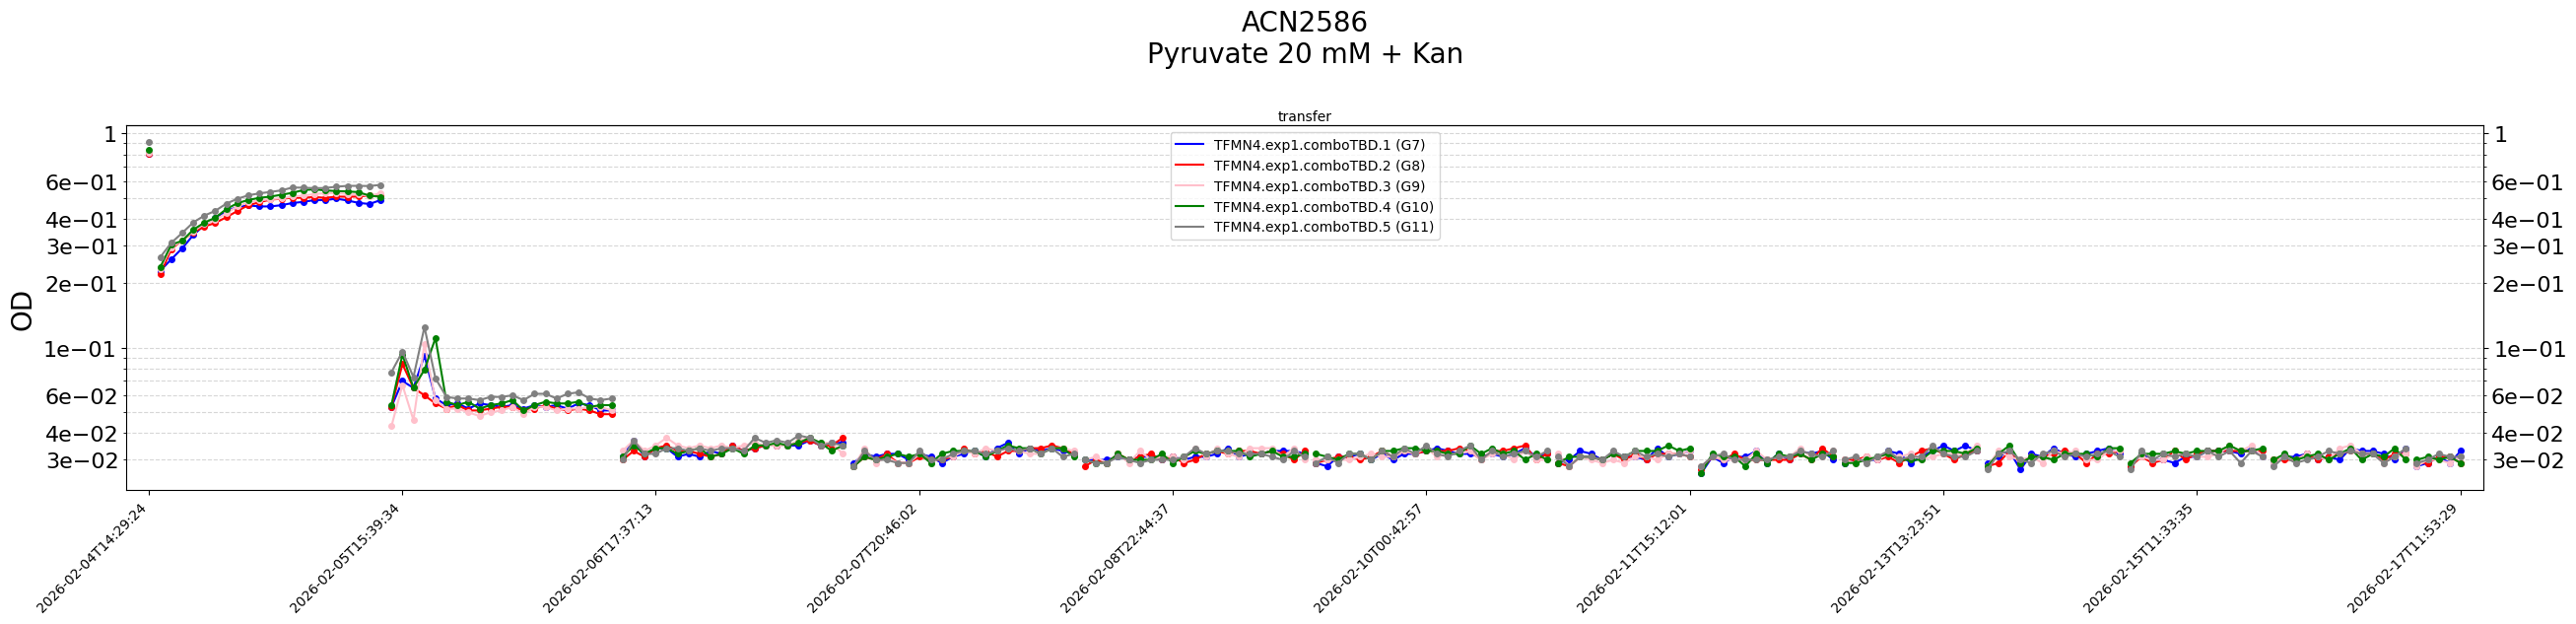

In [168]:
from growth_curve_plotting import plot_OD_replicates

for plate_name, exp in test.groupby('Plate name', sort=False):
    for name, group in exp.groupby(['Plotting group name','Plotting group']):
        plot_OD_replicates(group, subtract_background=False, blank=False,
                            yscale='log', append_title=name[0].replace(r"\n", "\n"), pdf=None)

        

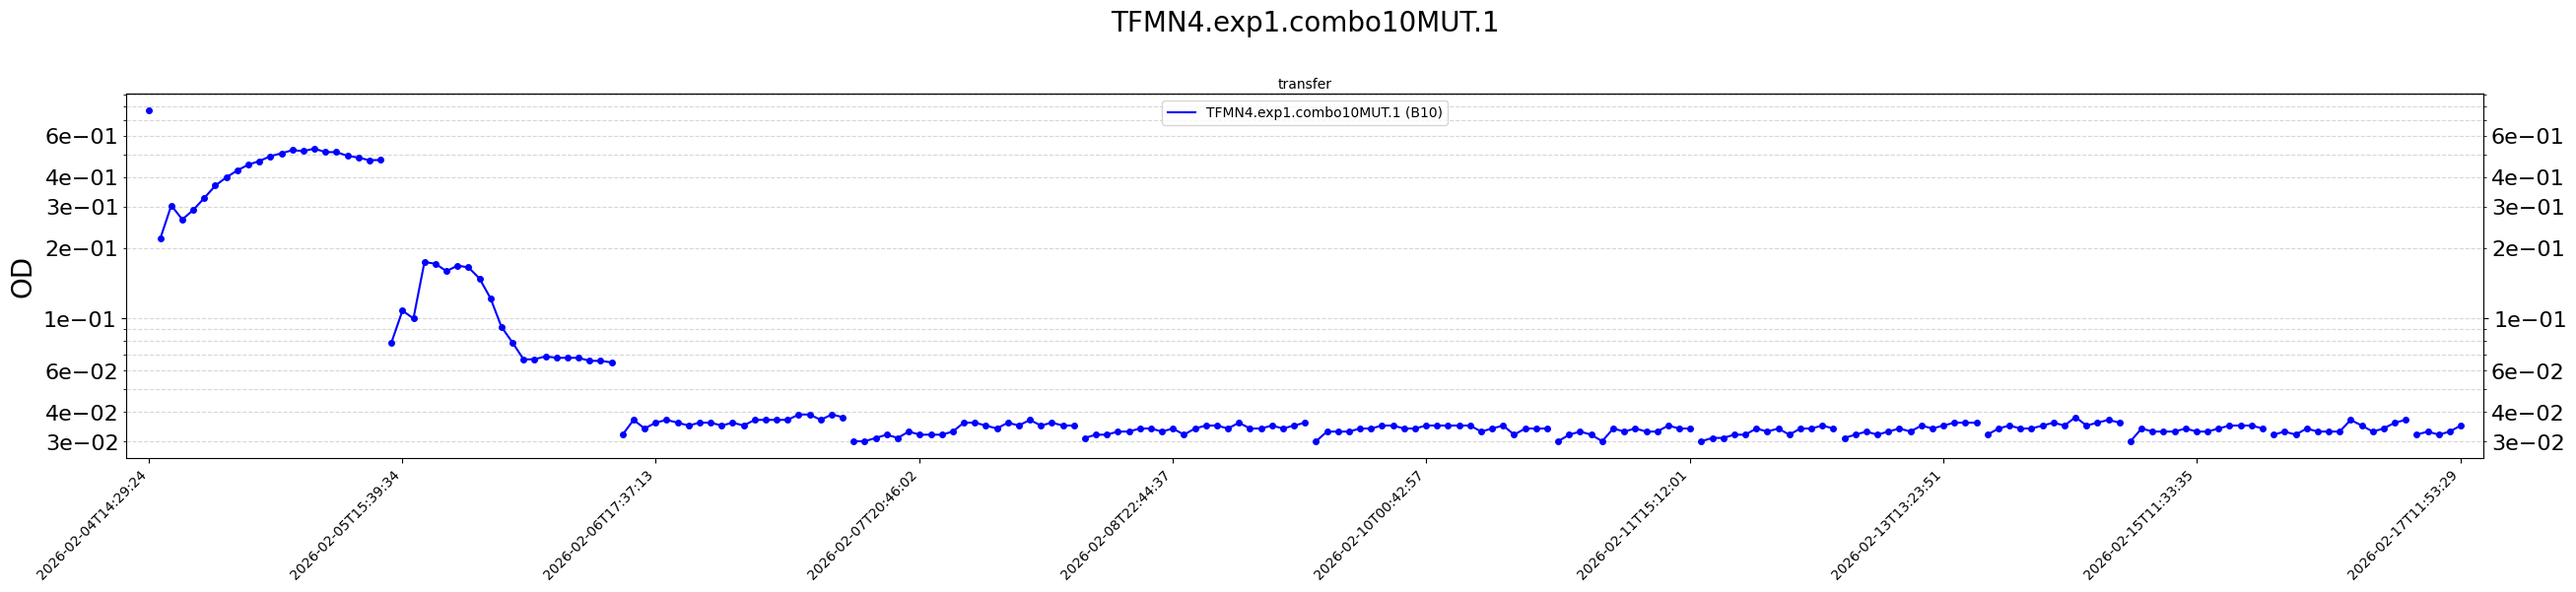

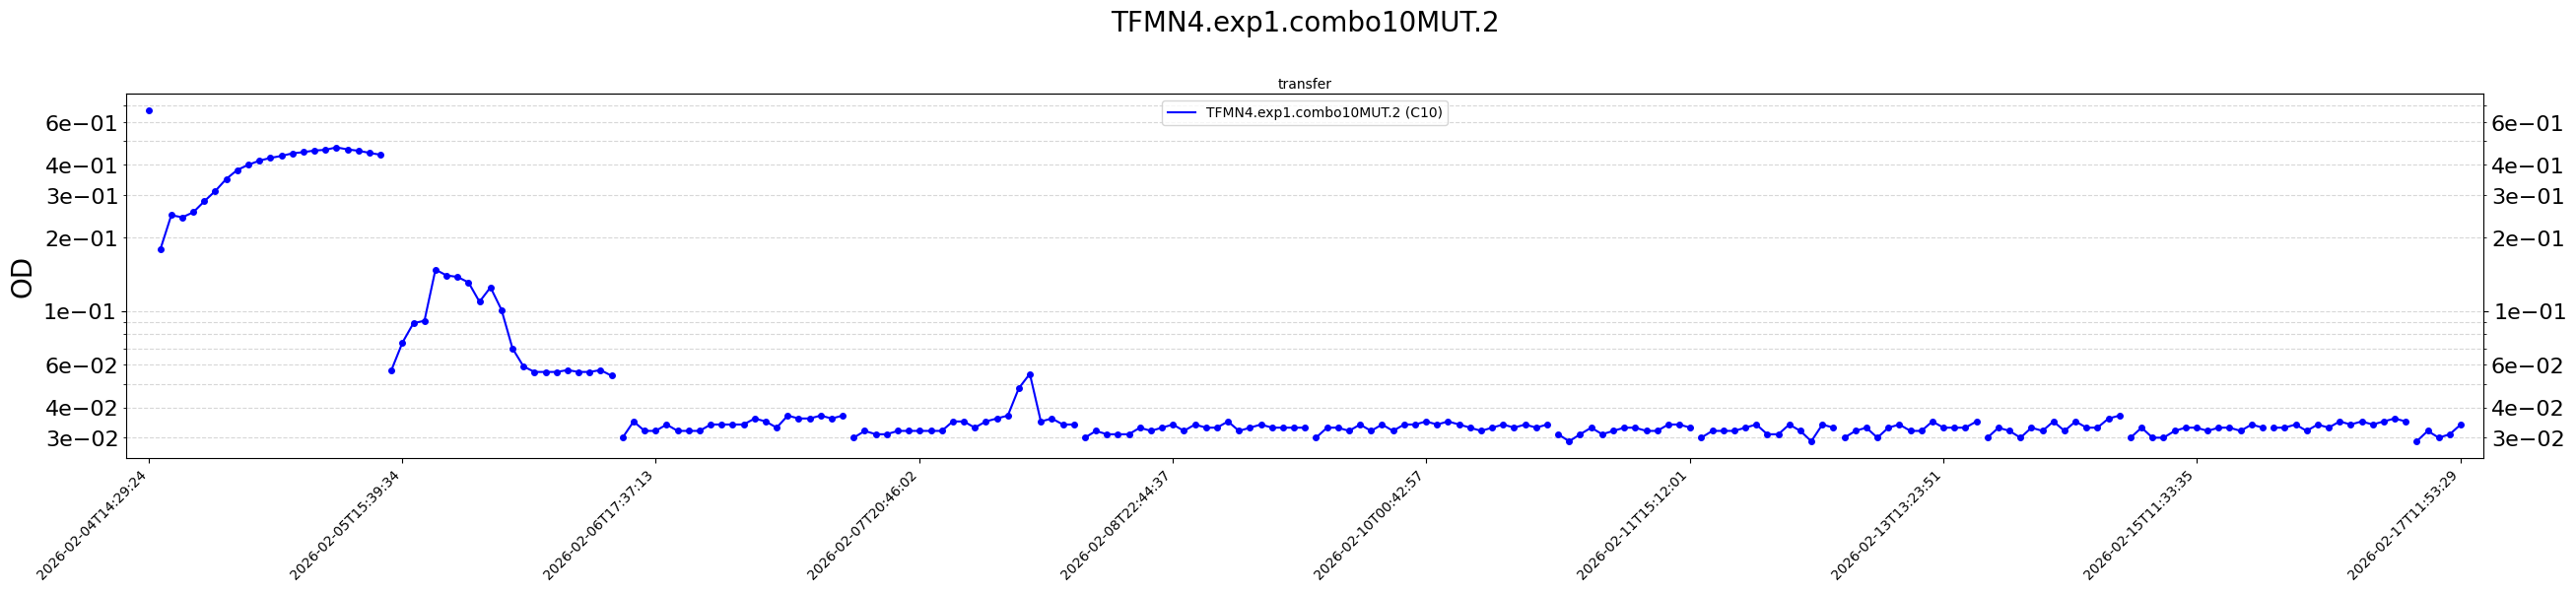

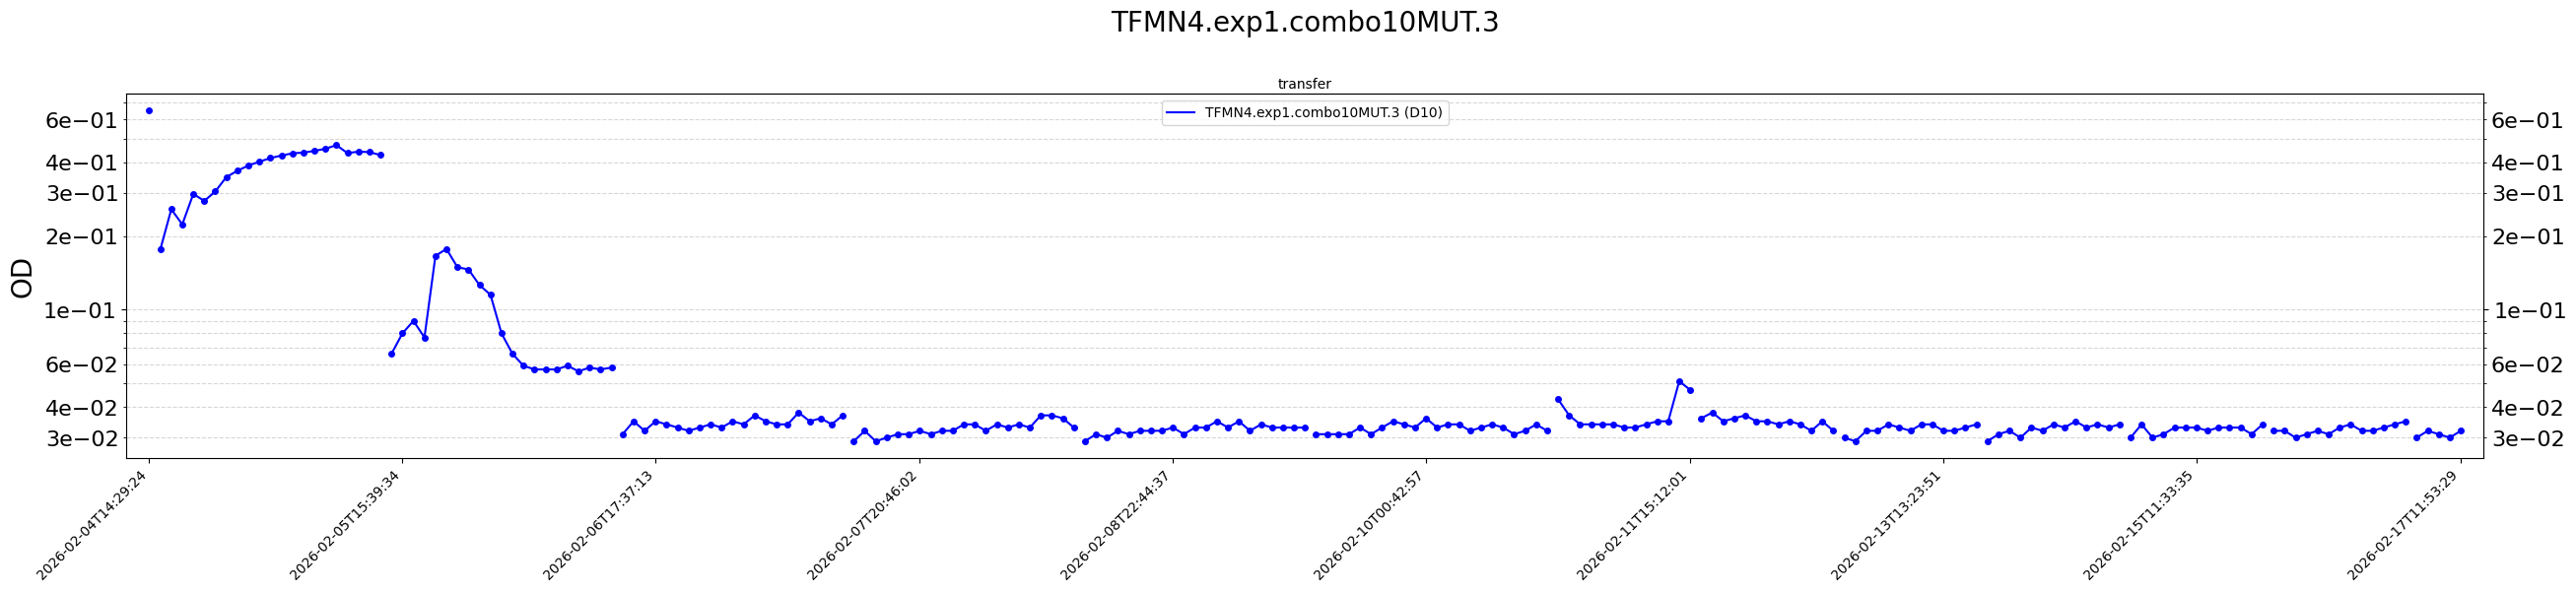

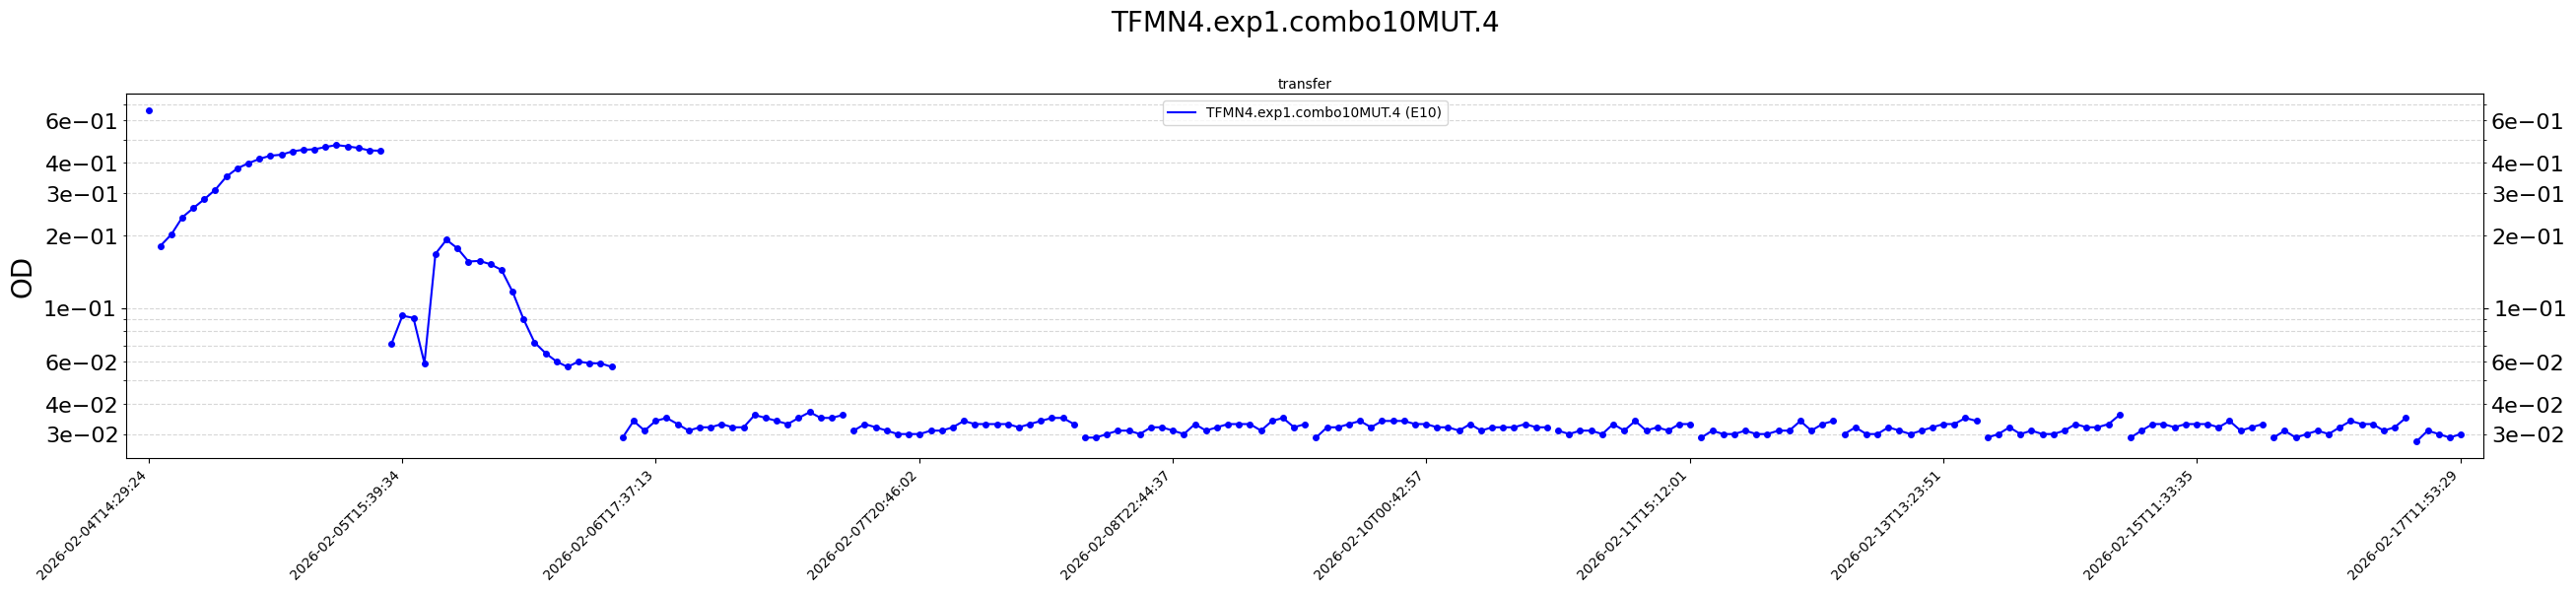

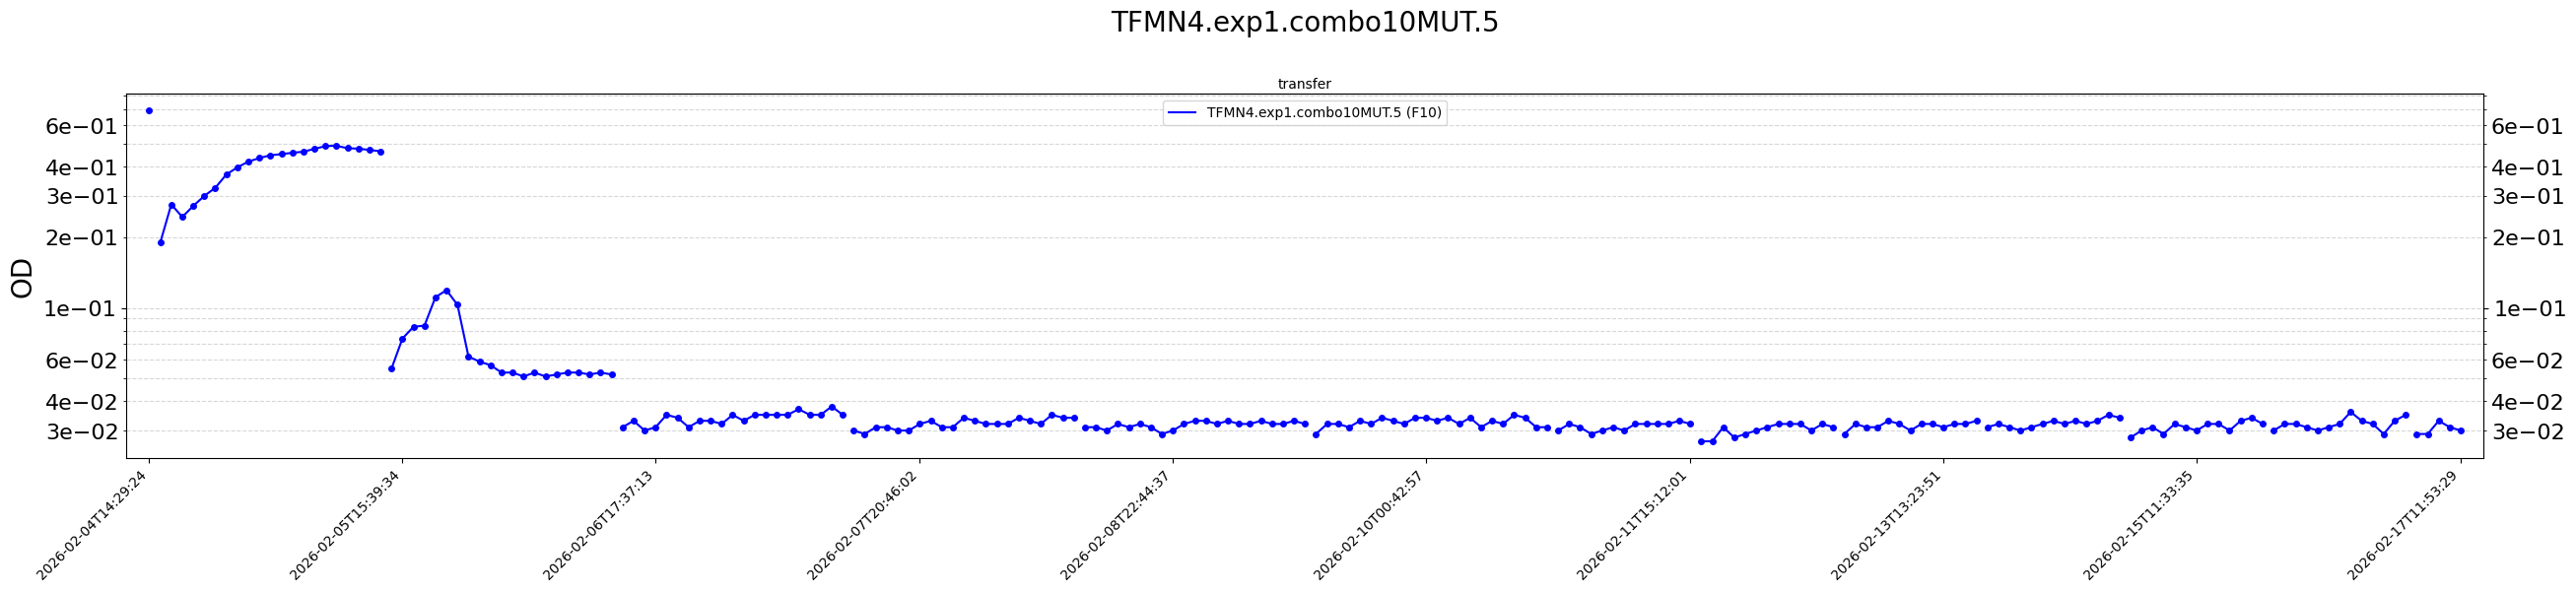

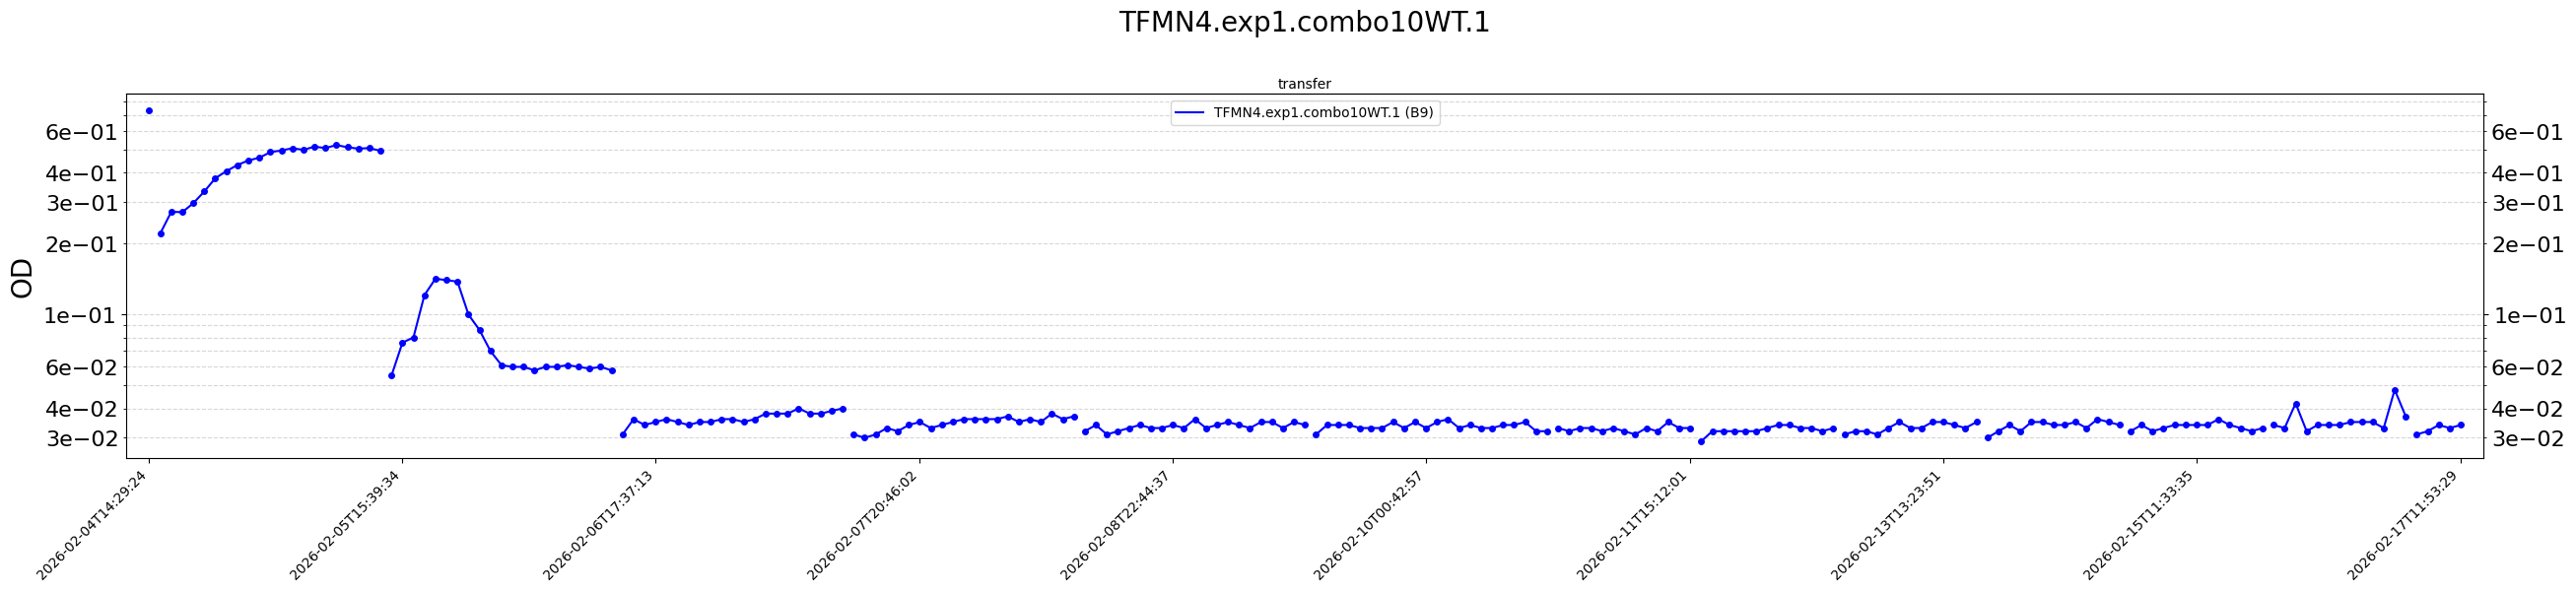

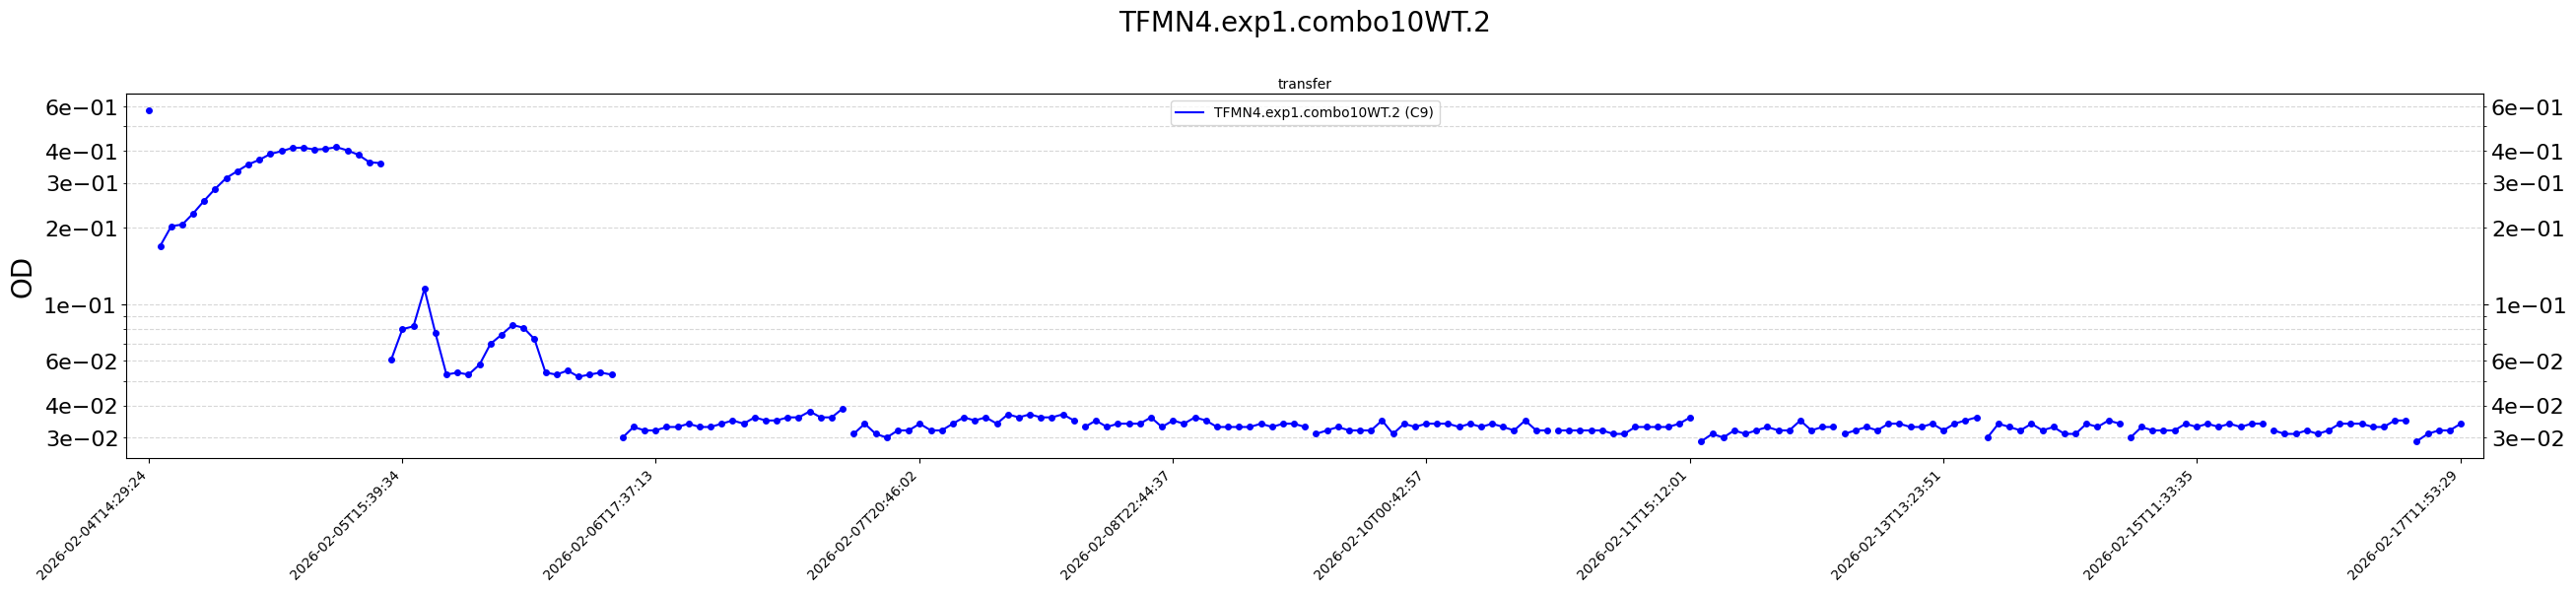

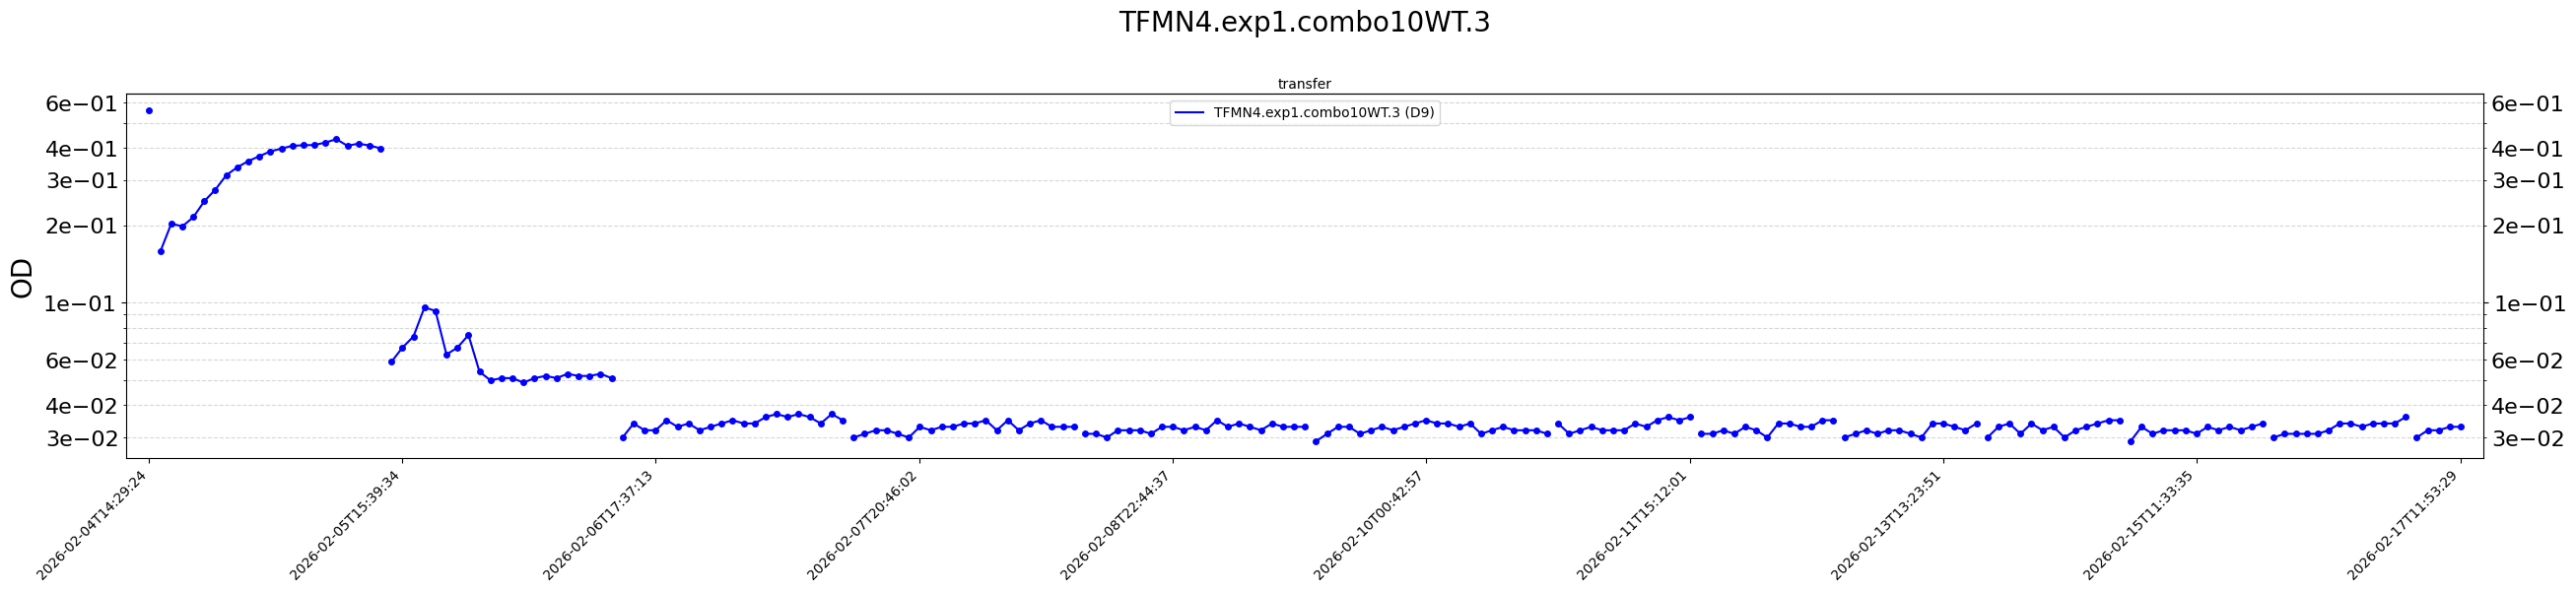

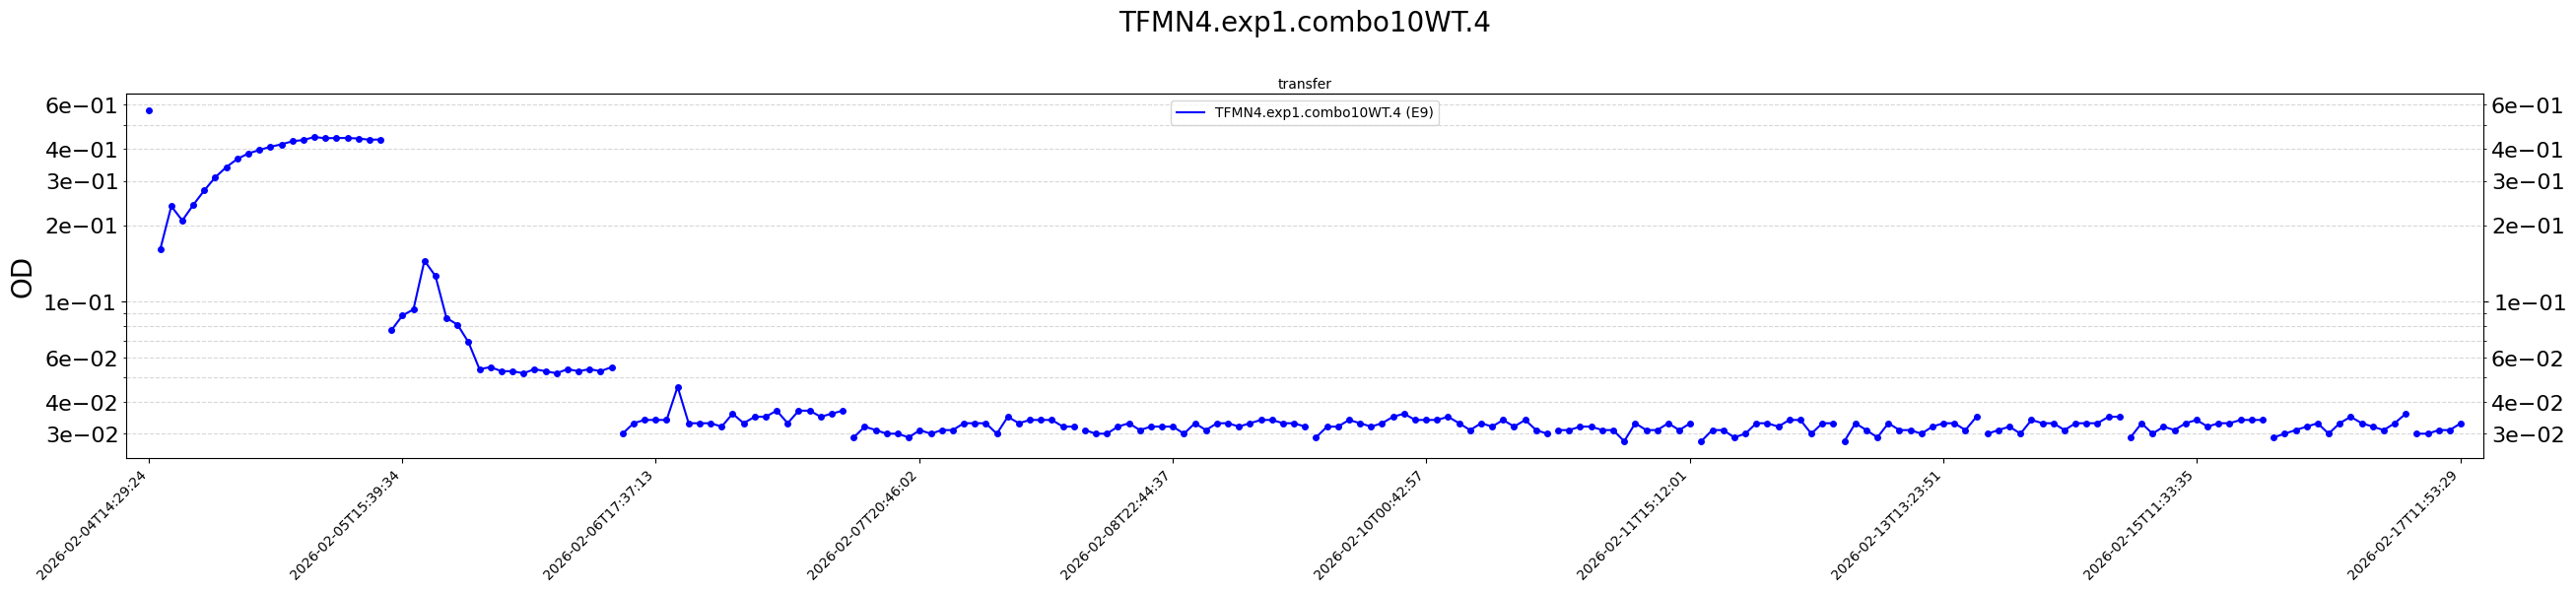

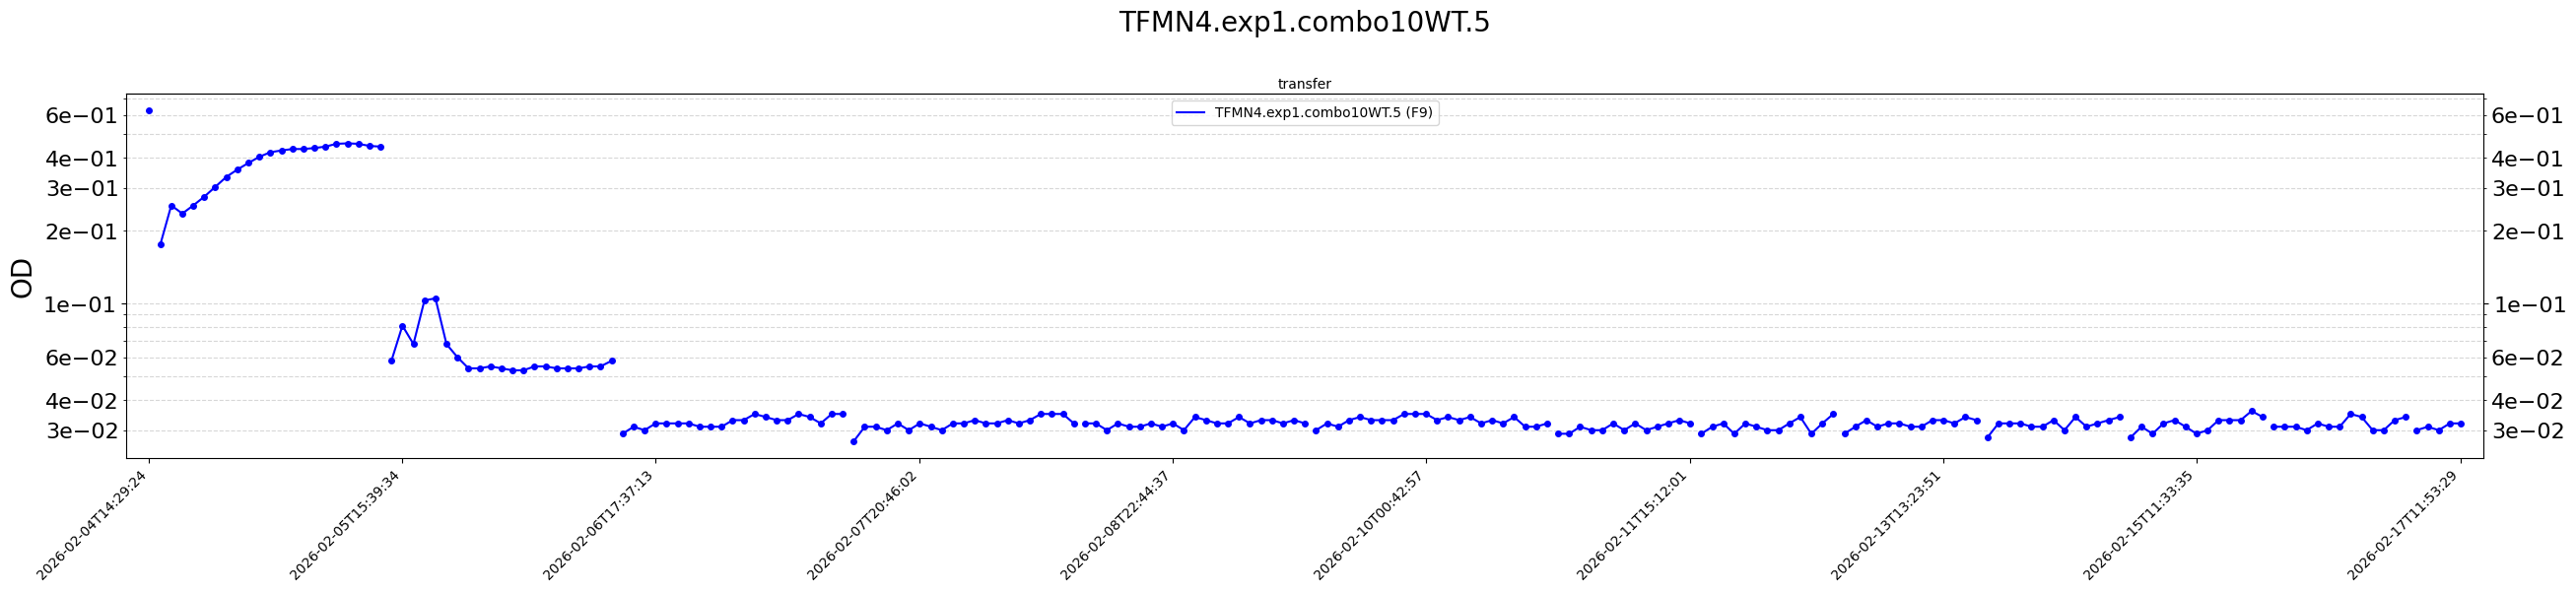

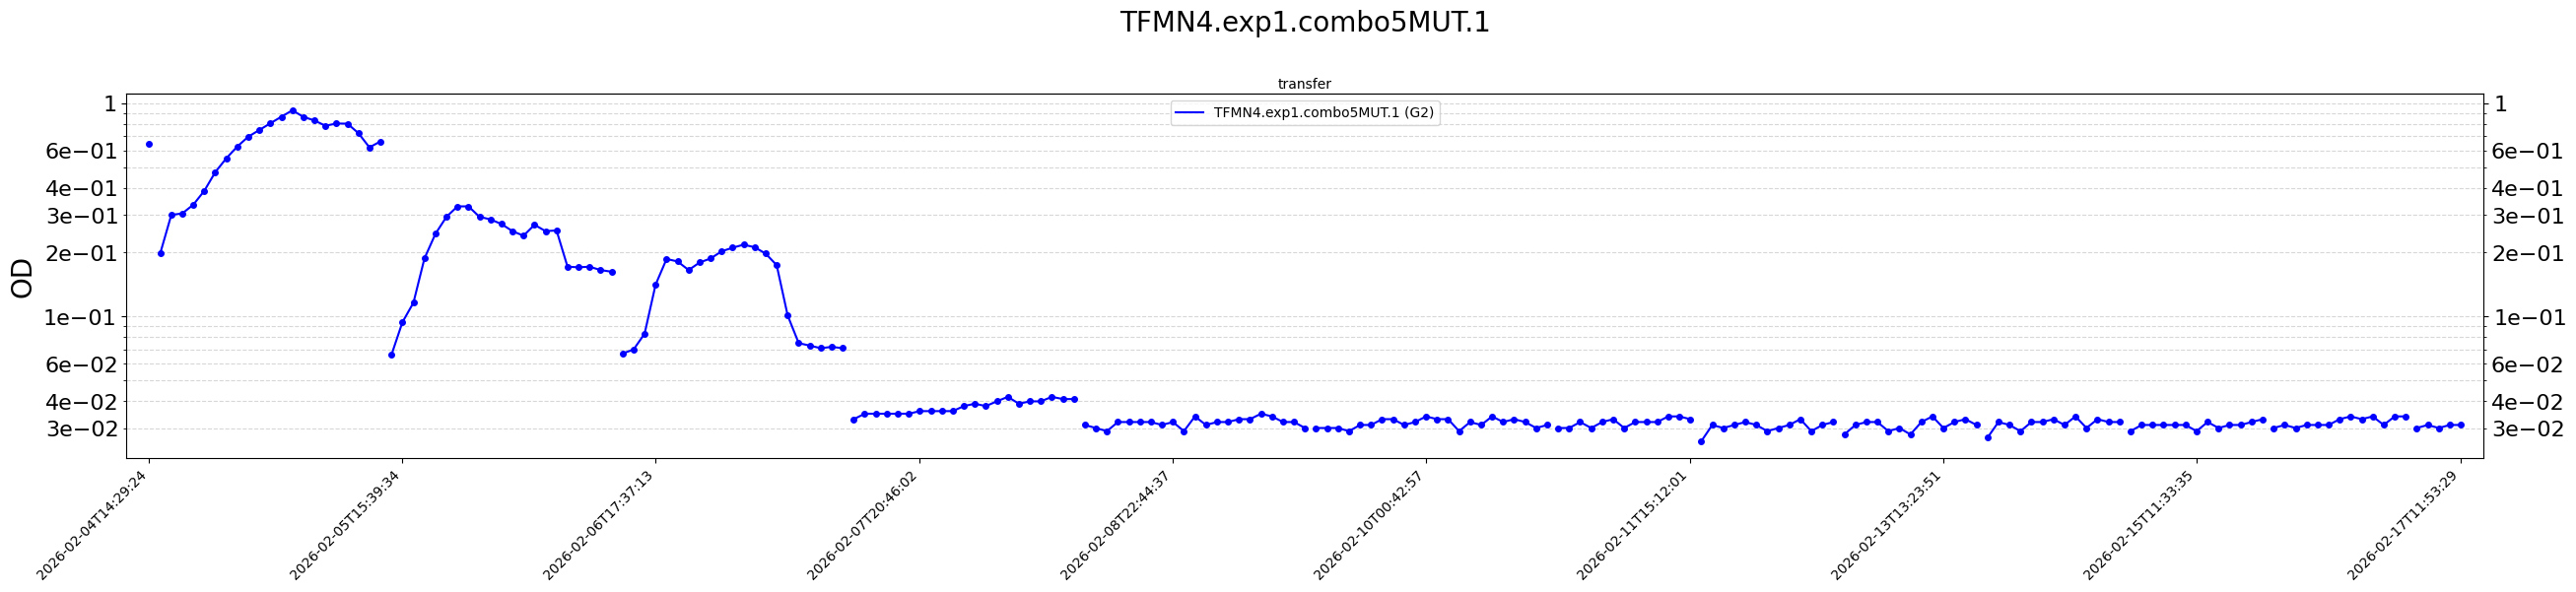

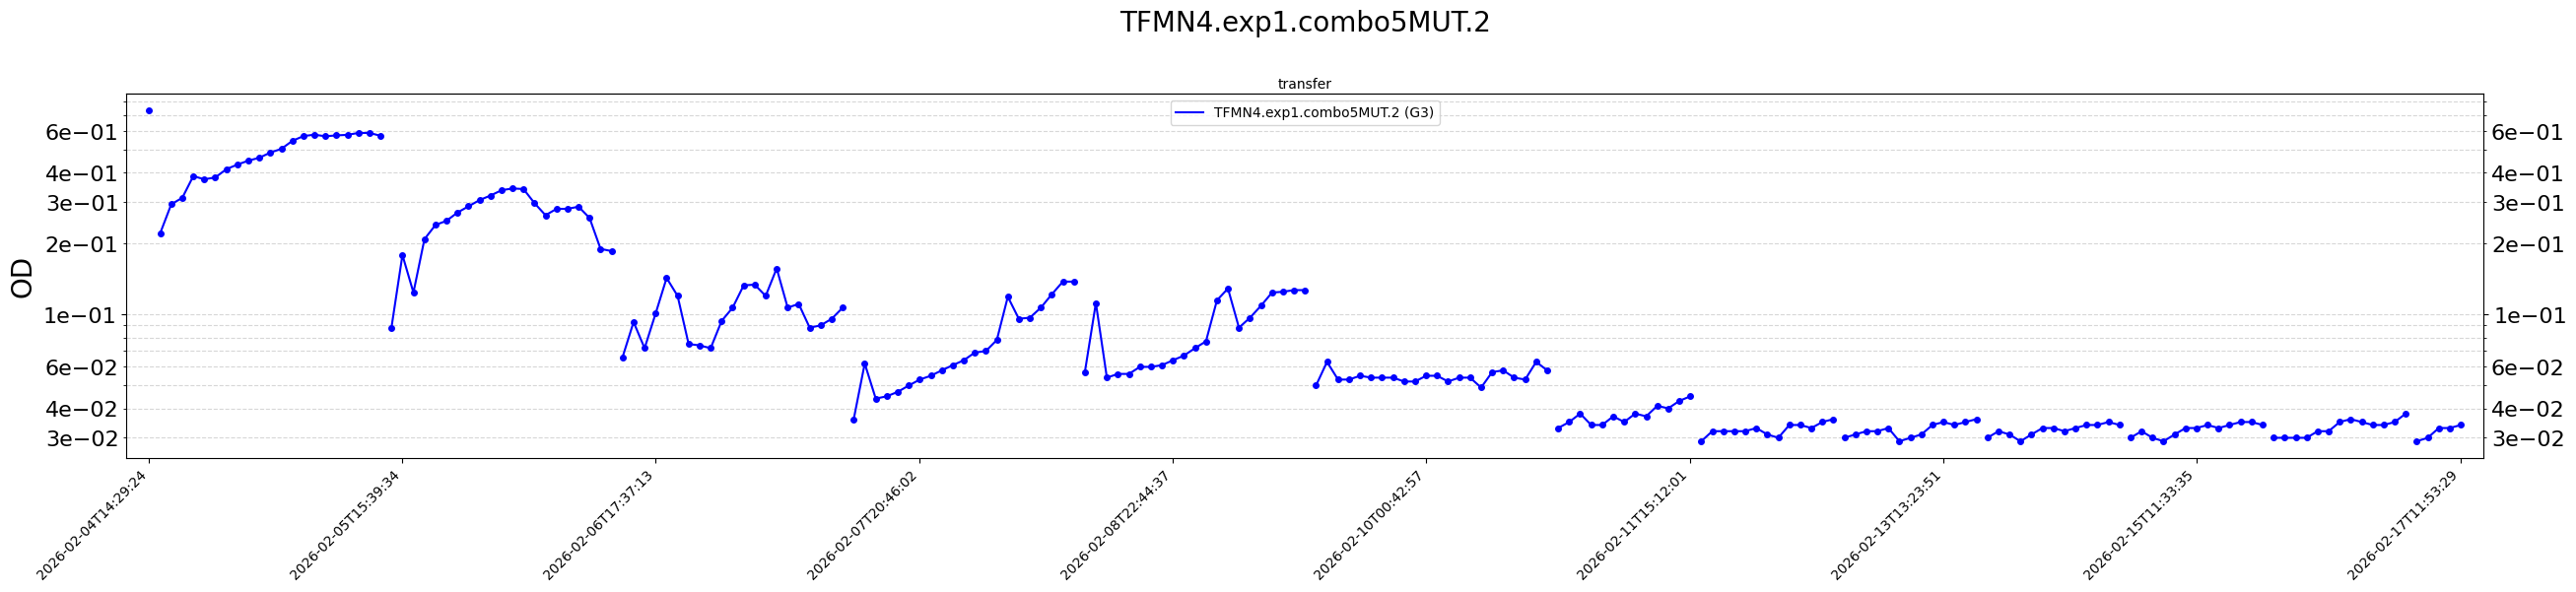

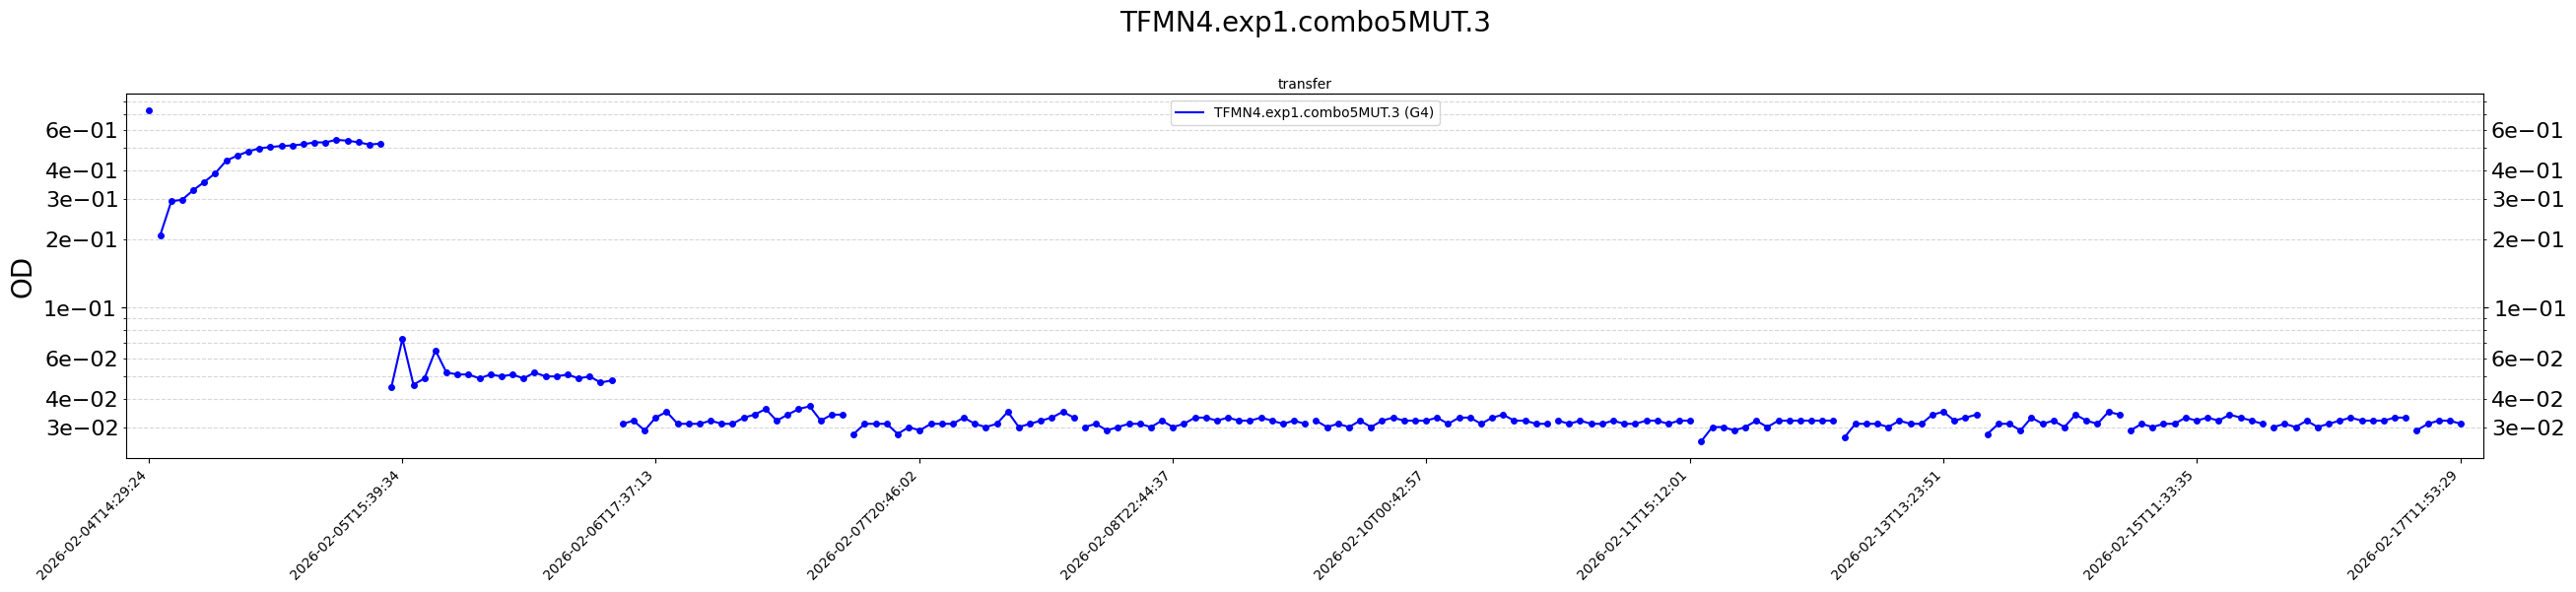

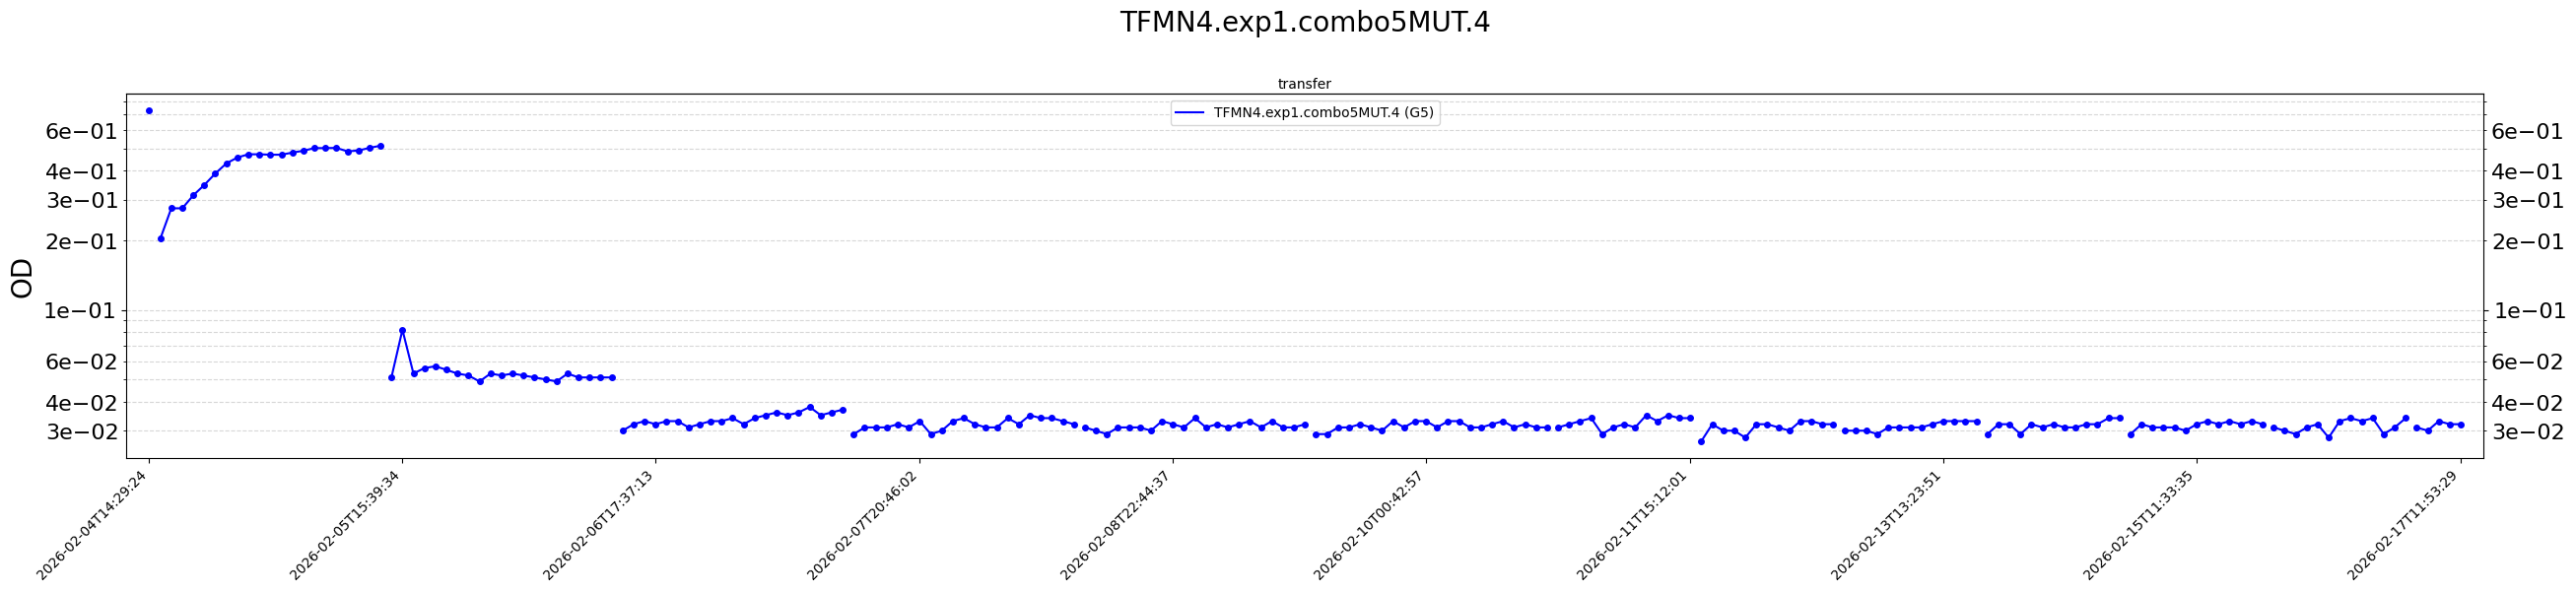

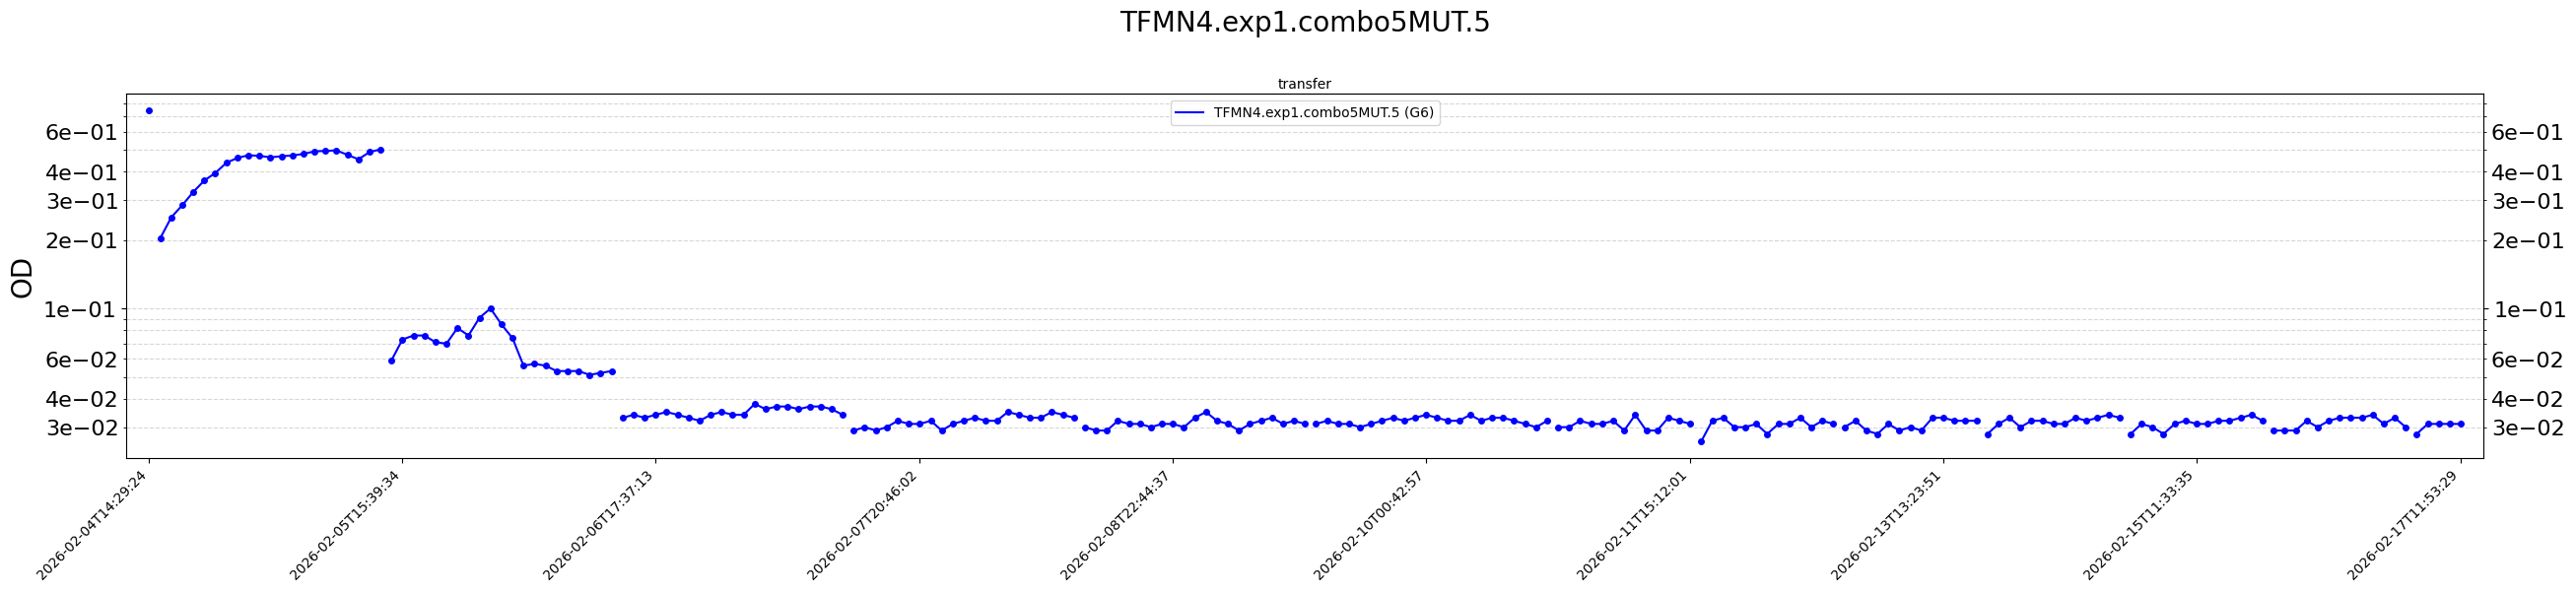

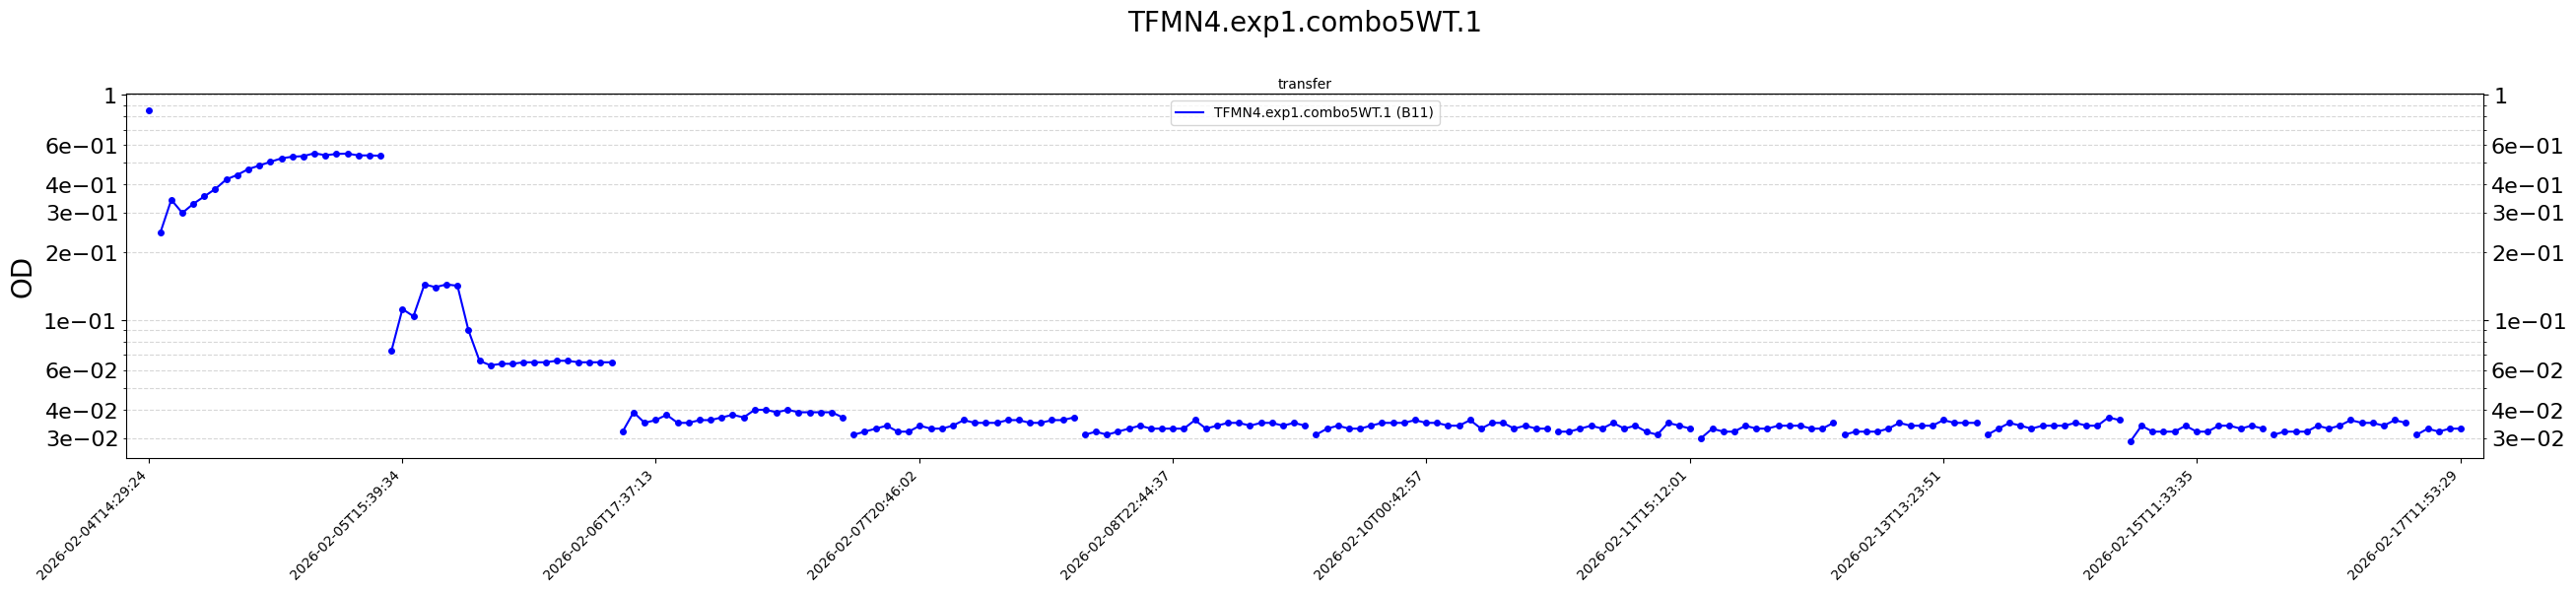

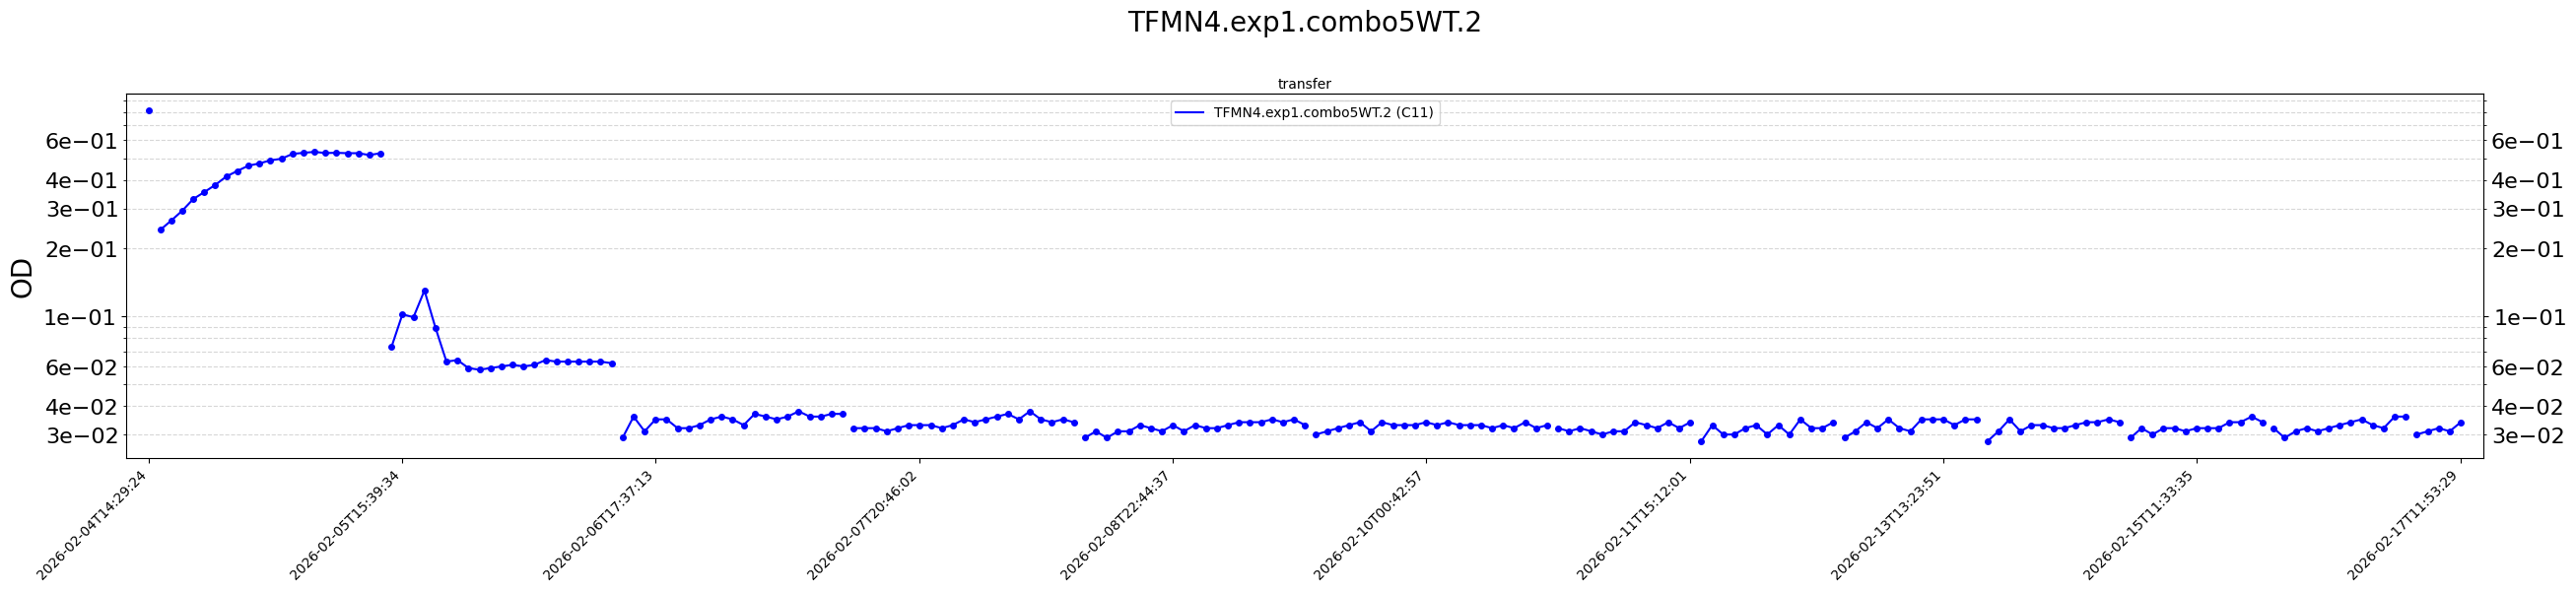

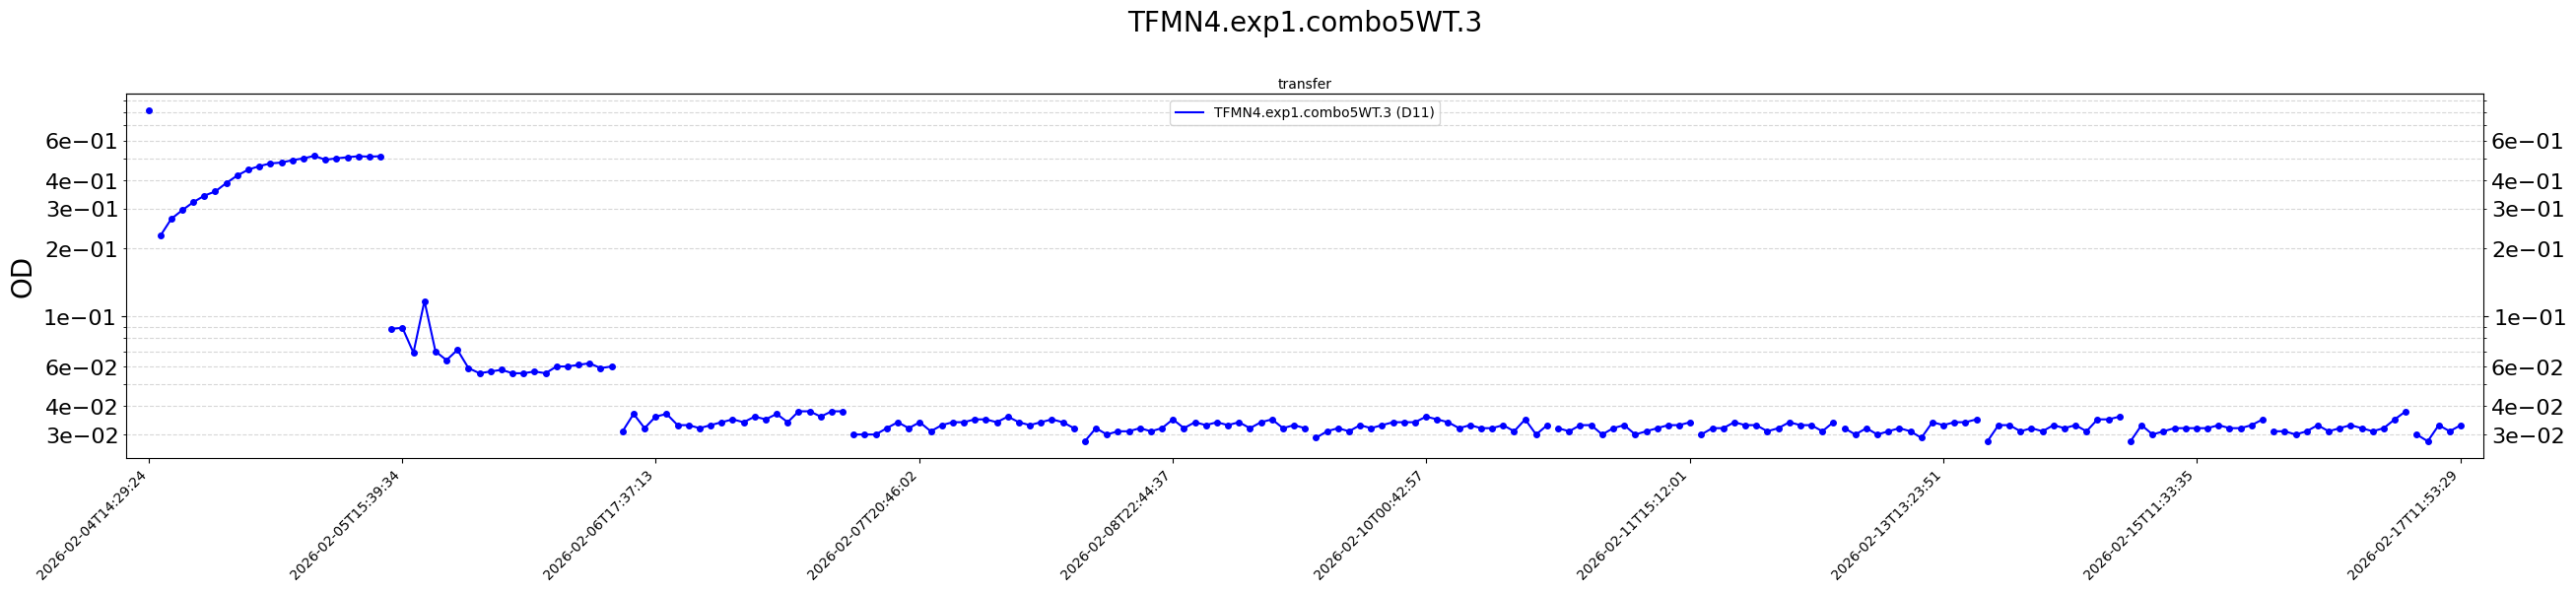

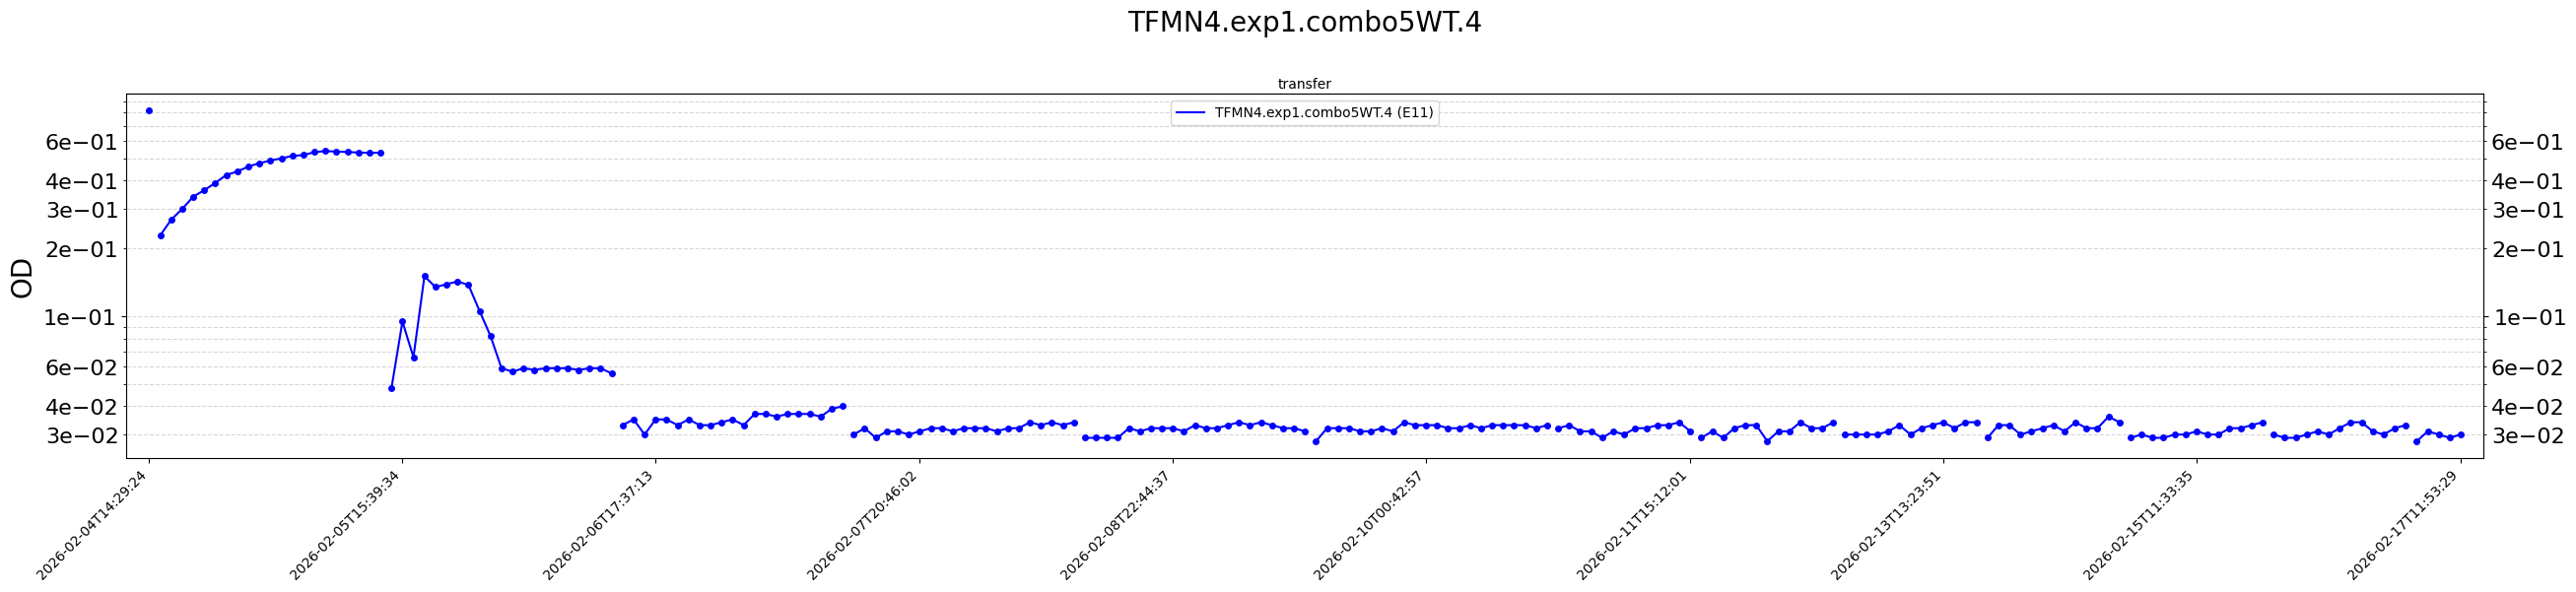

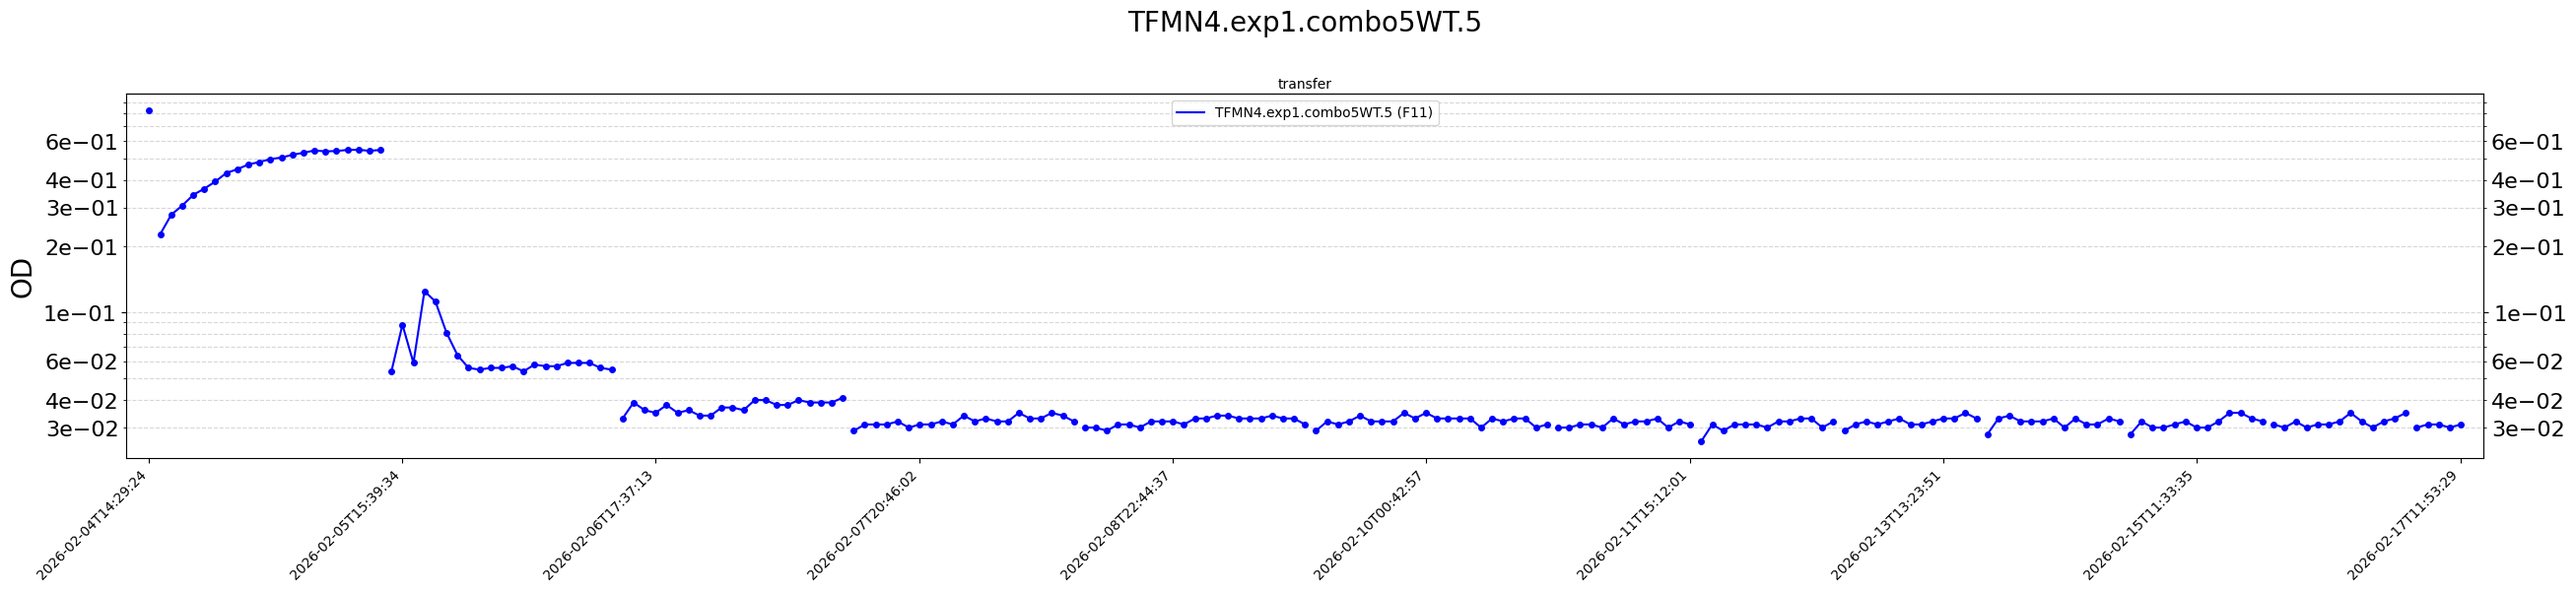

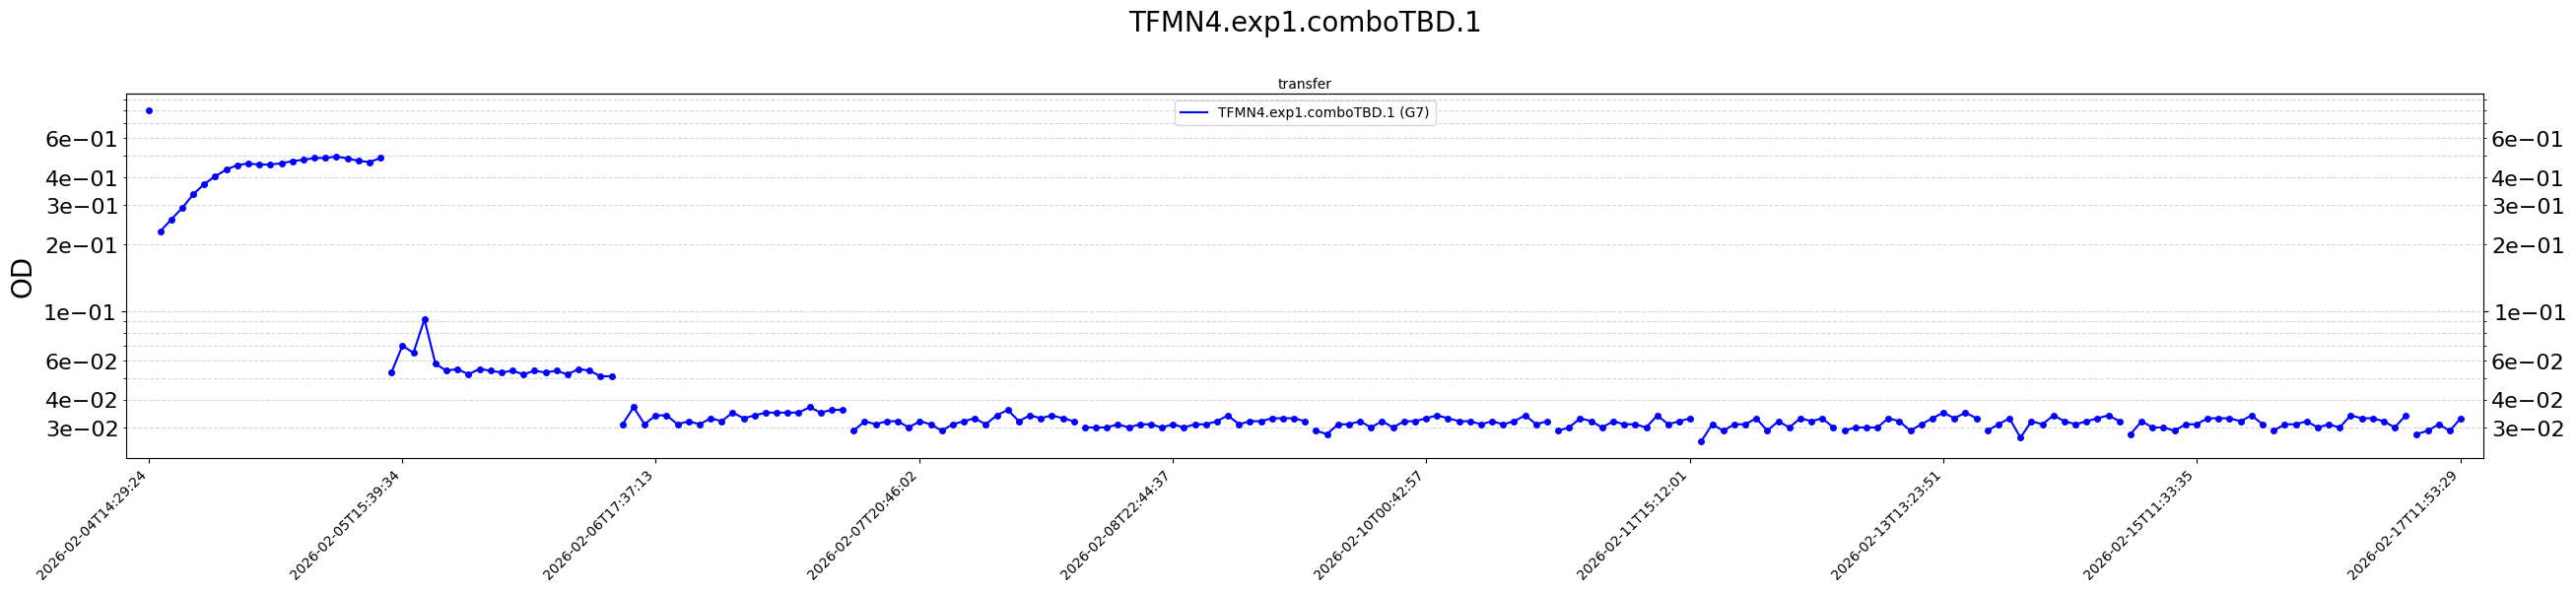

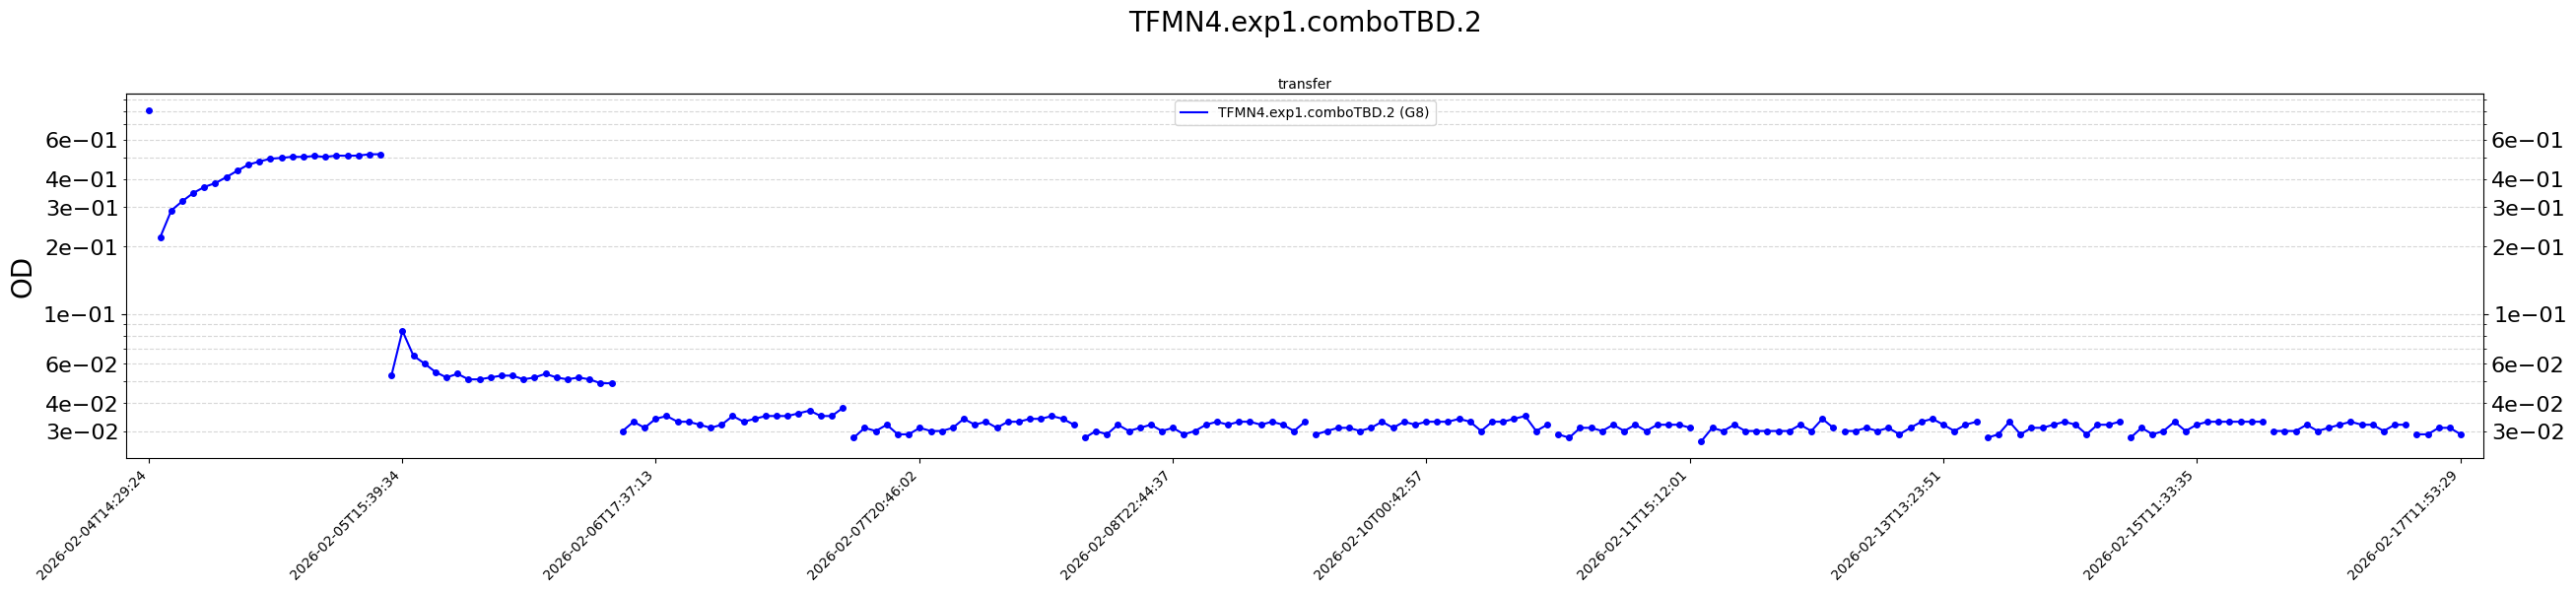

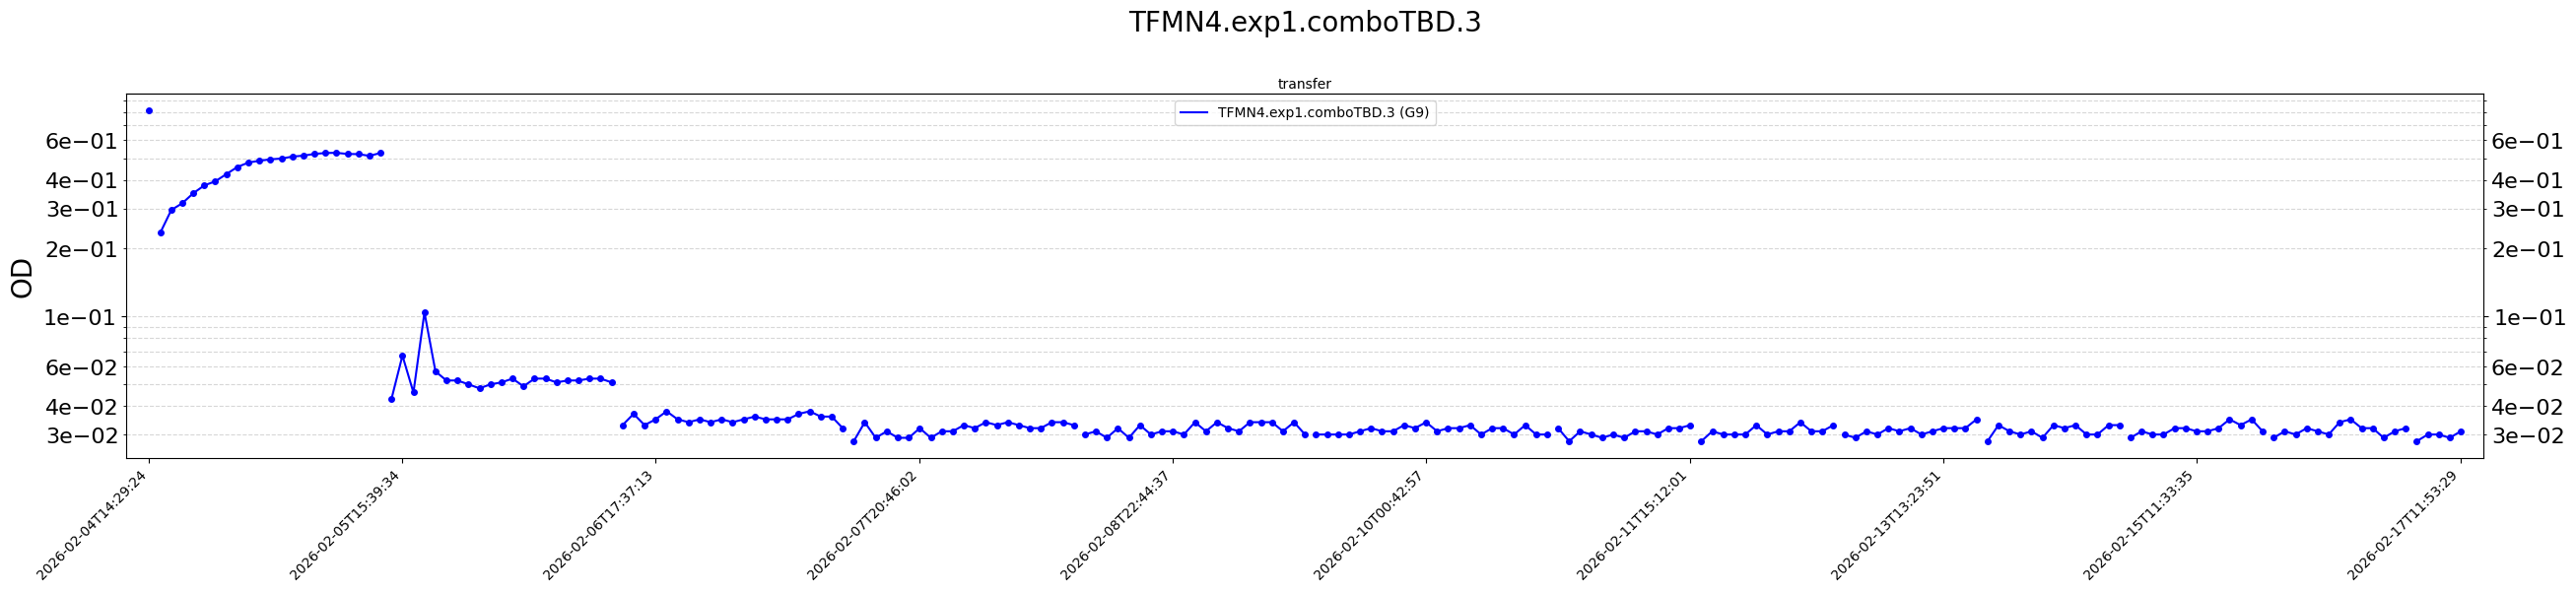

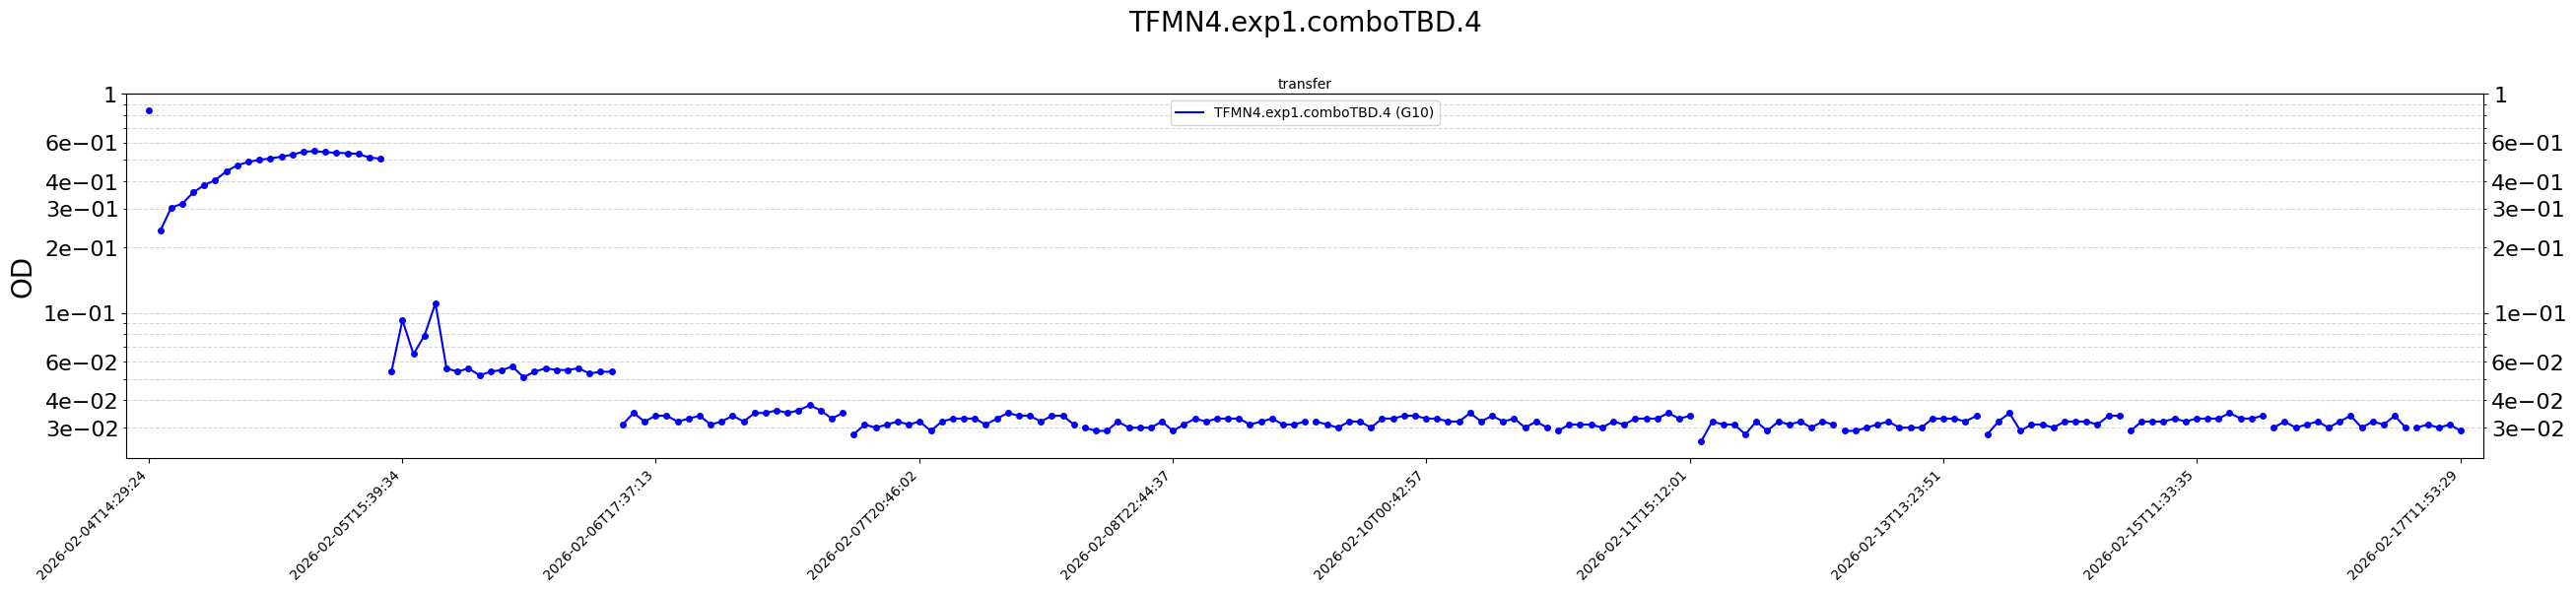

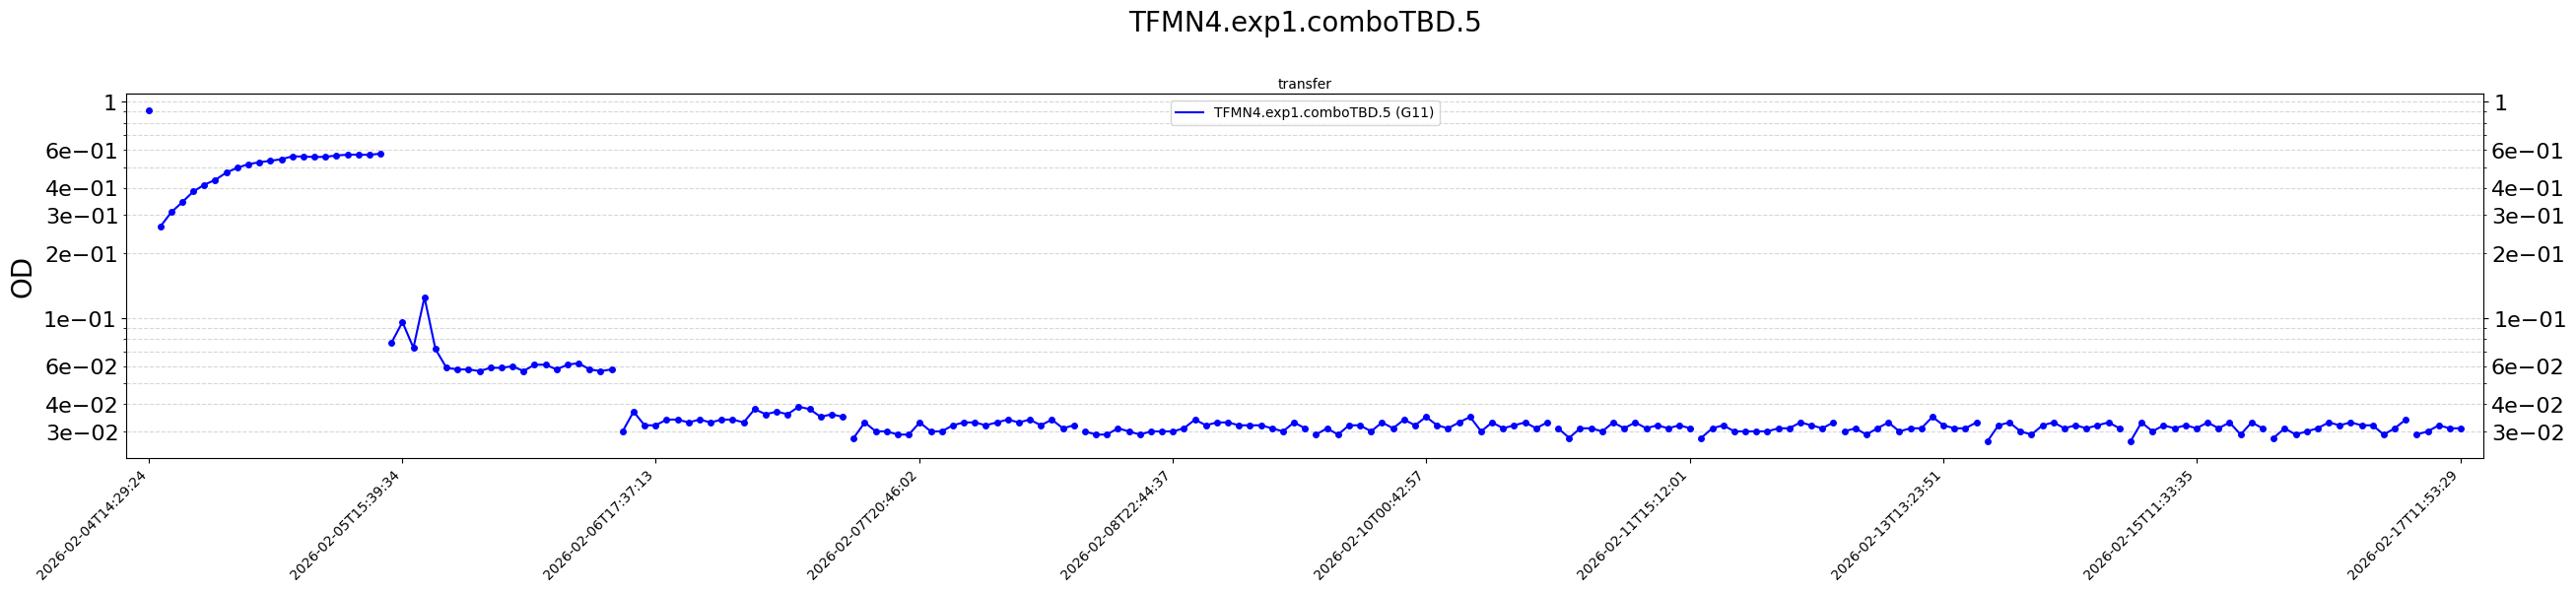

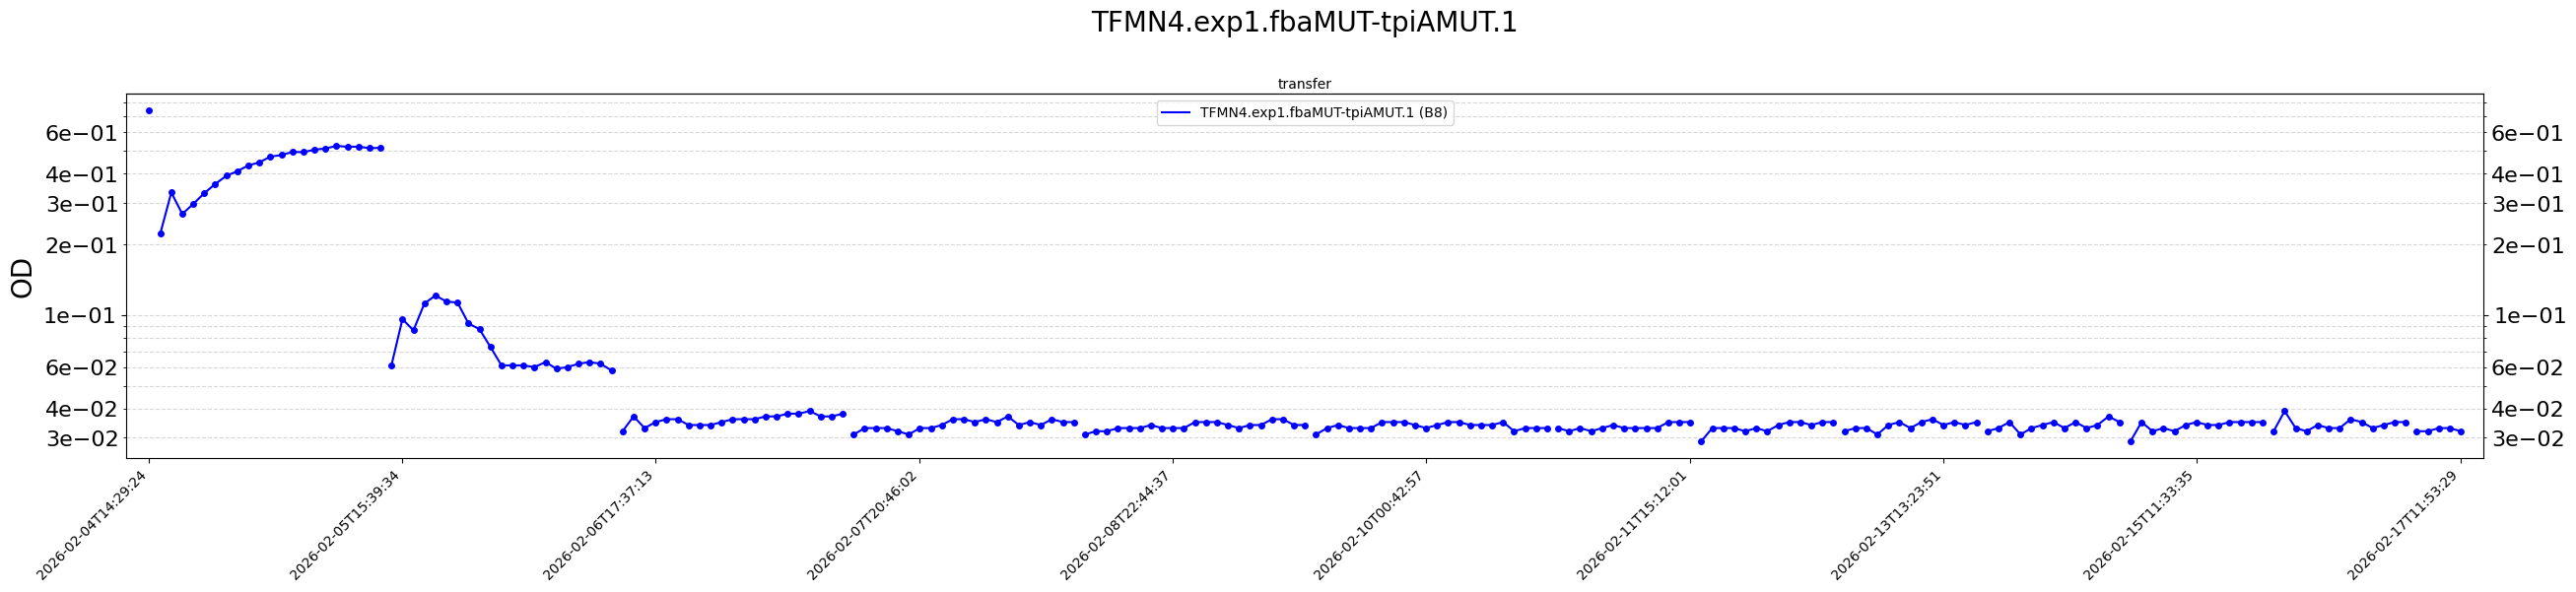

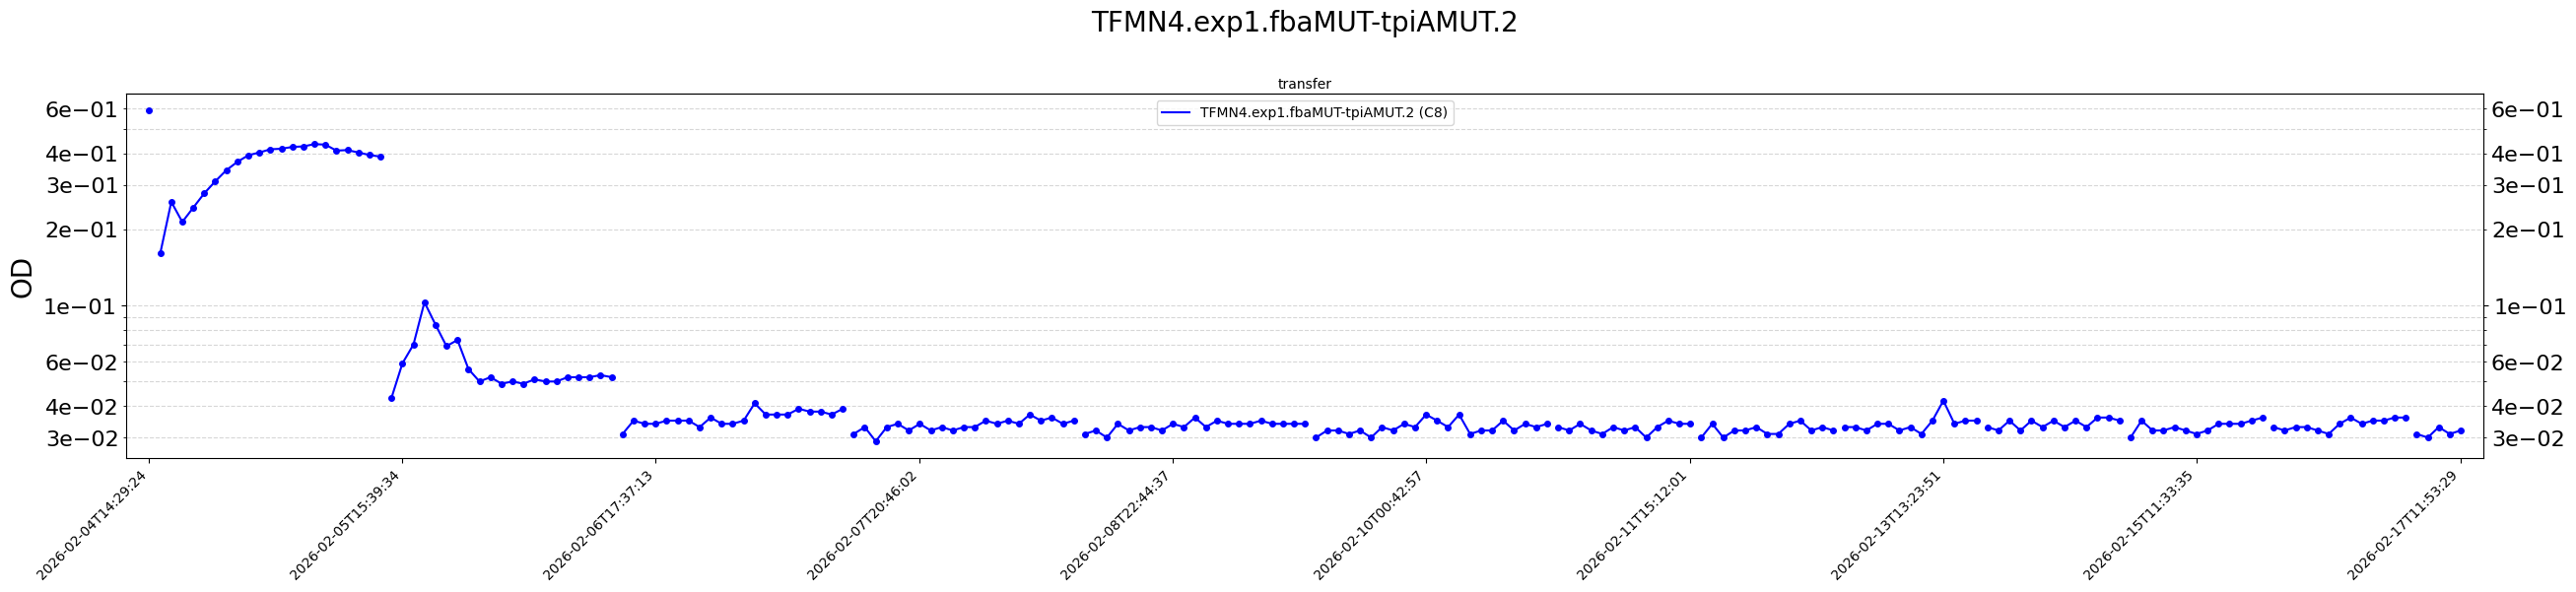

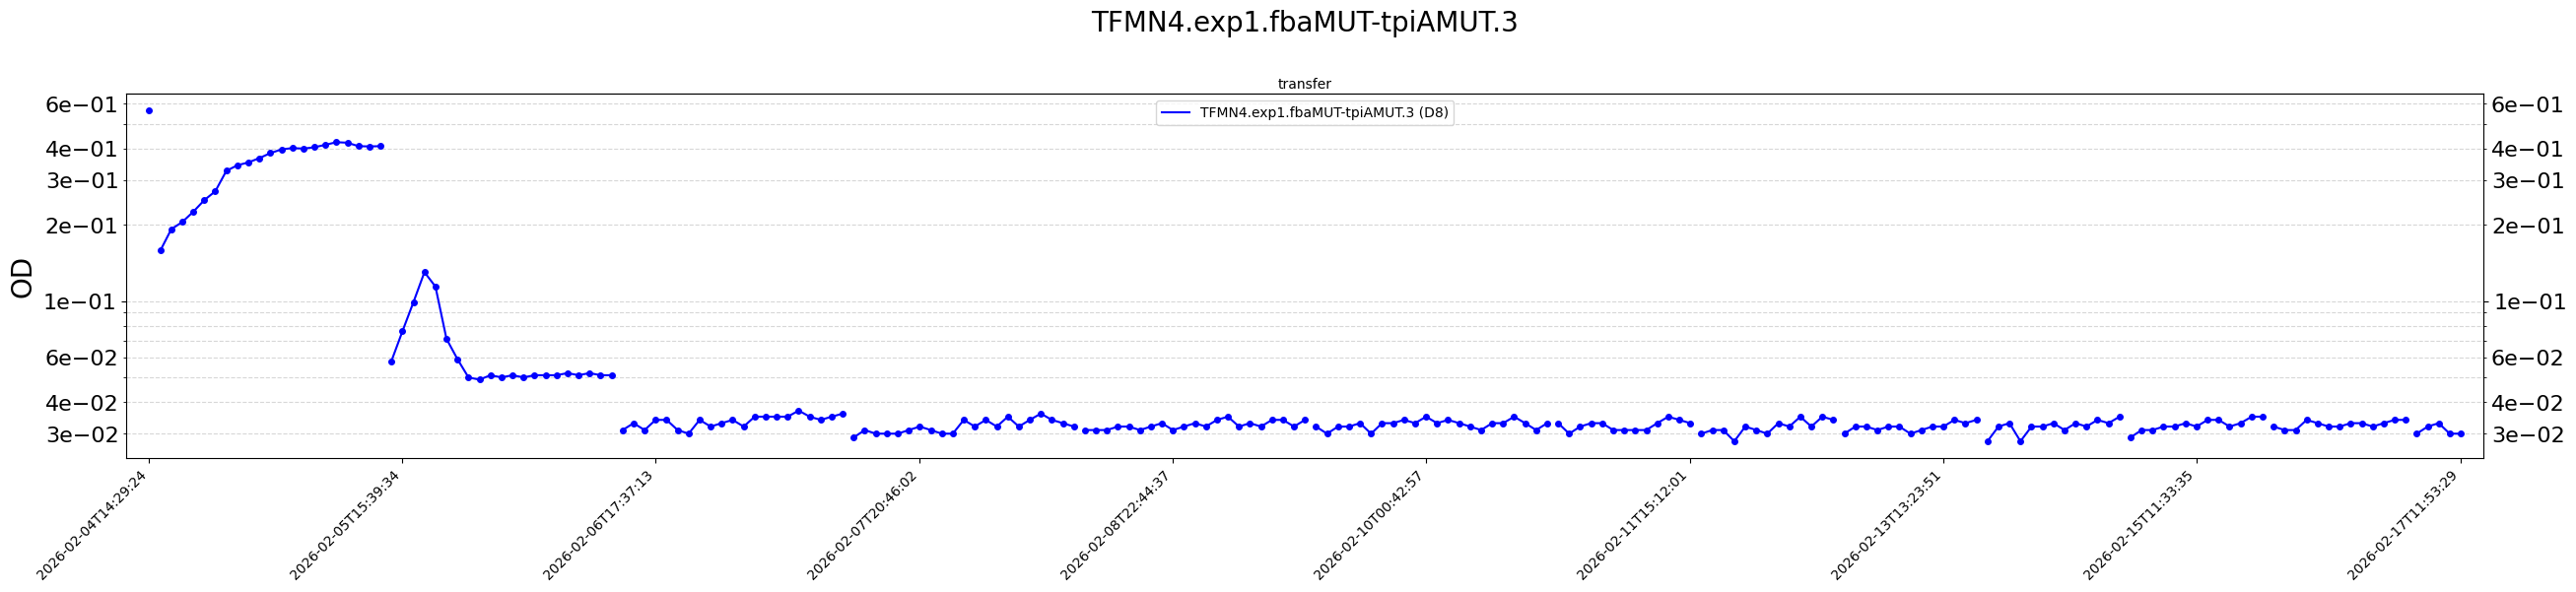

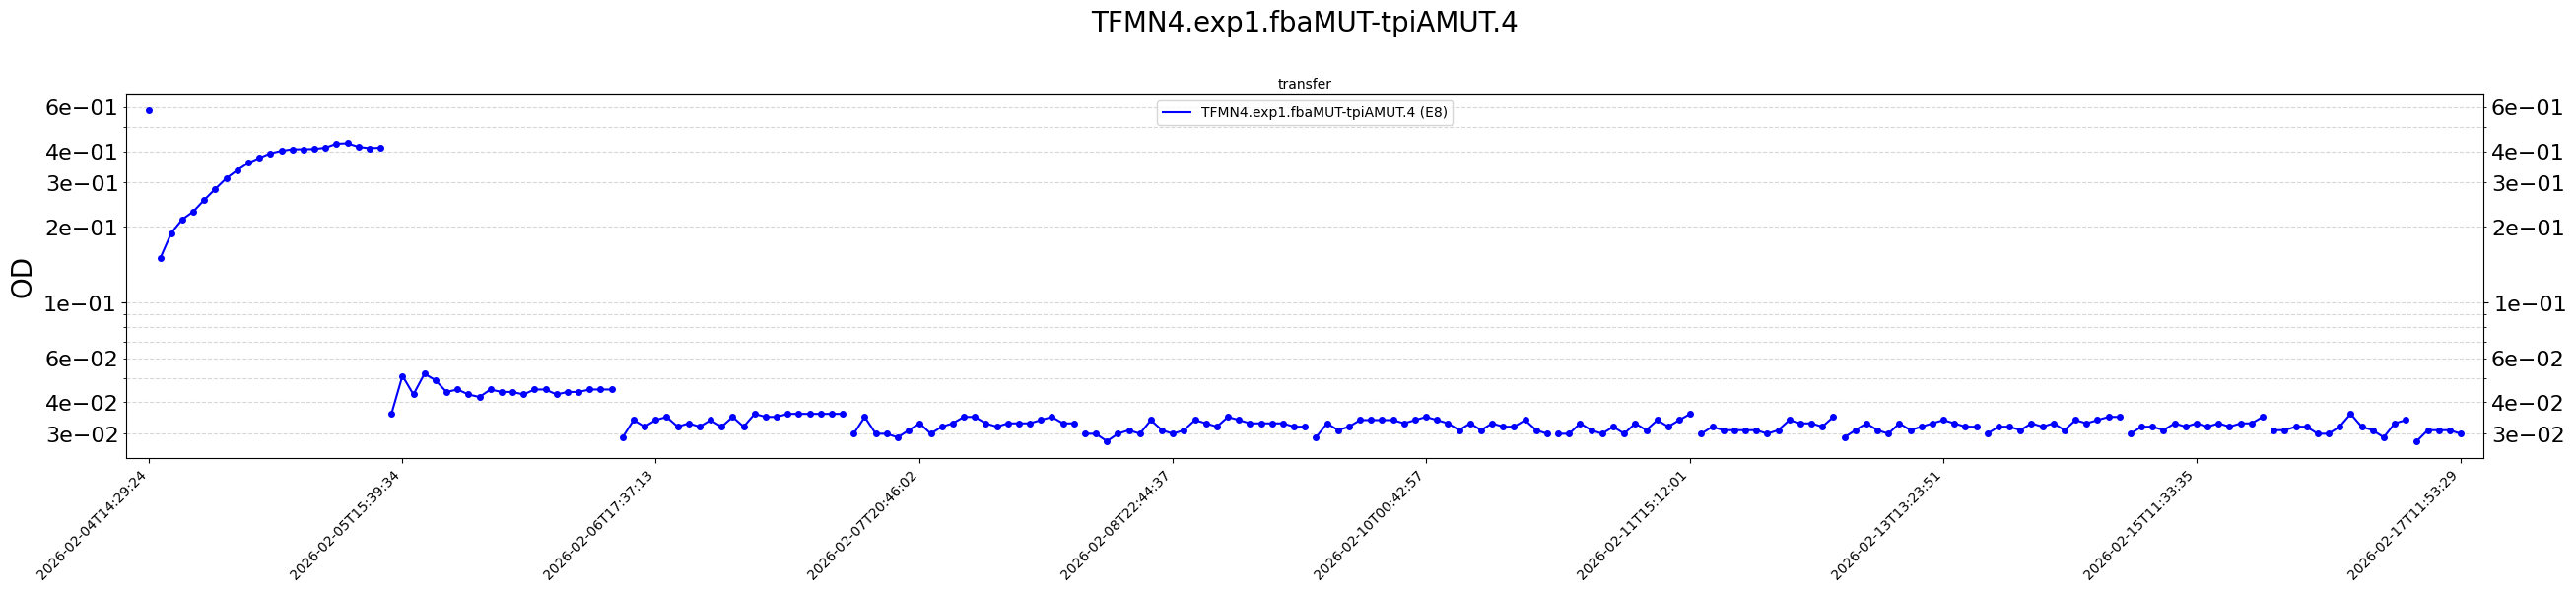

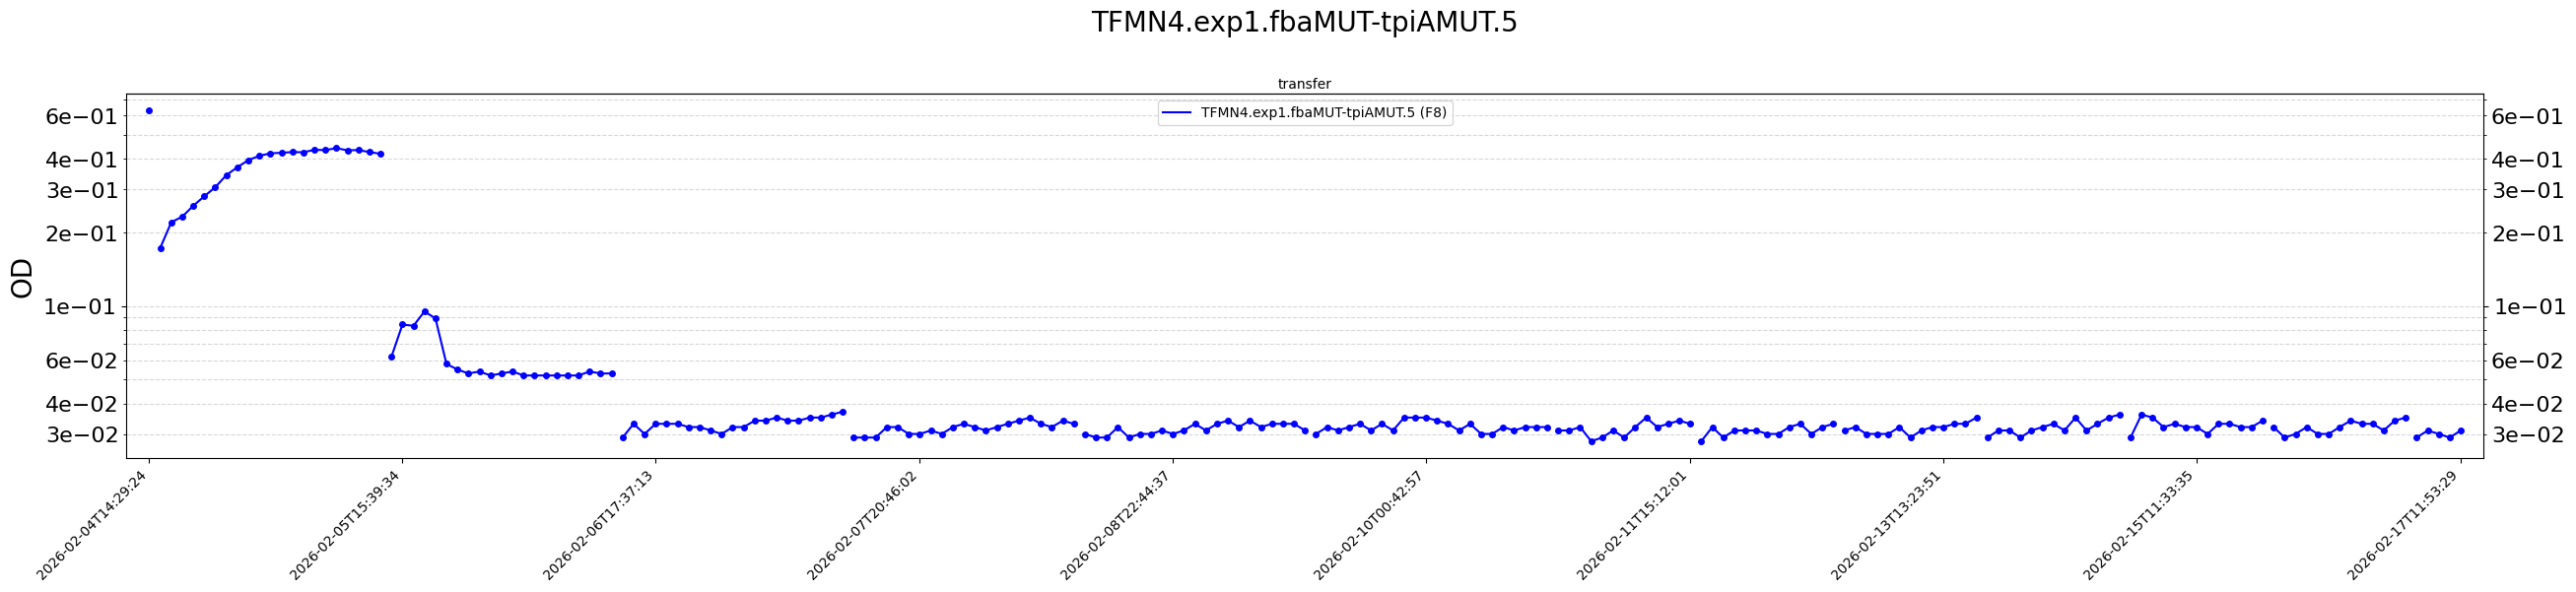

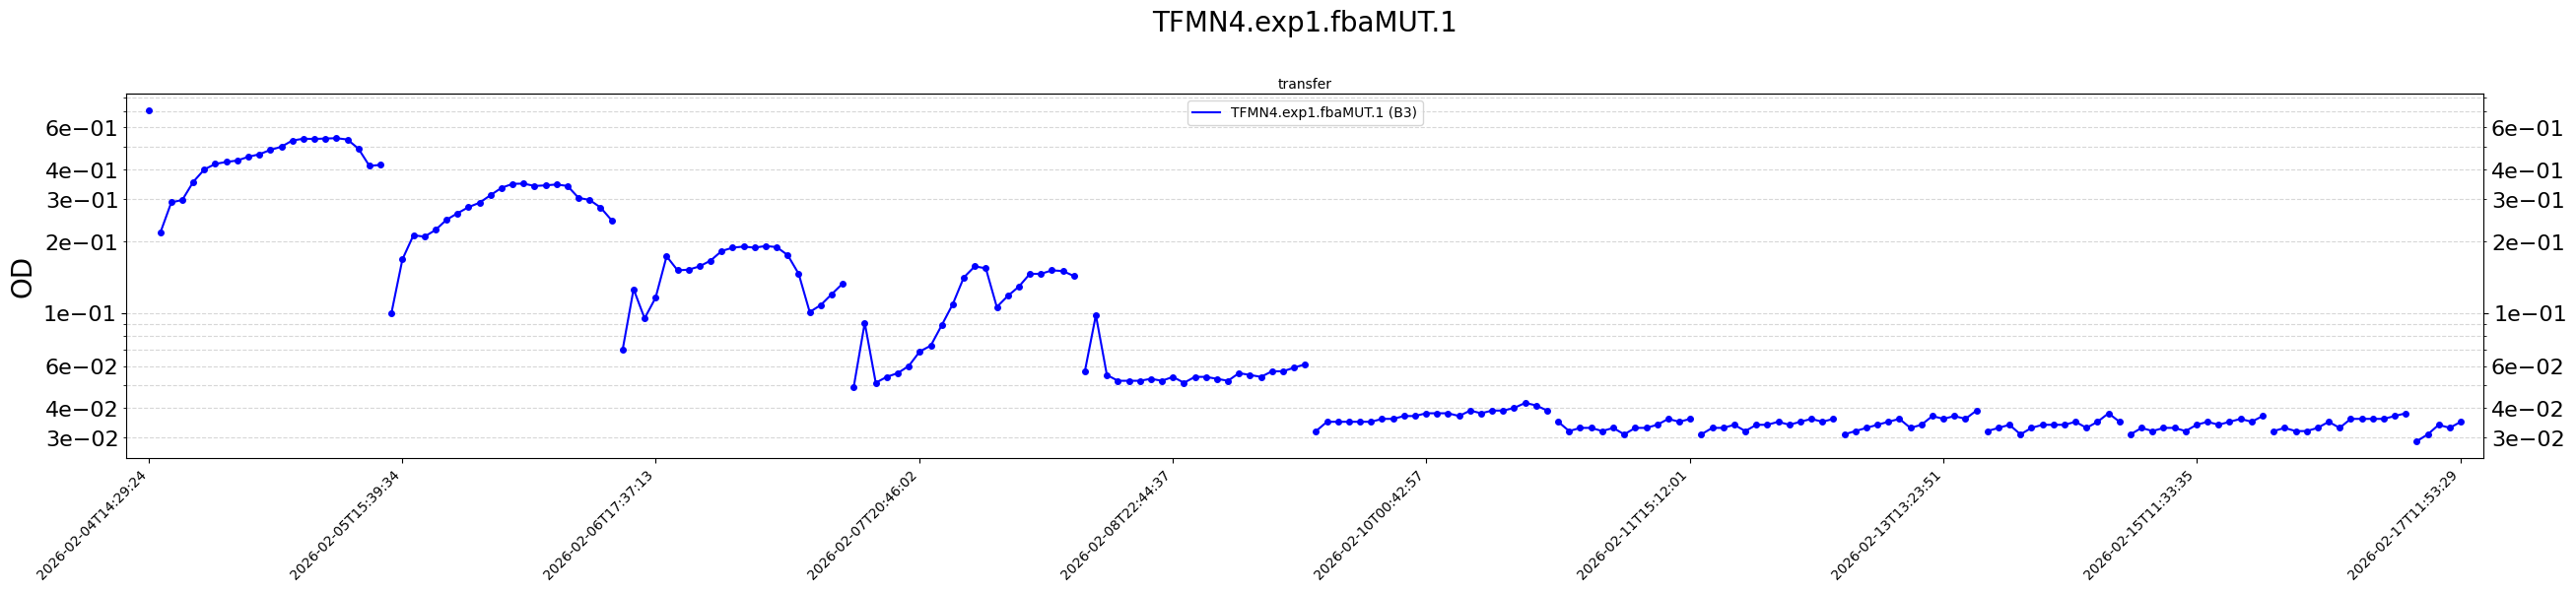

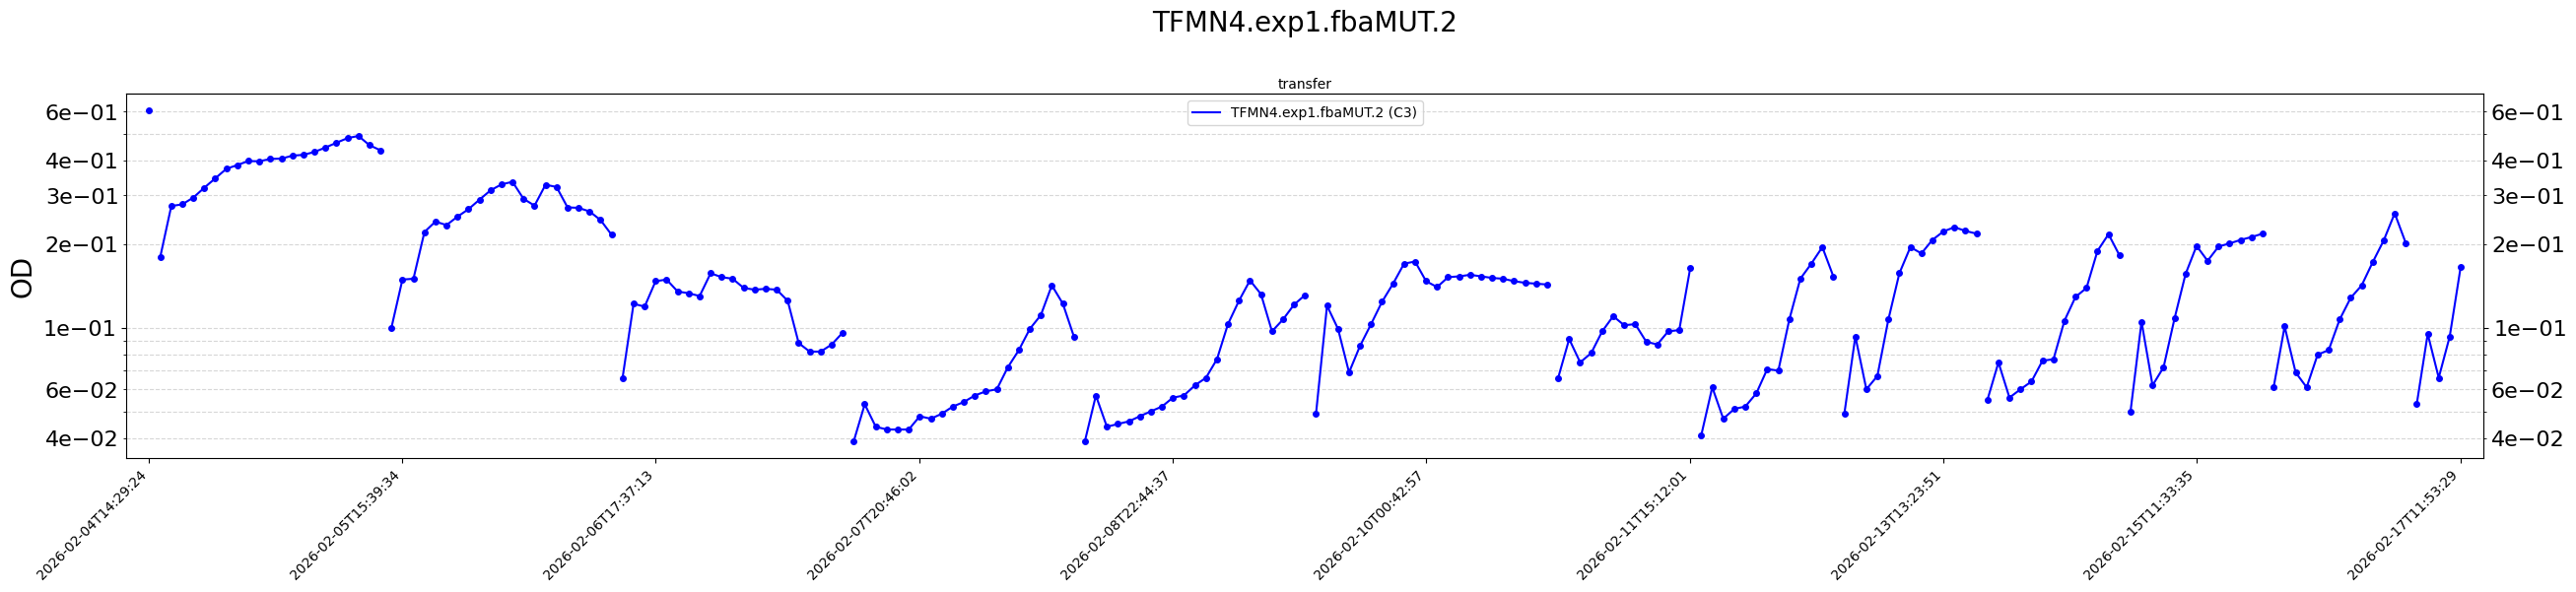

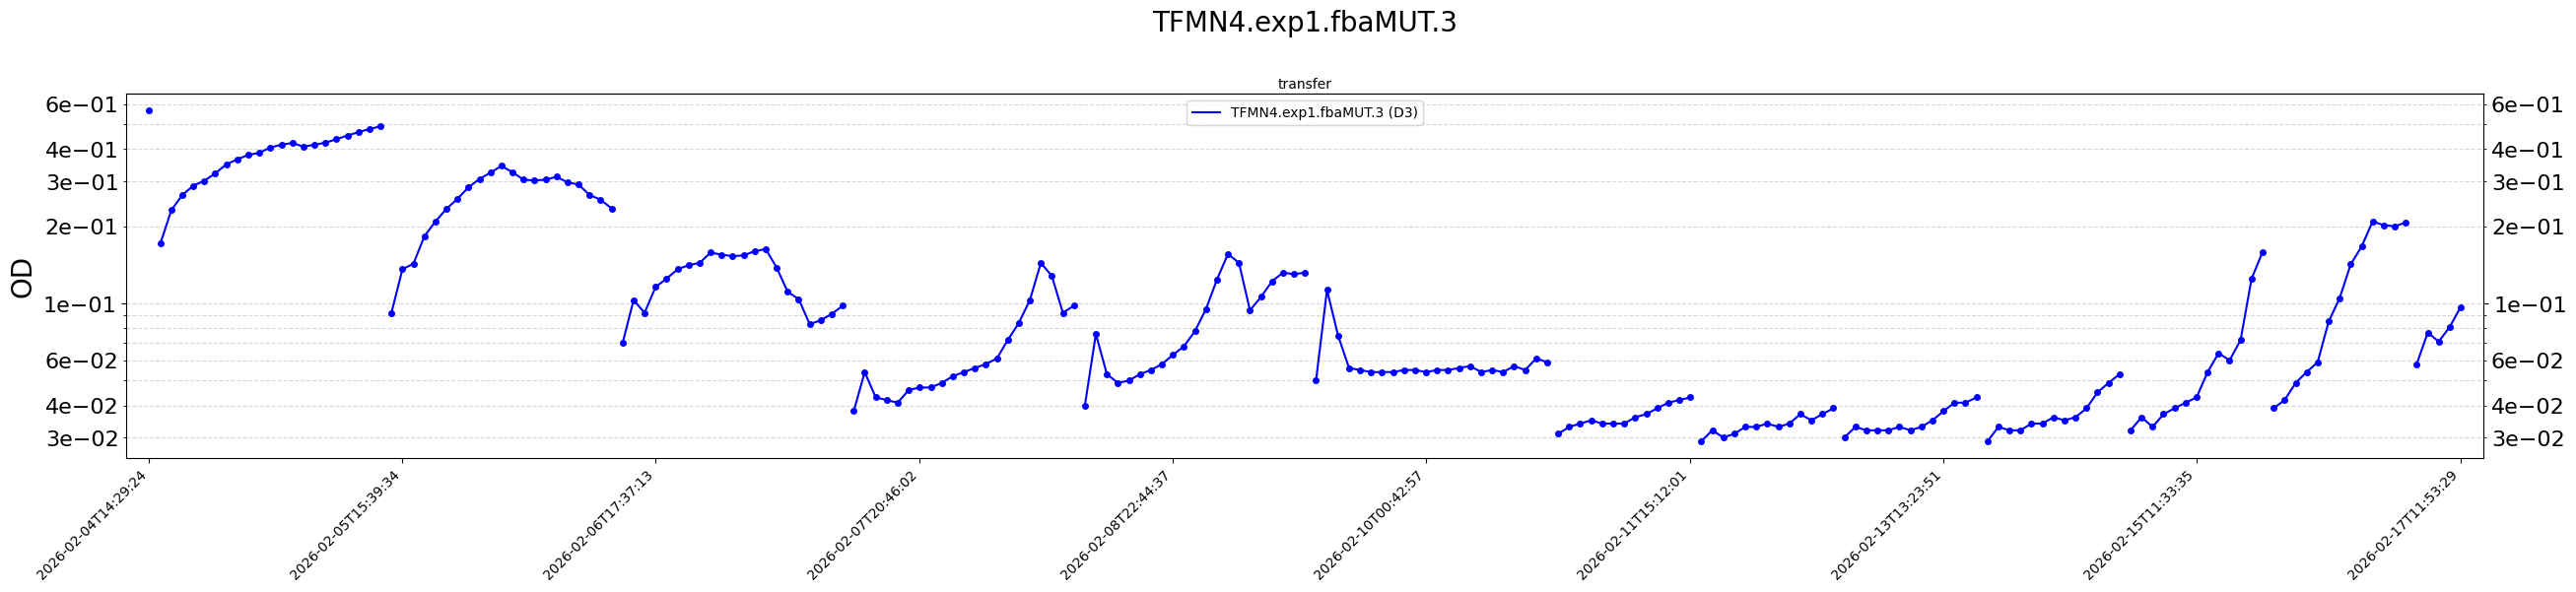

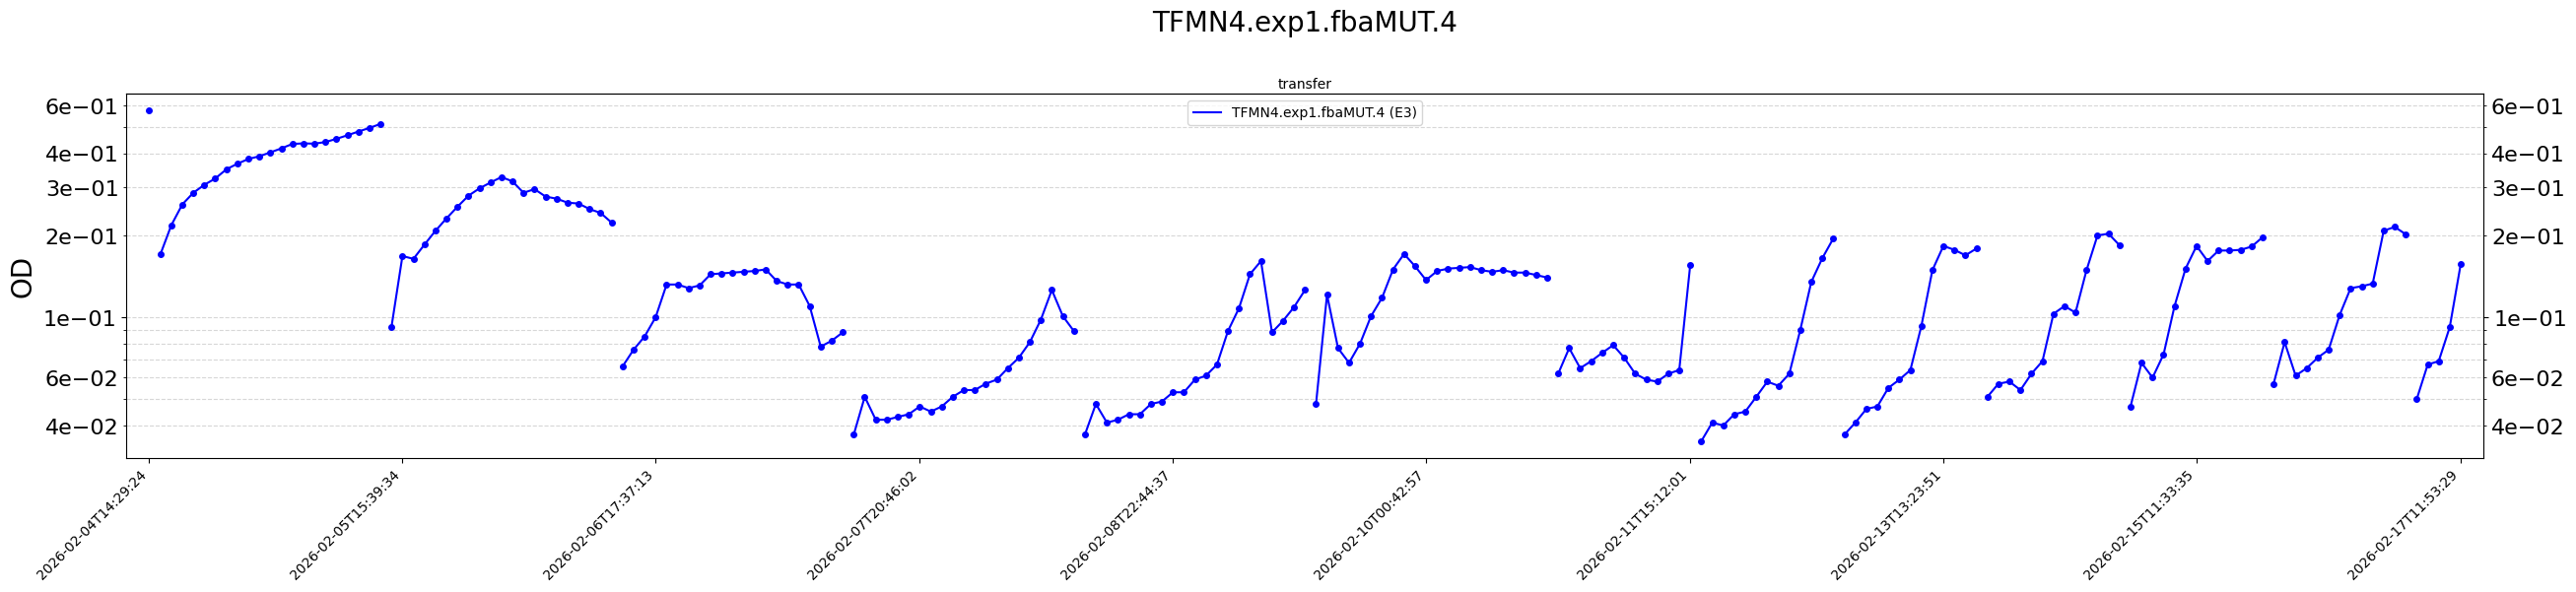

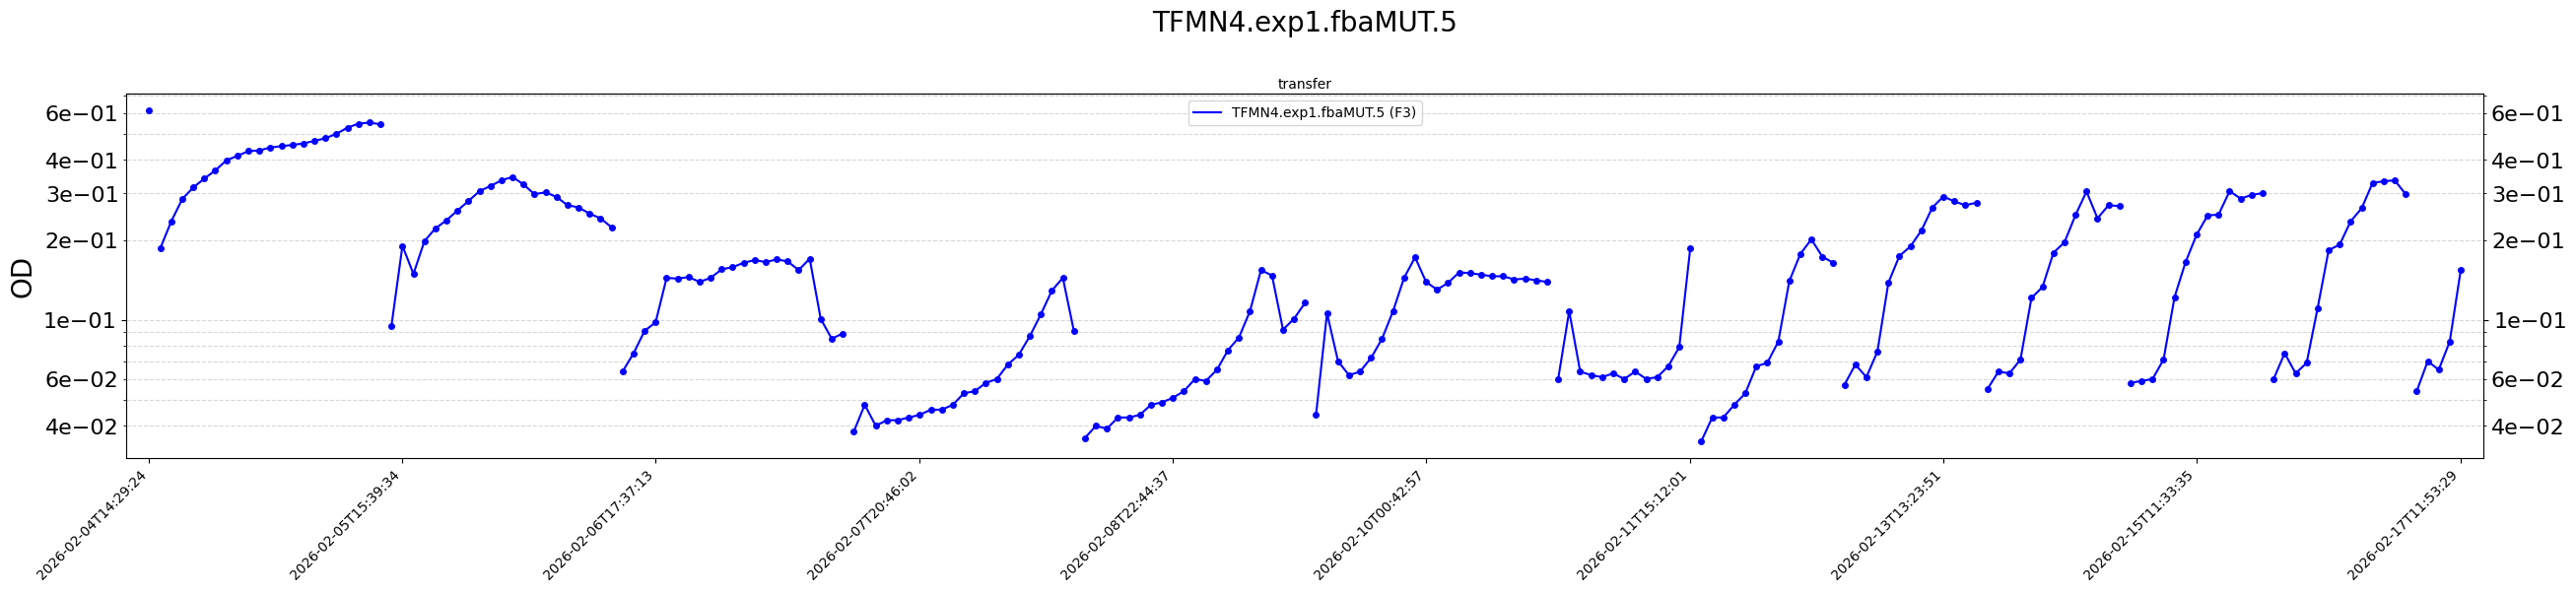

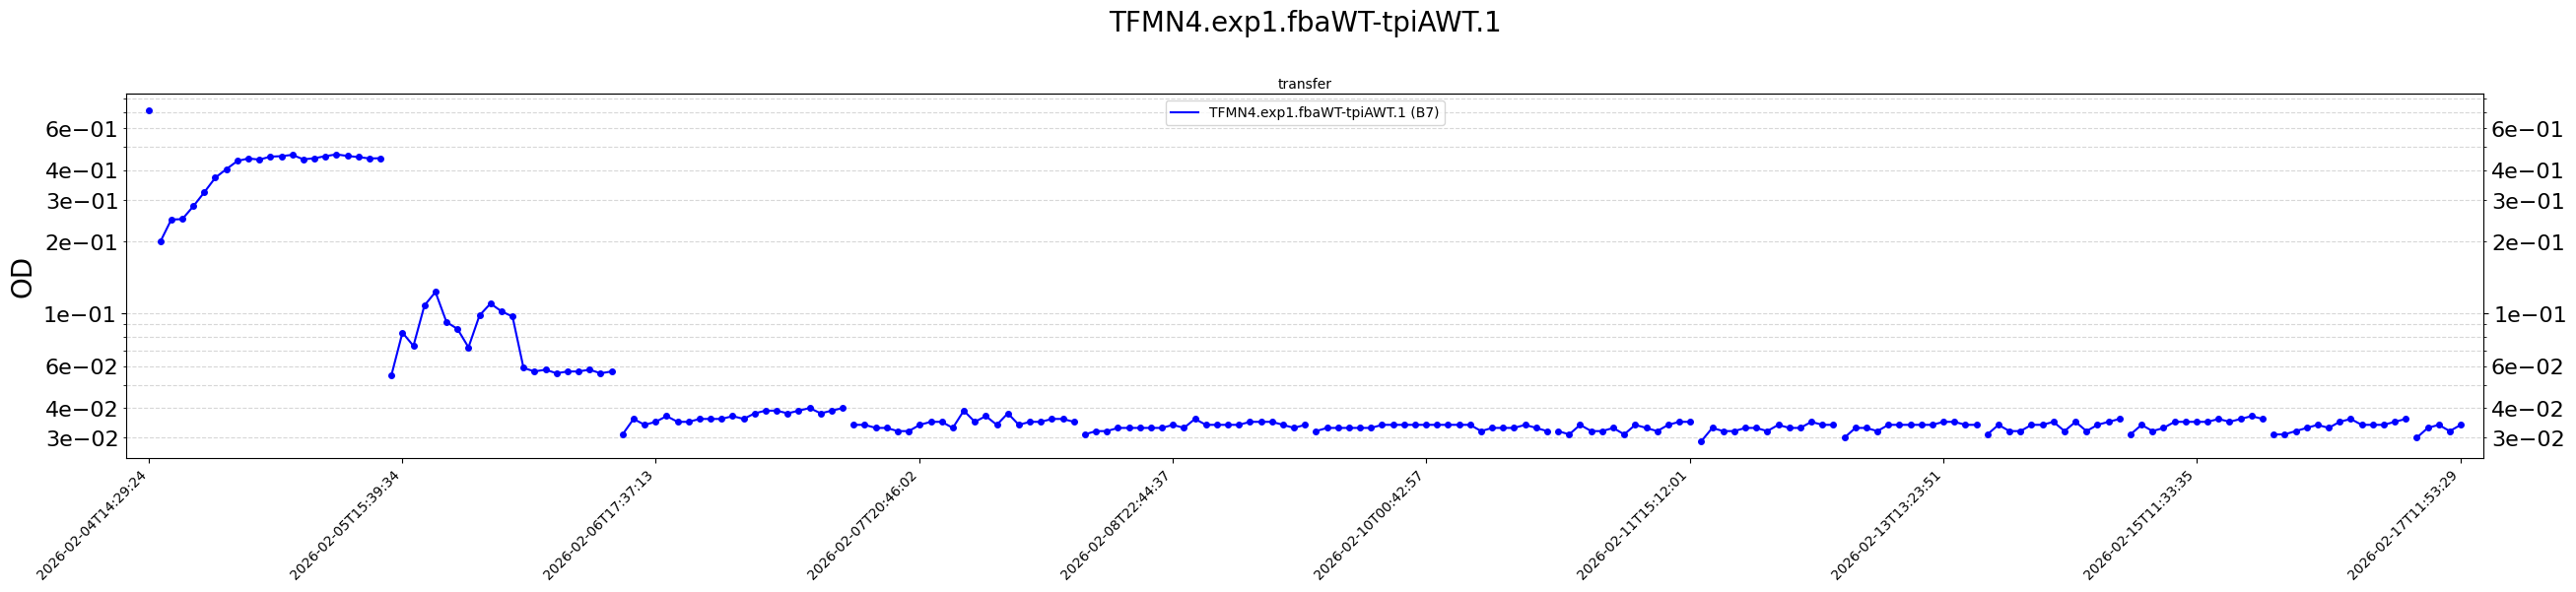

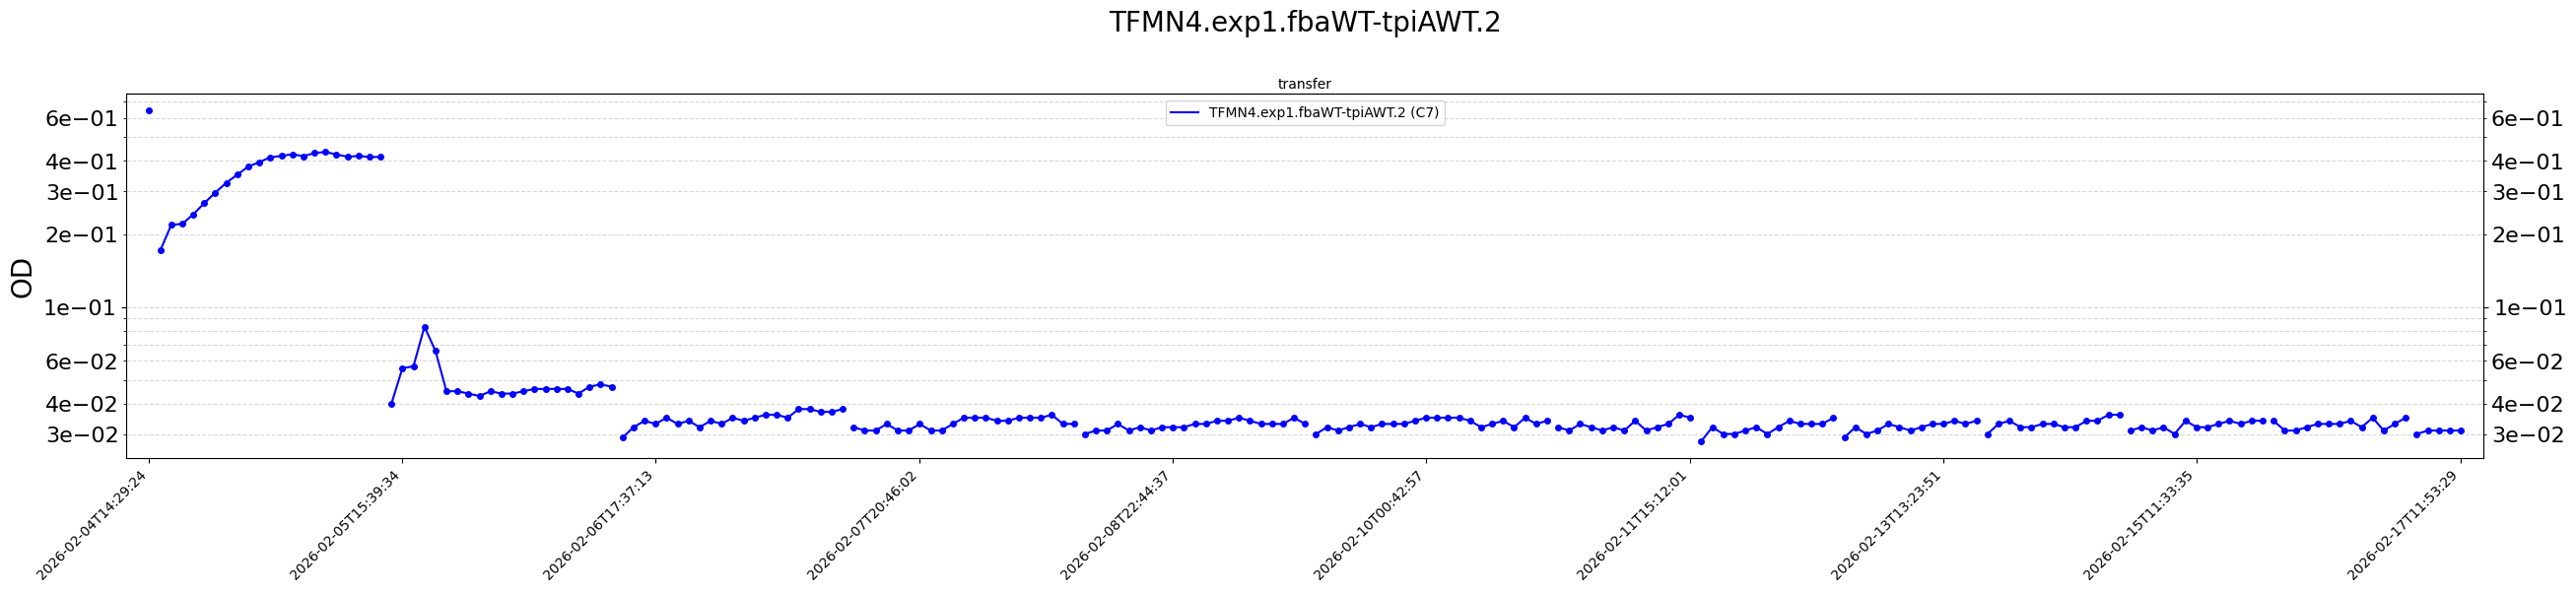

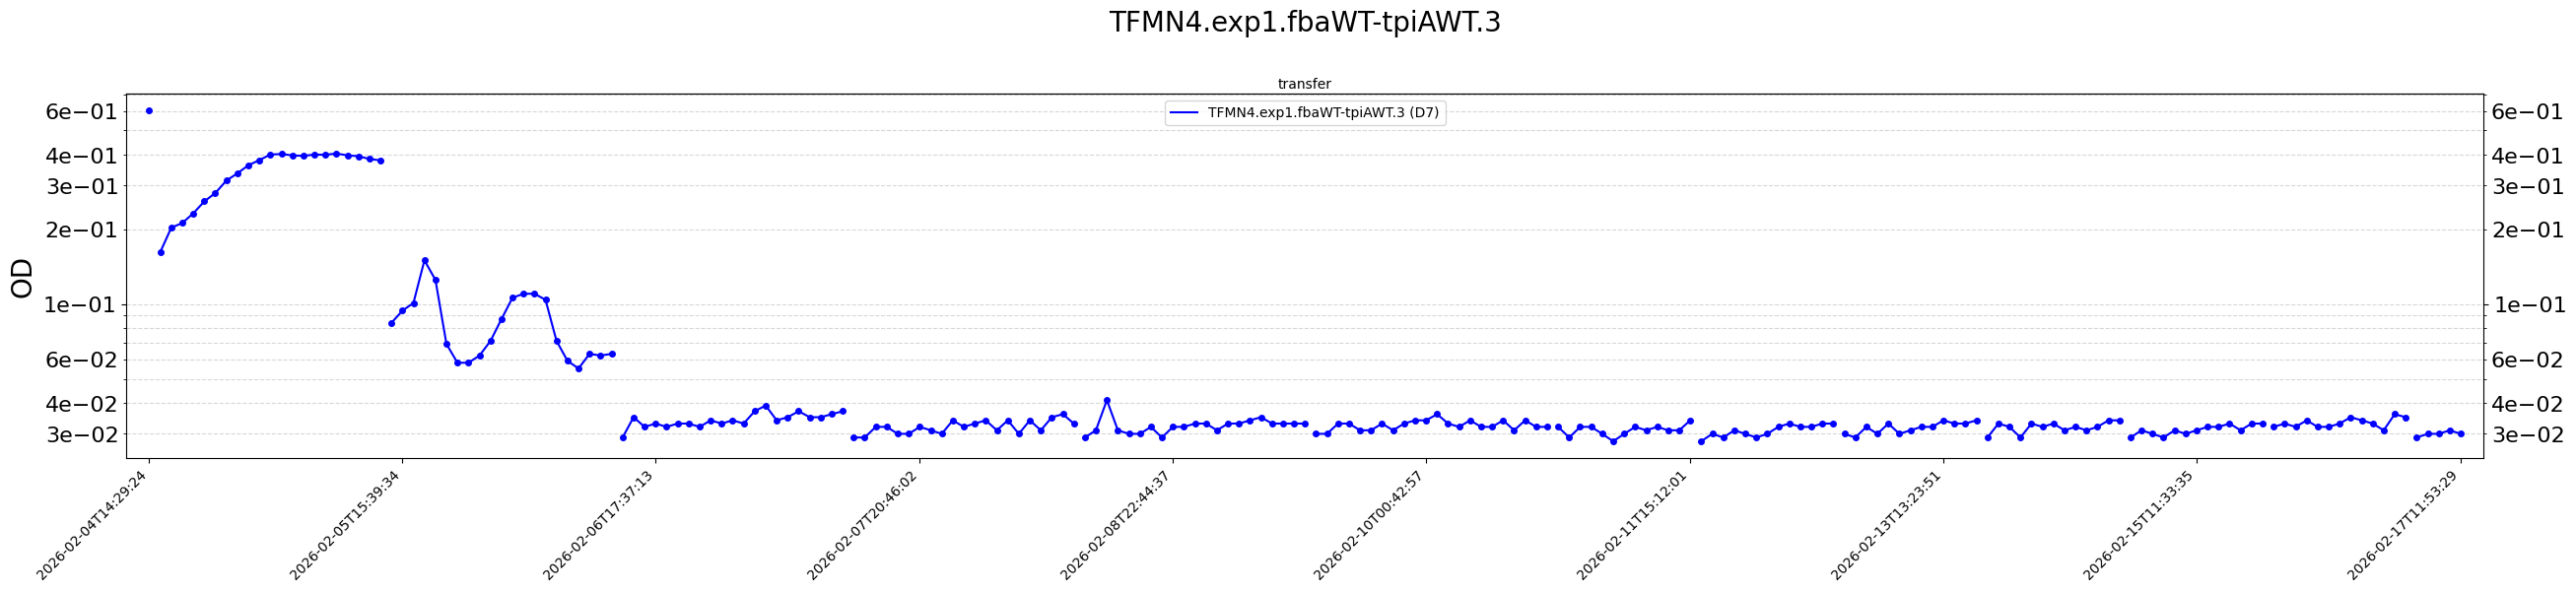

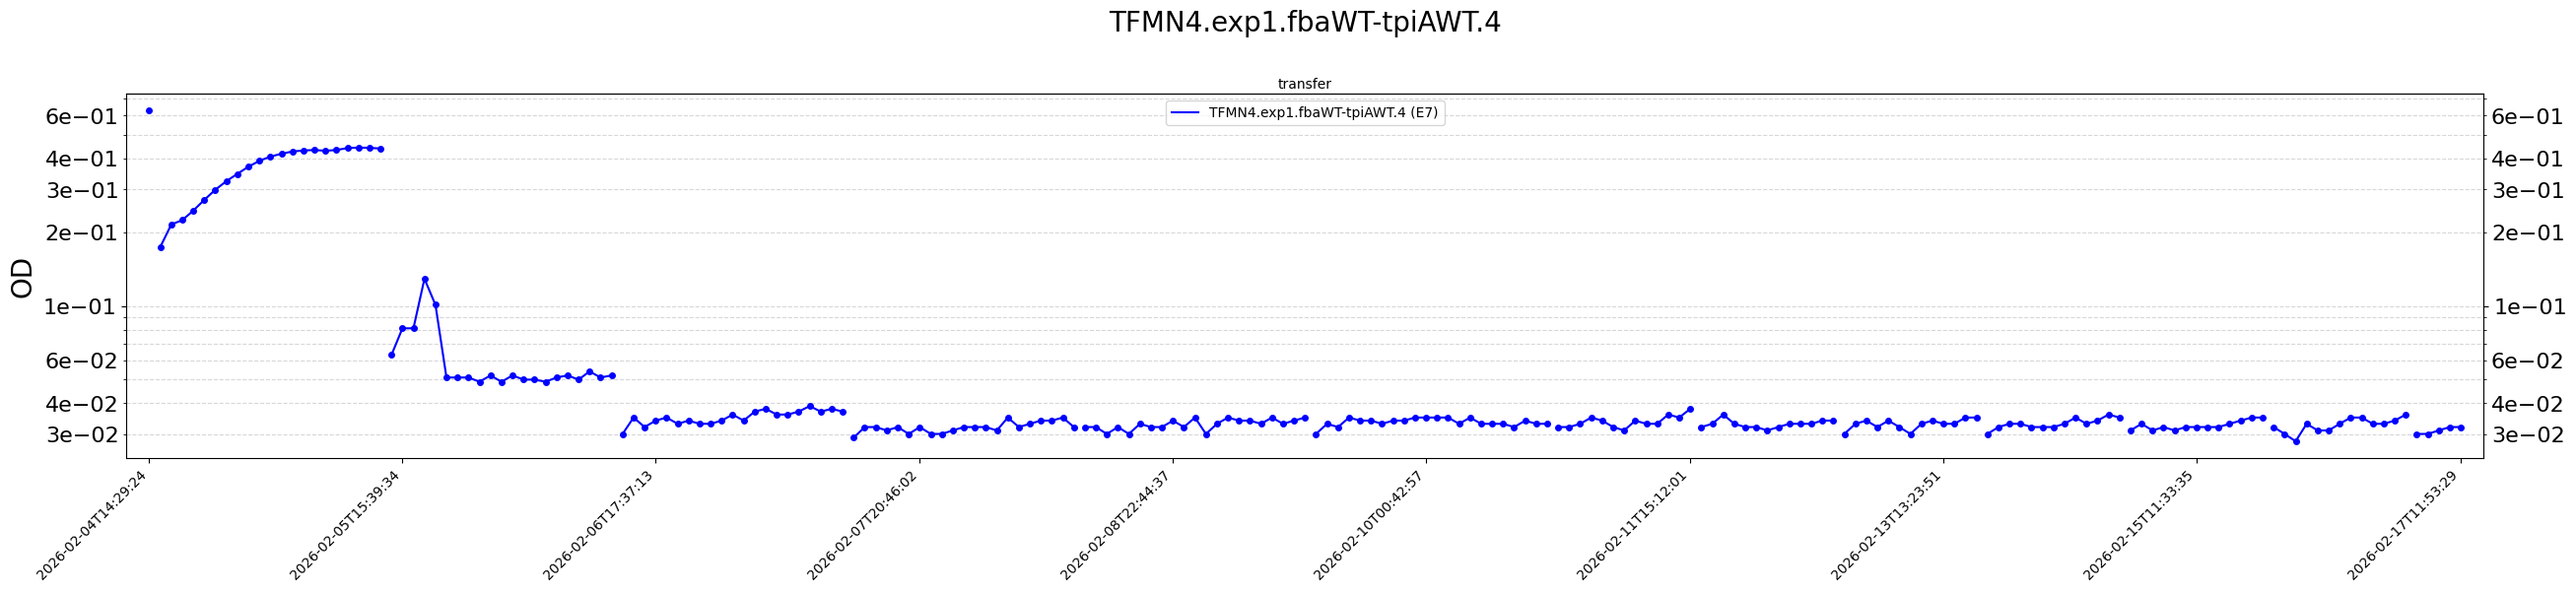

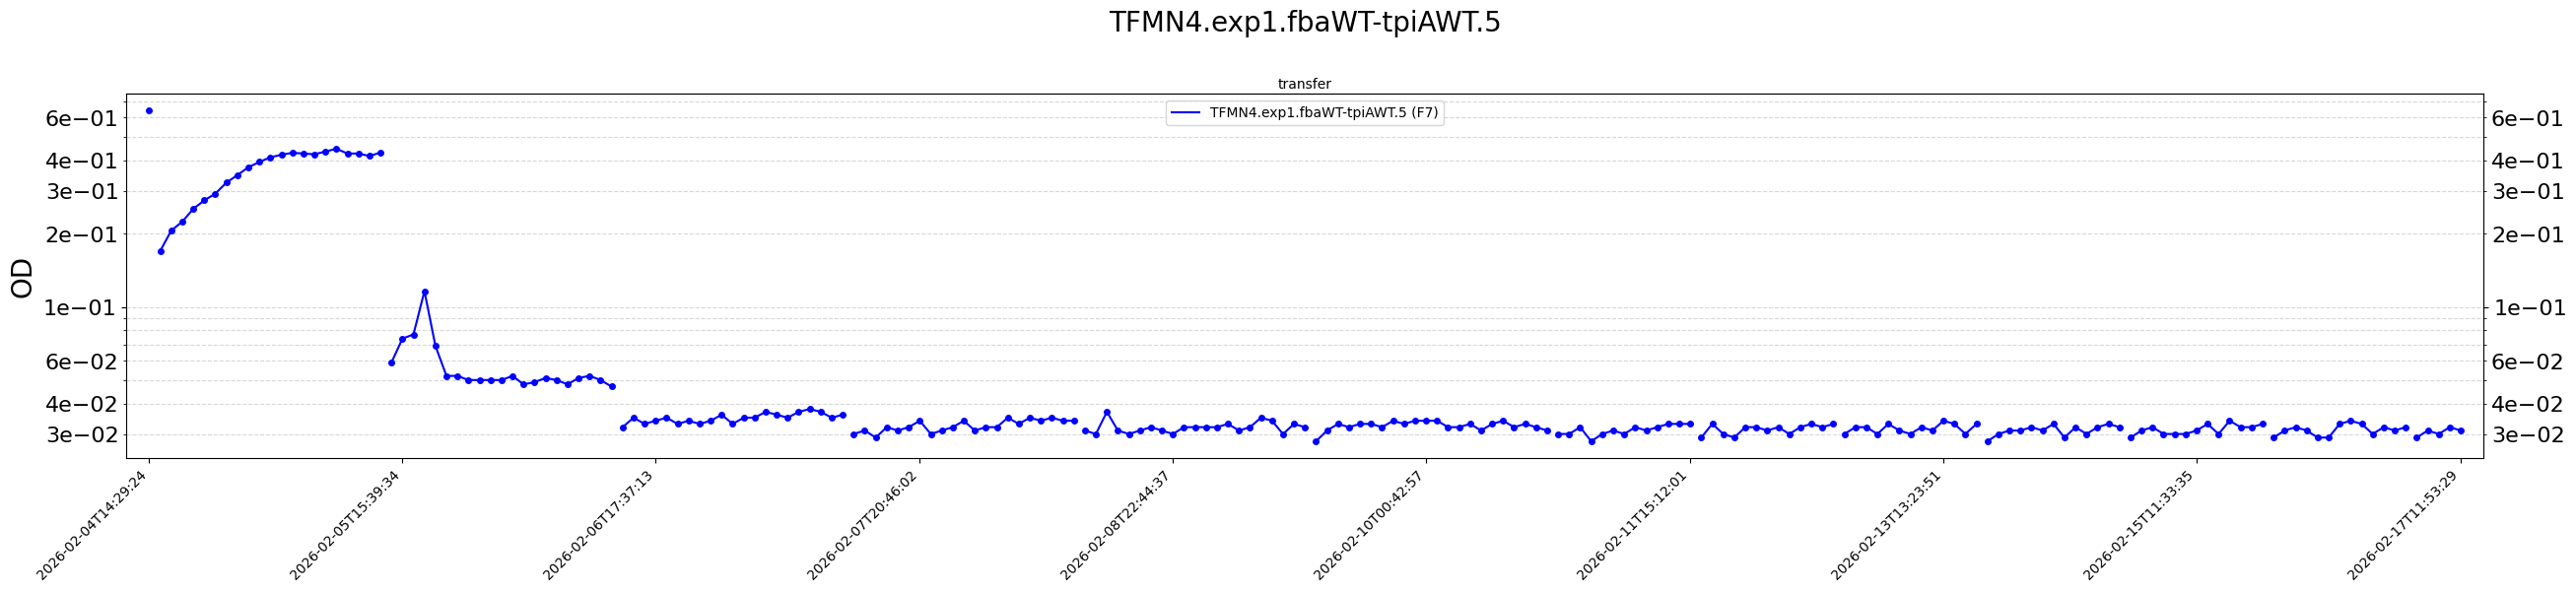

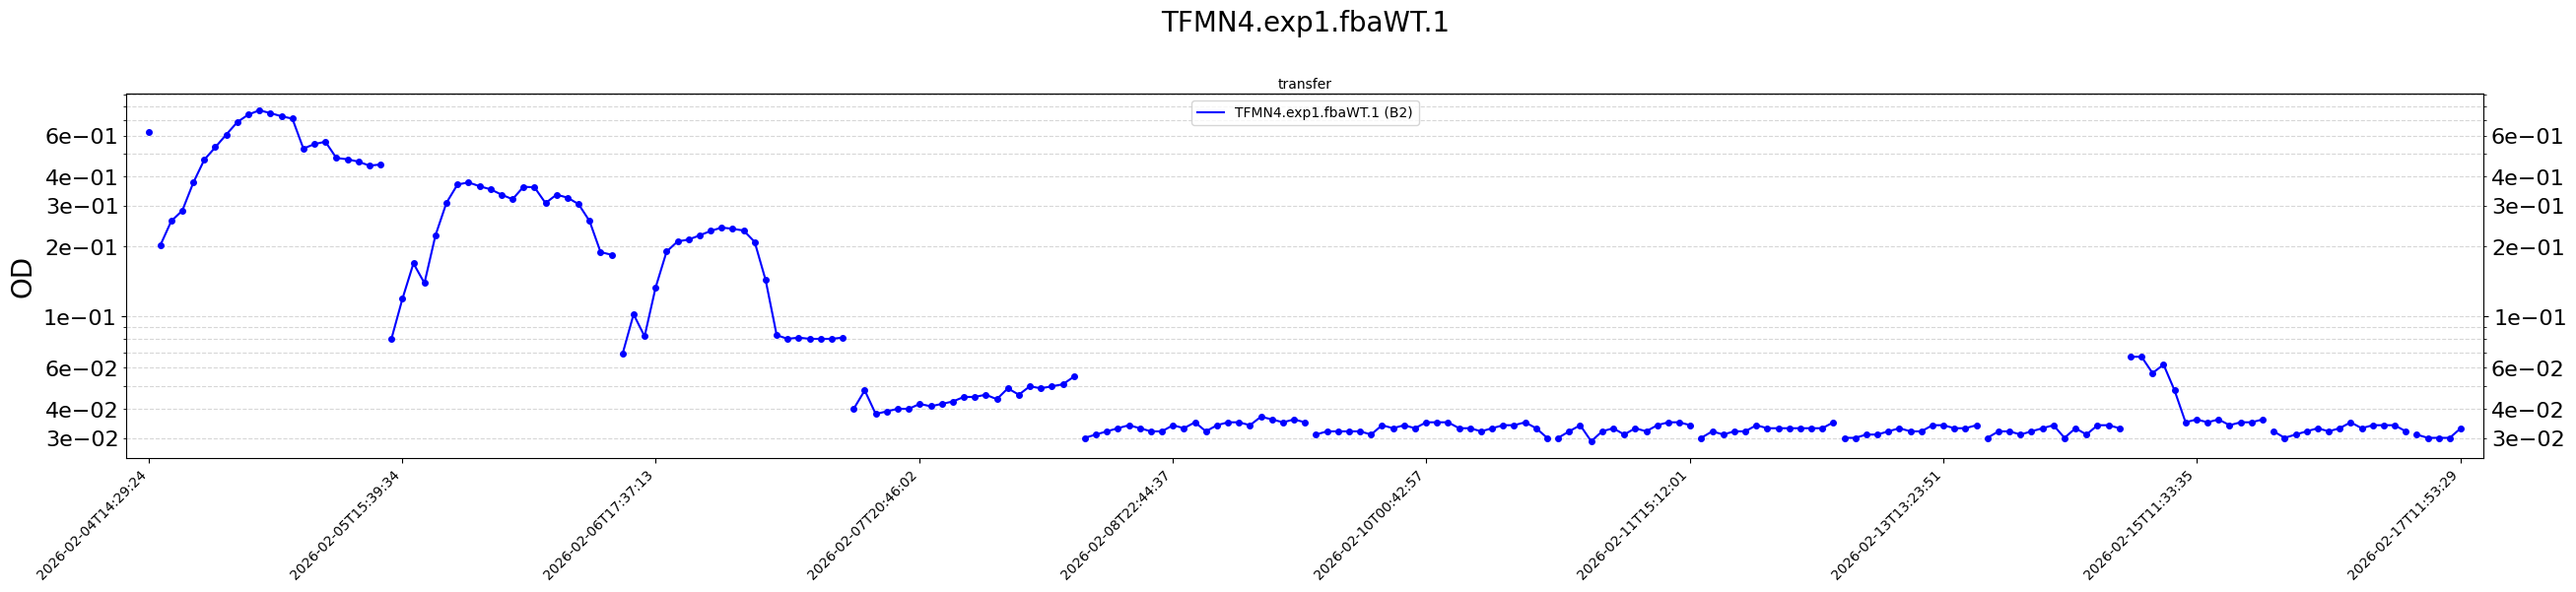

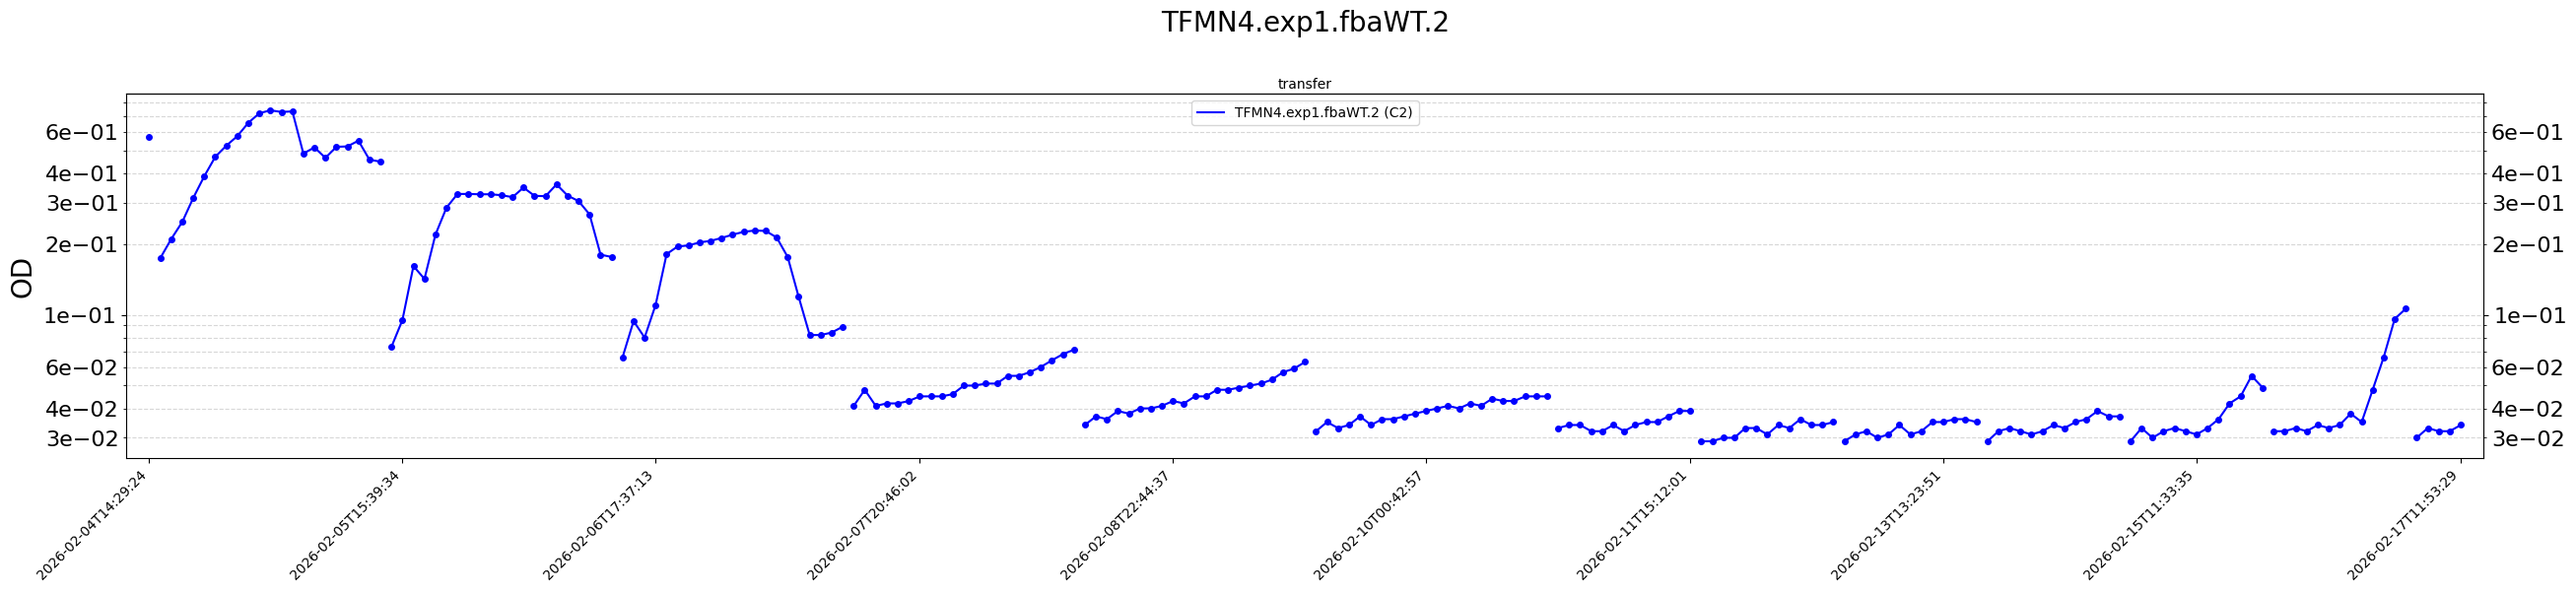

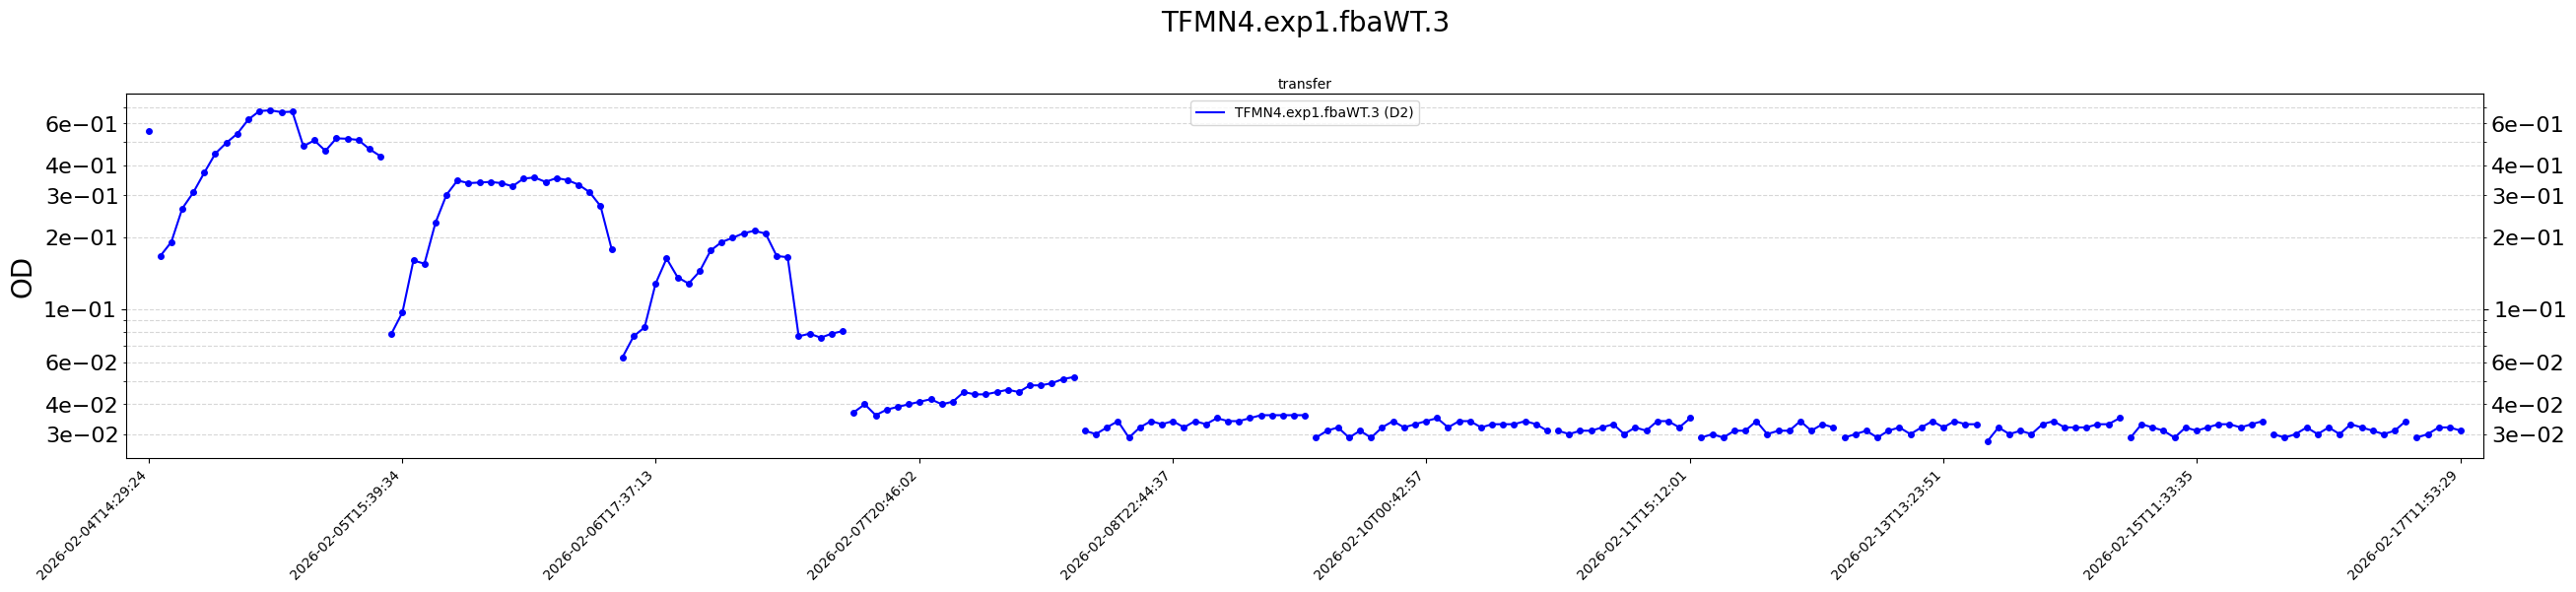

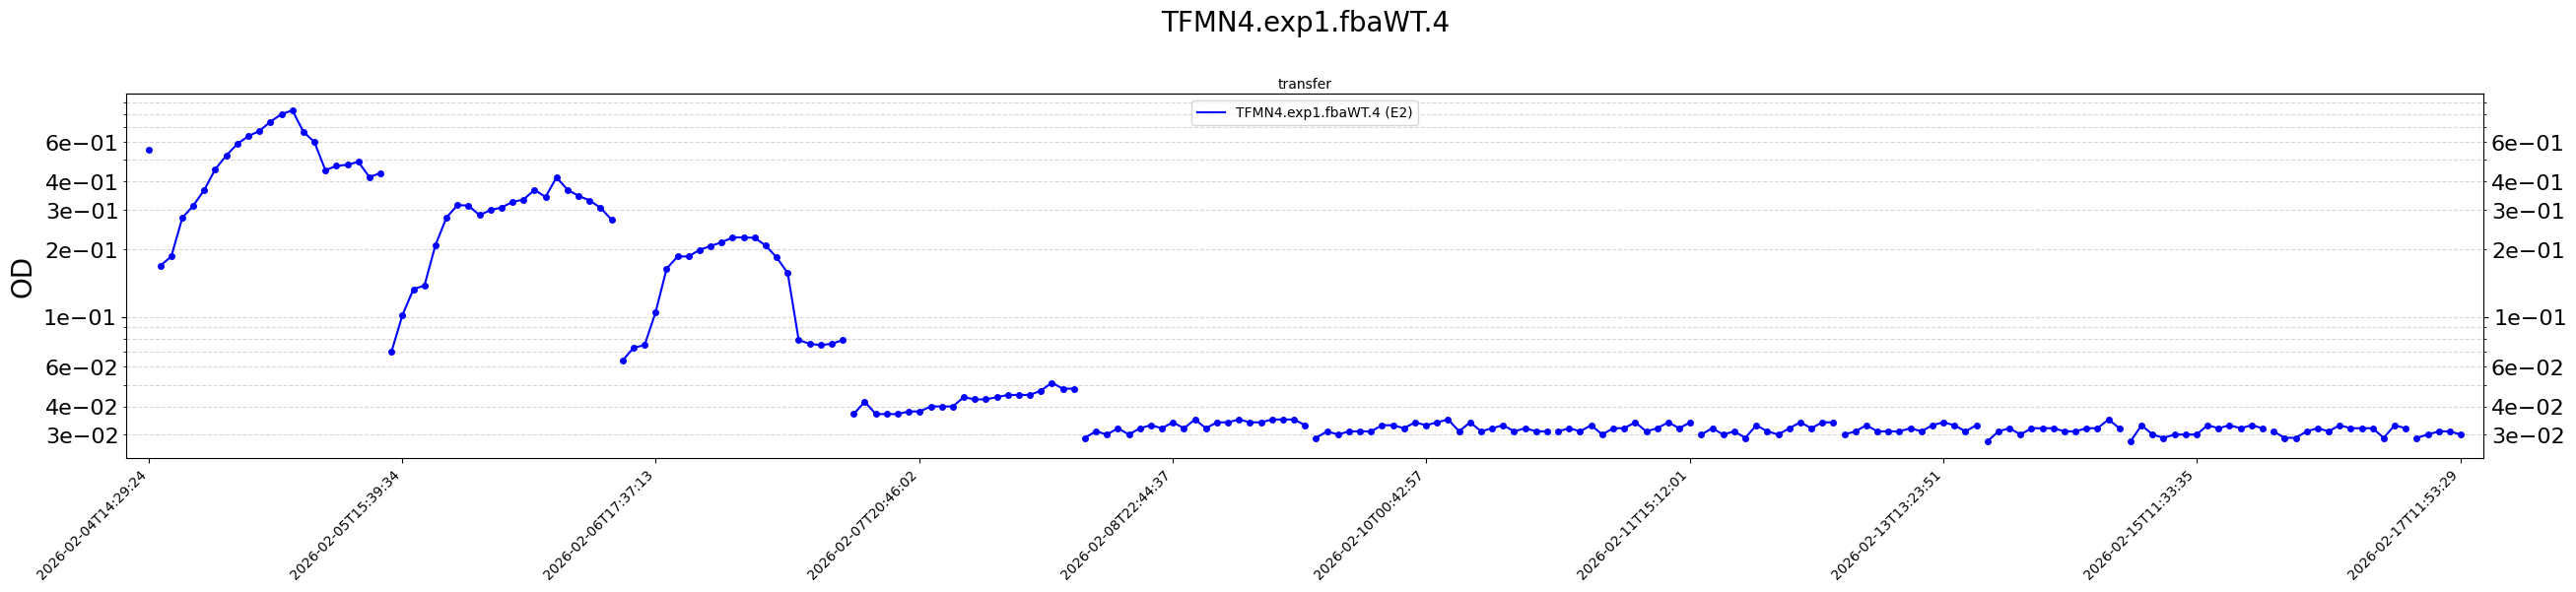

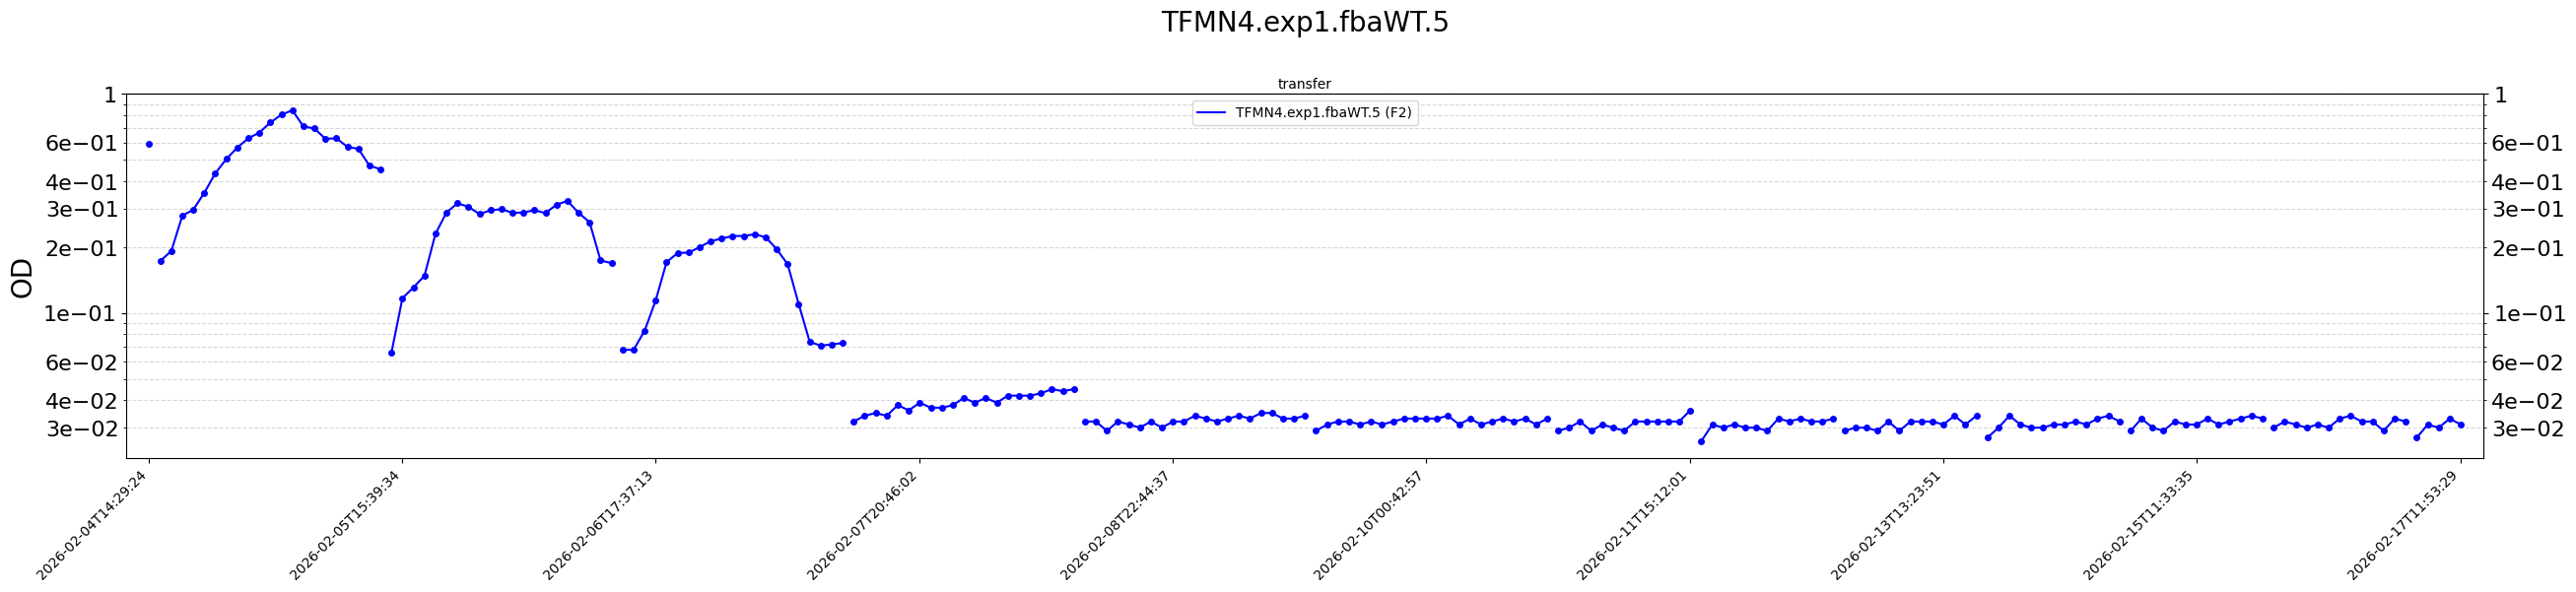

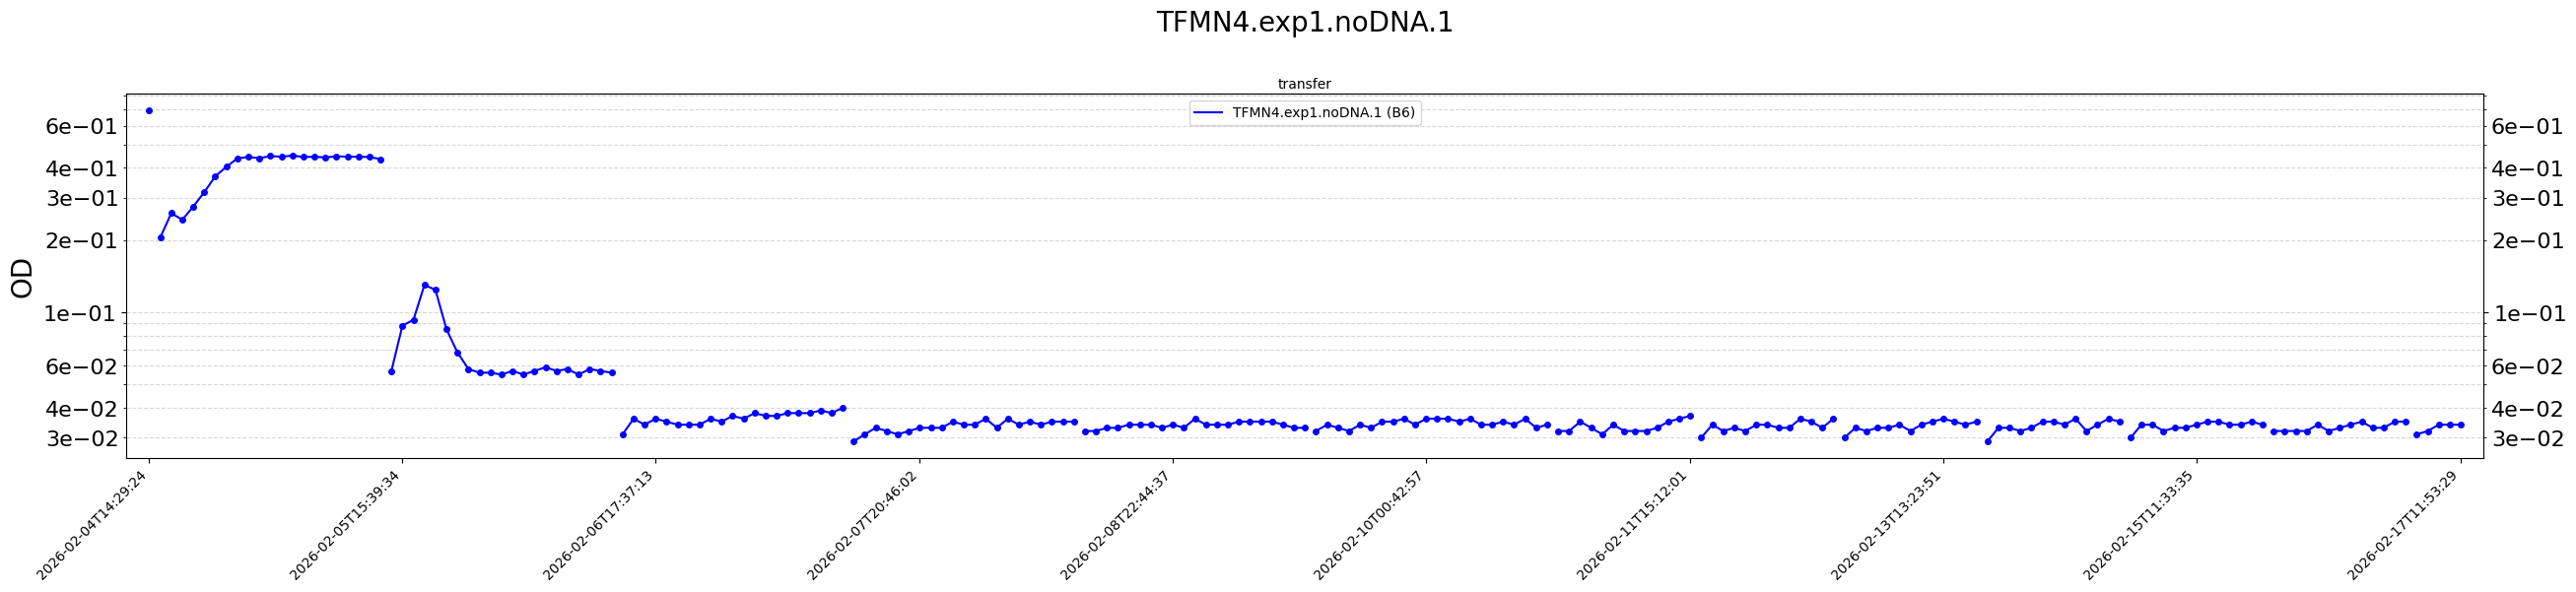

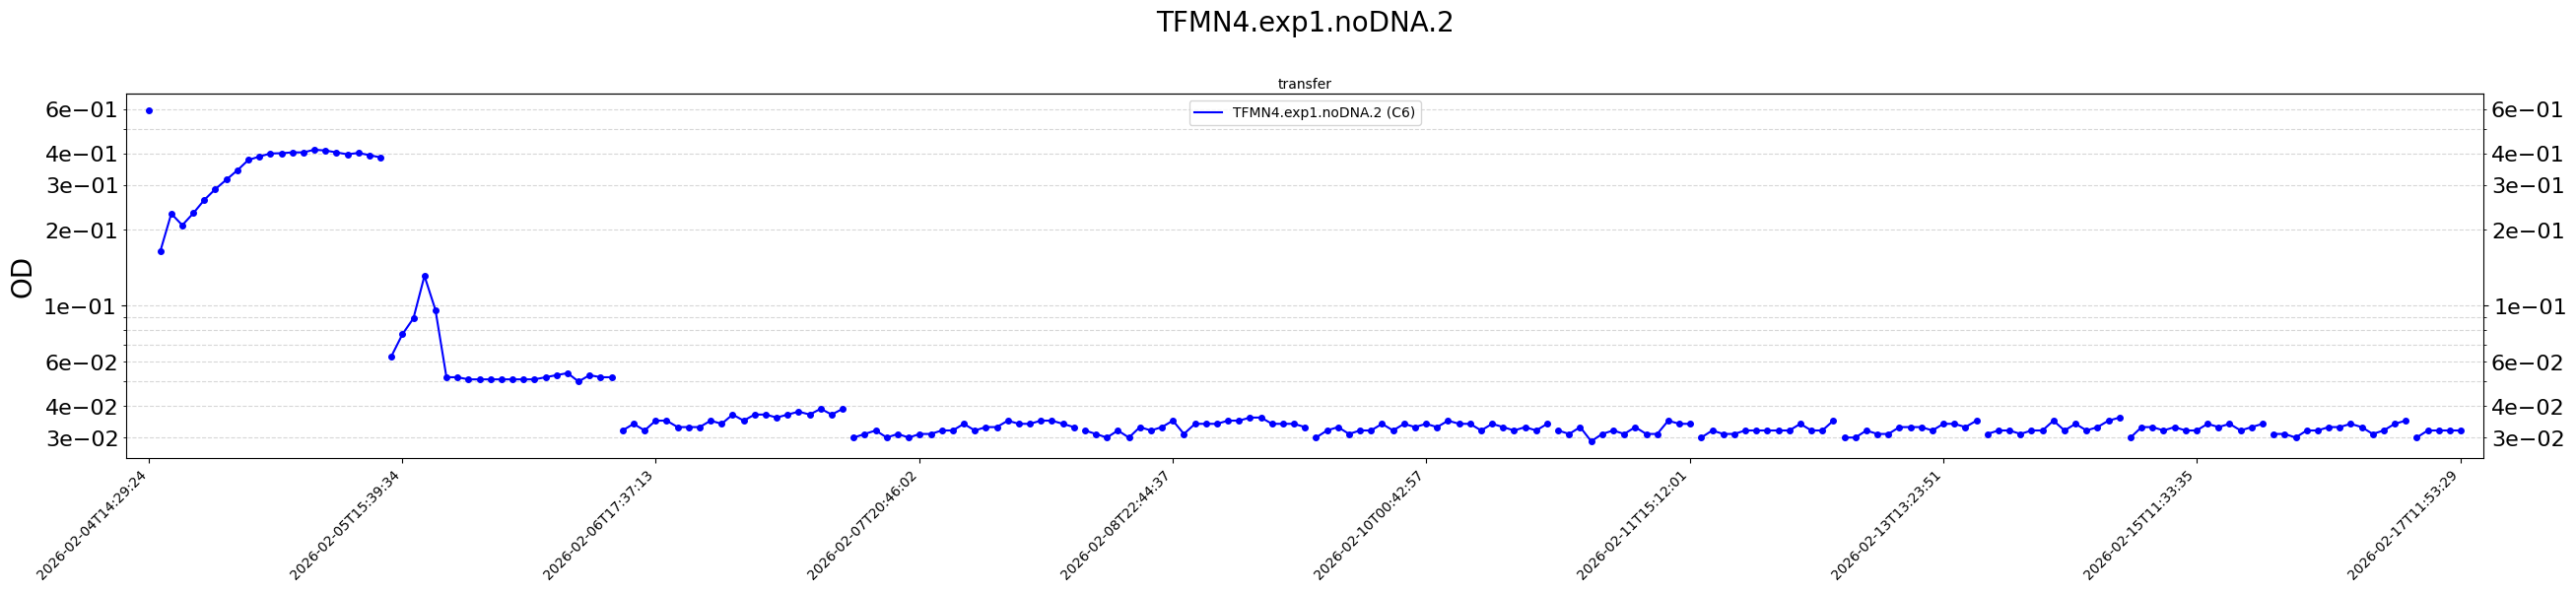

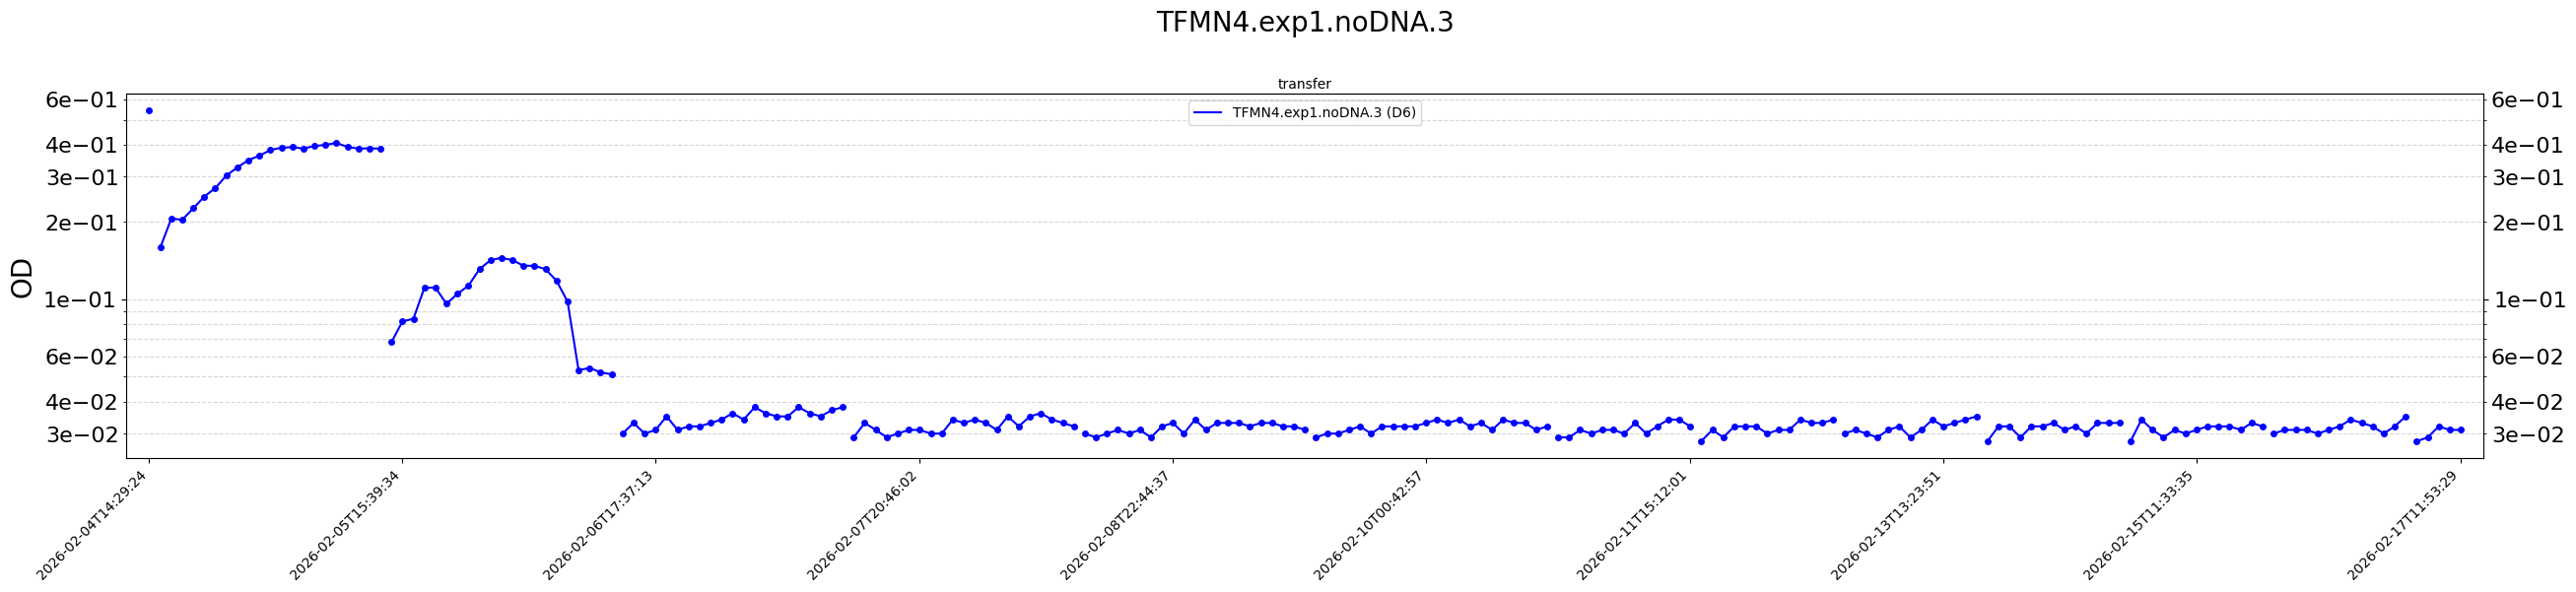

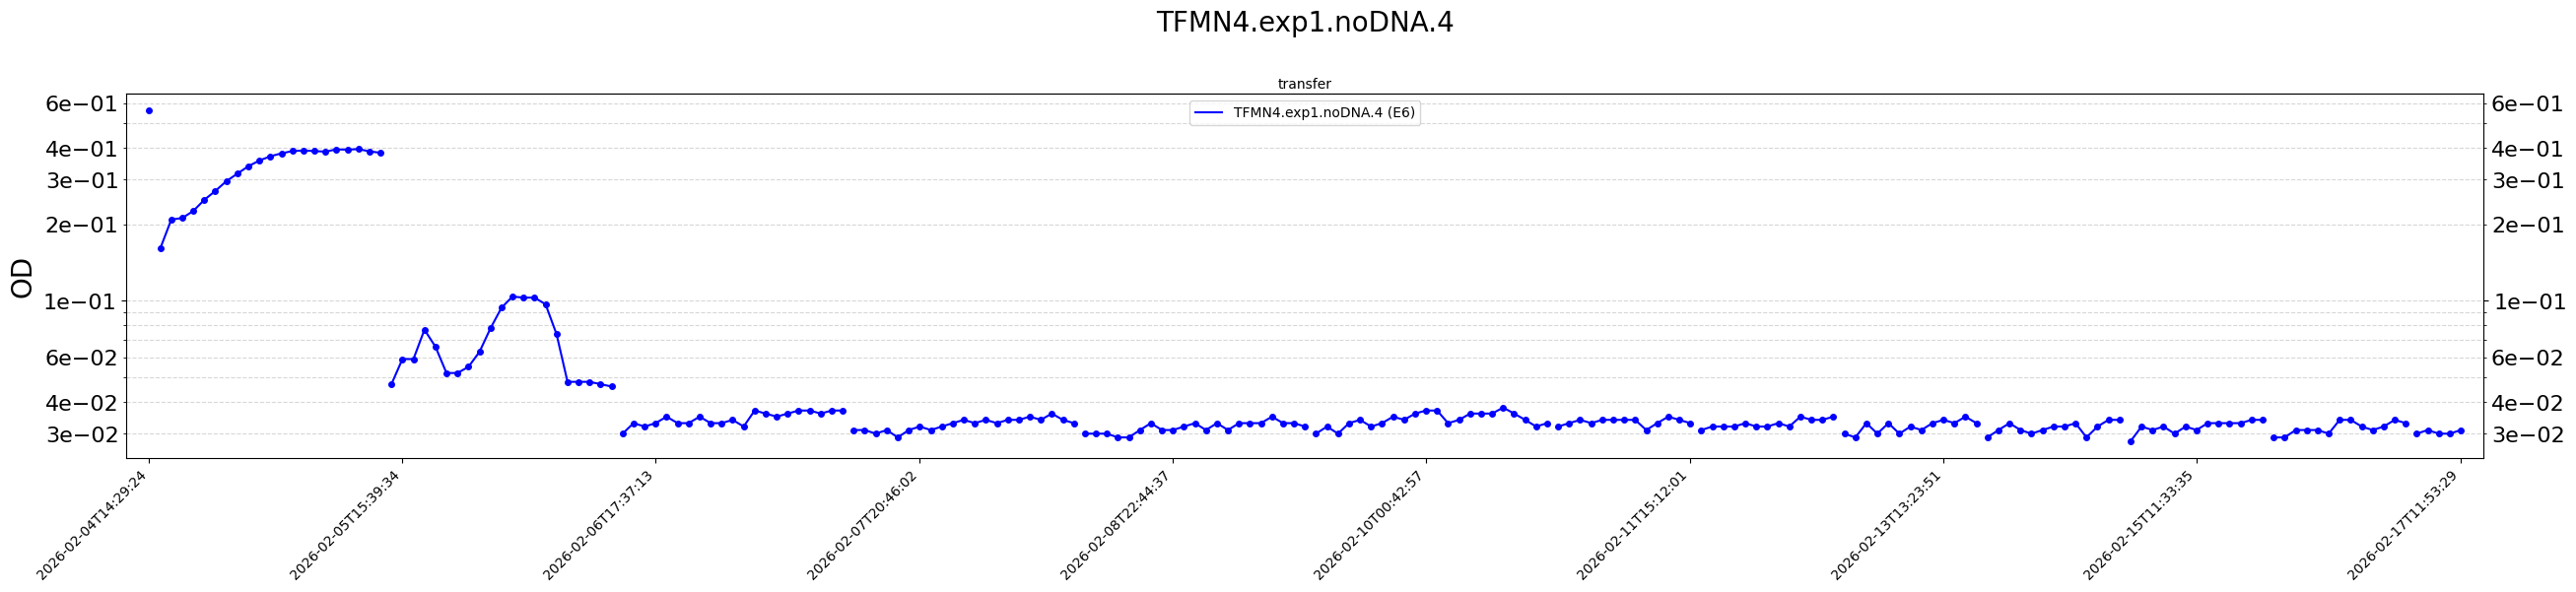

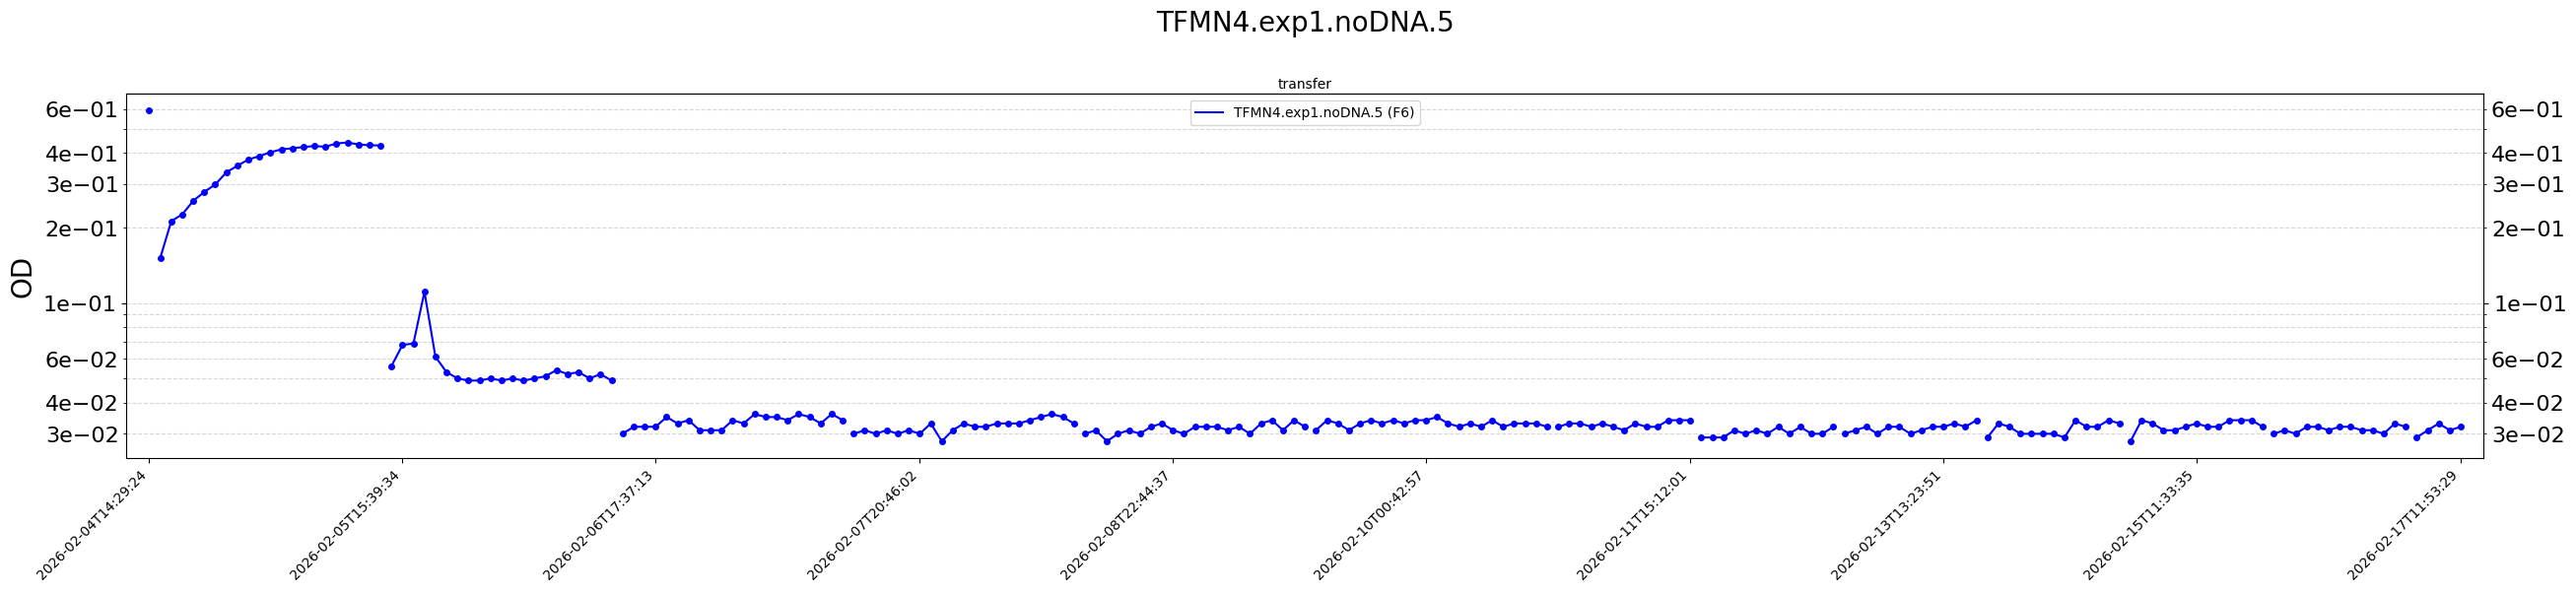

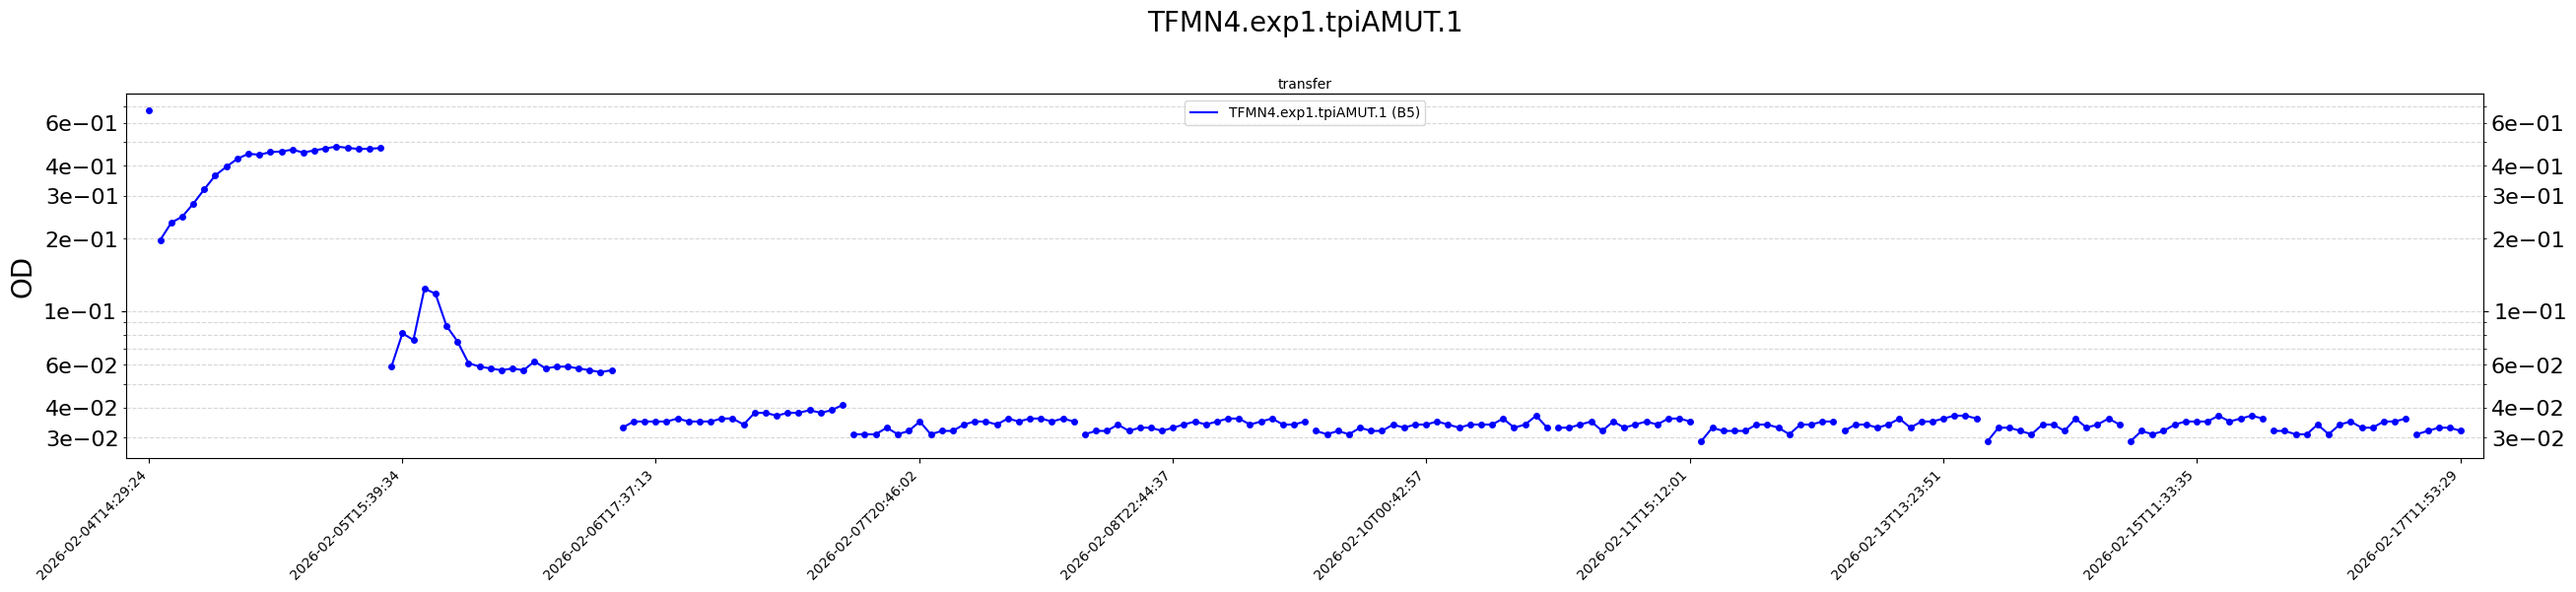

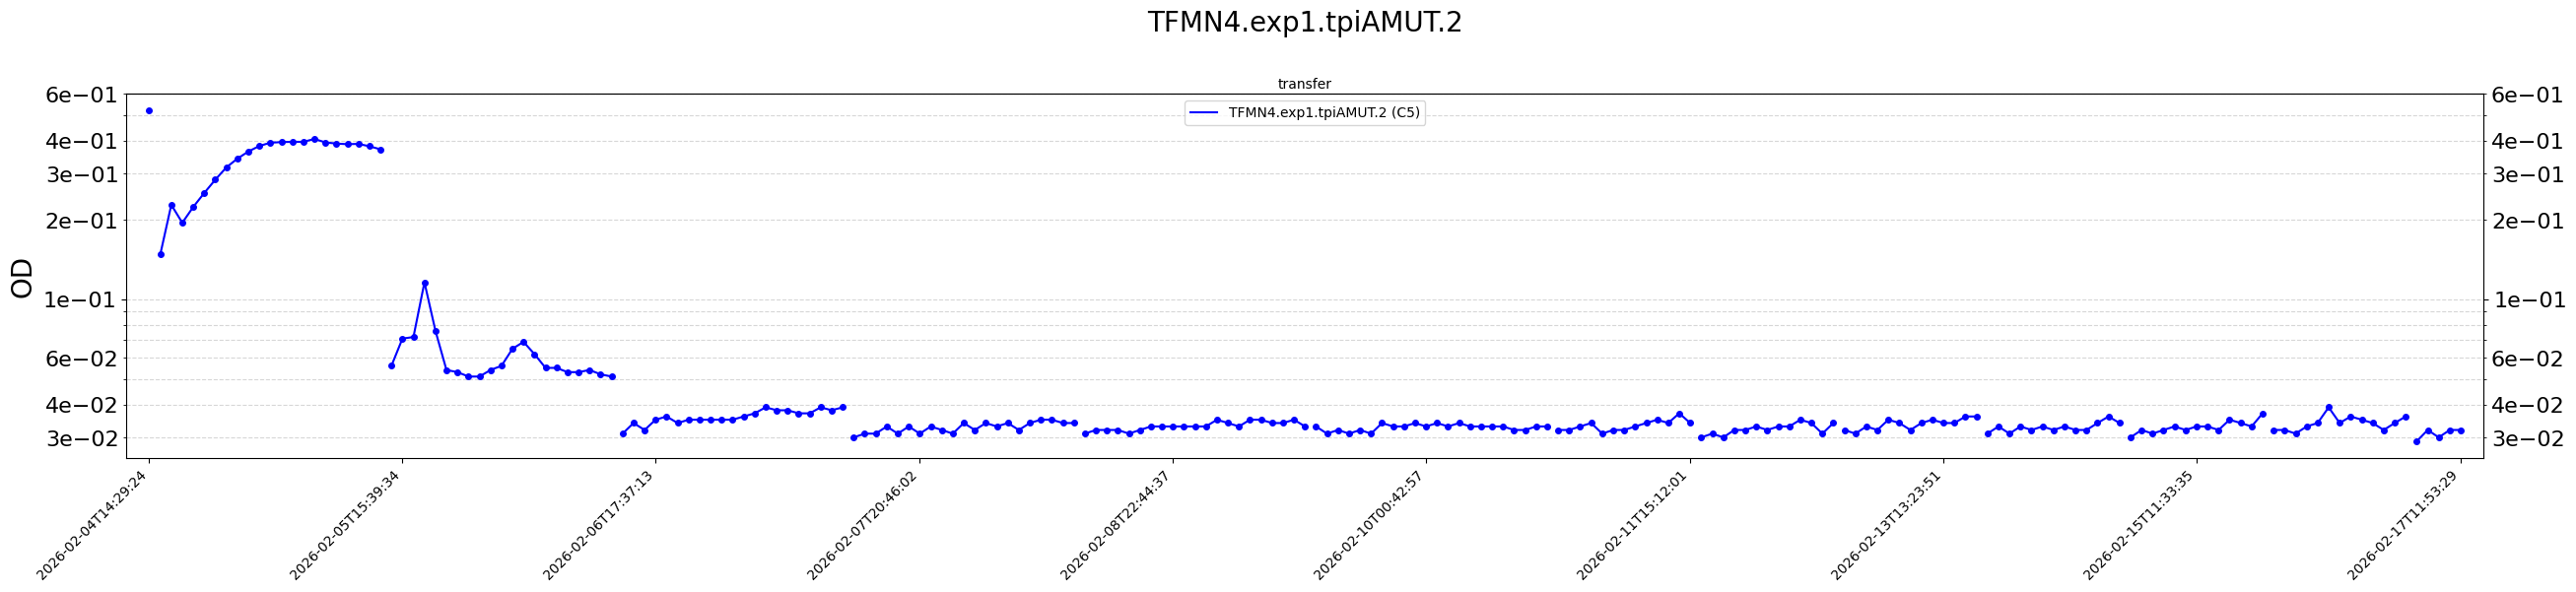

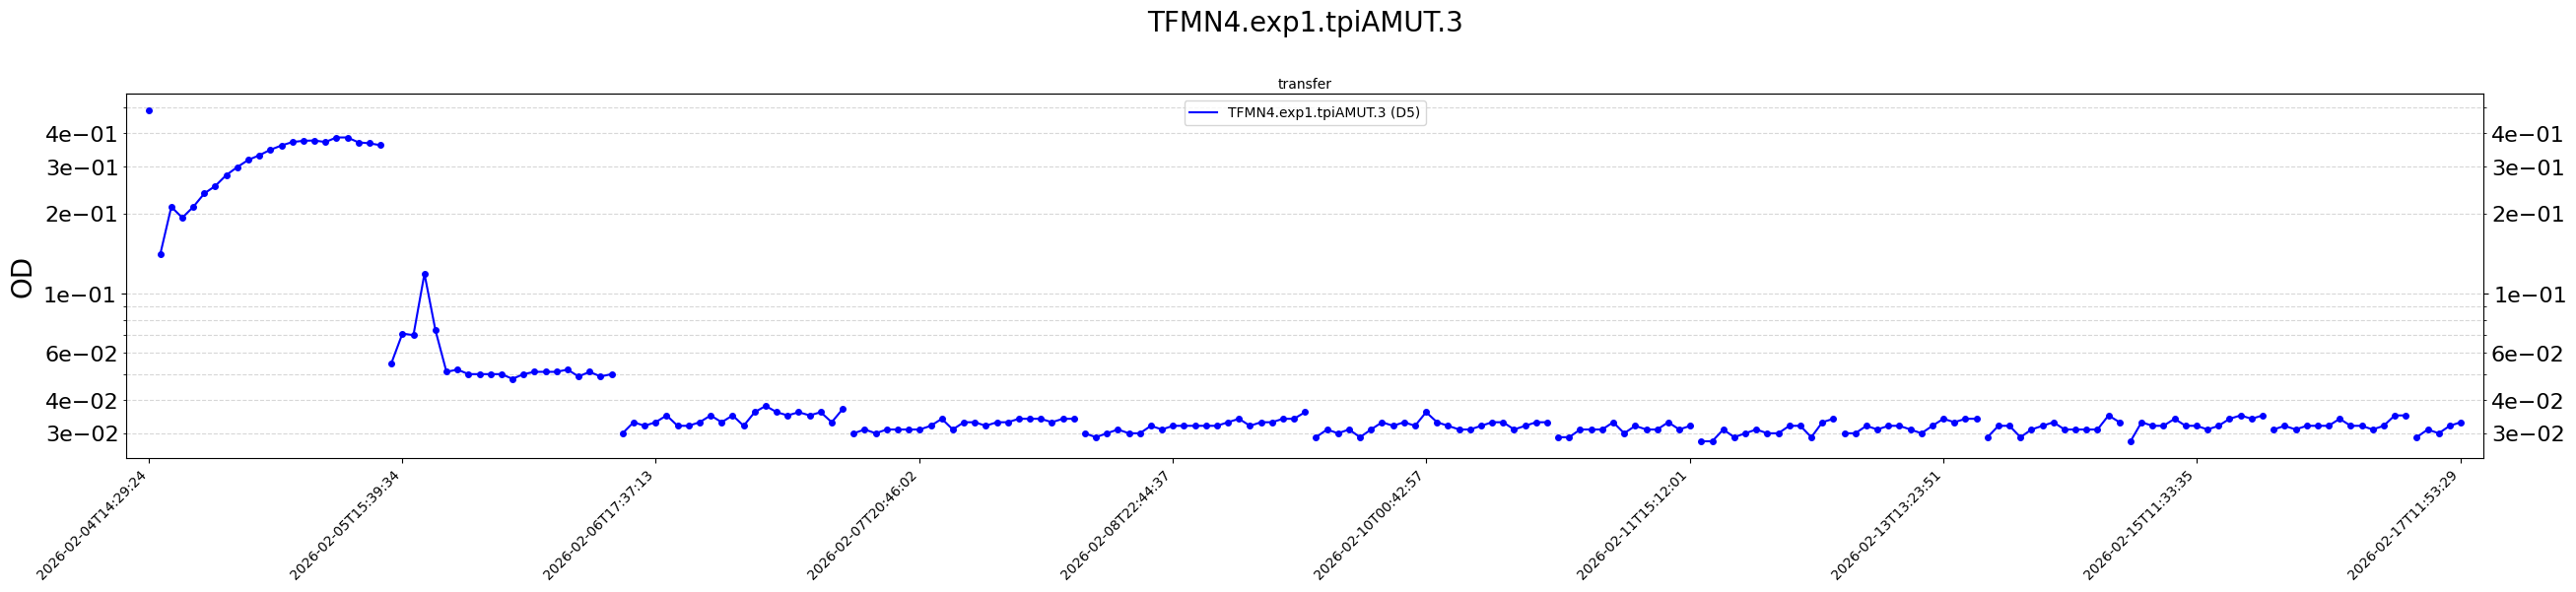

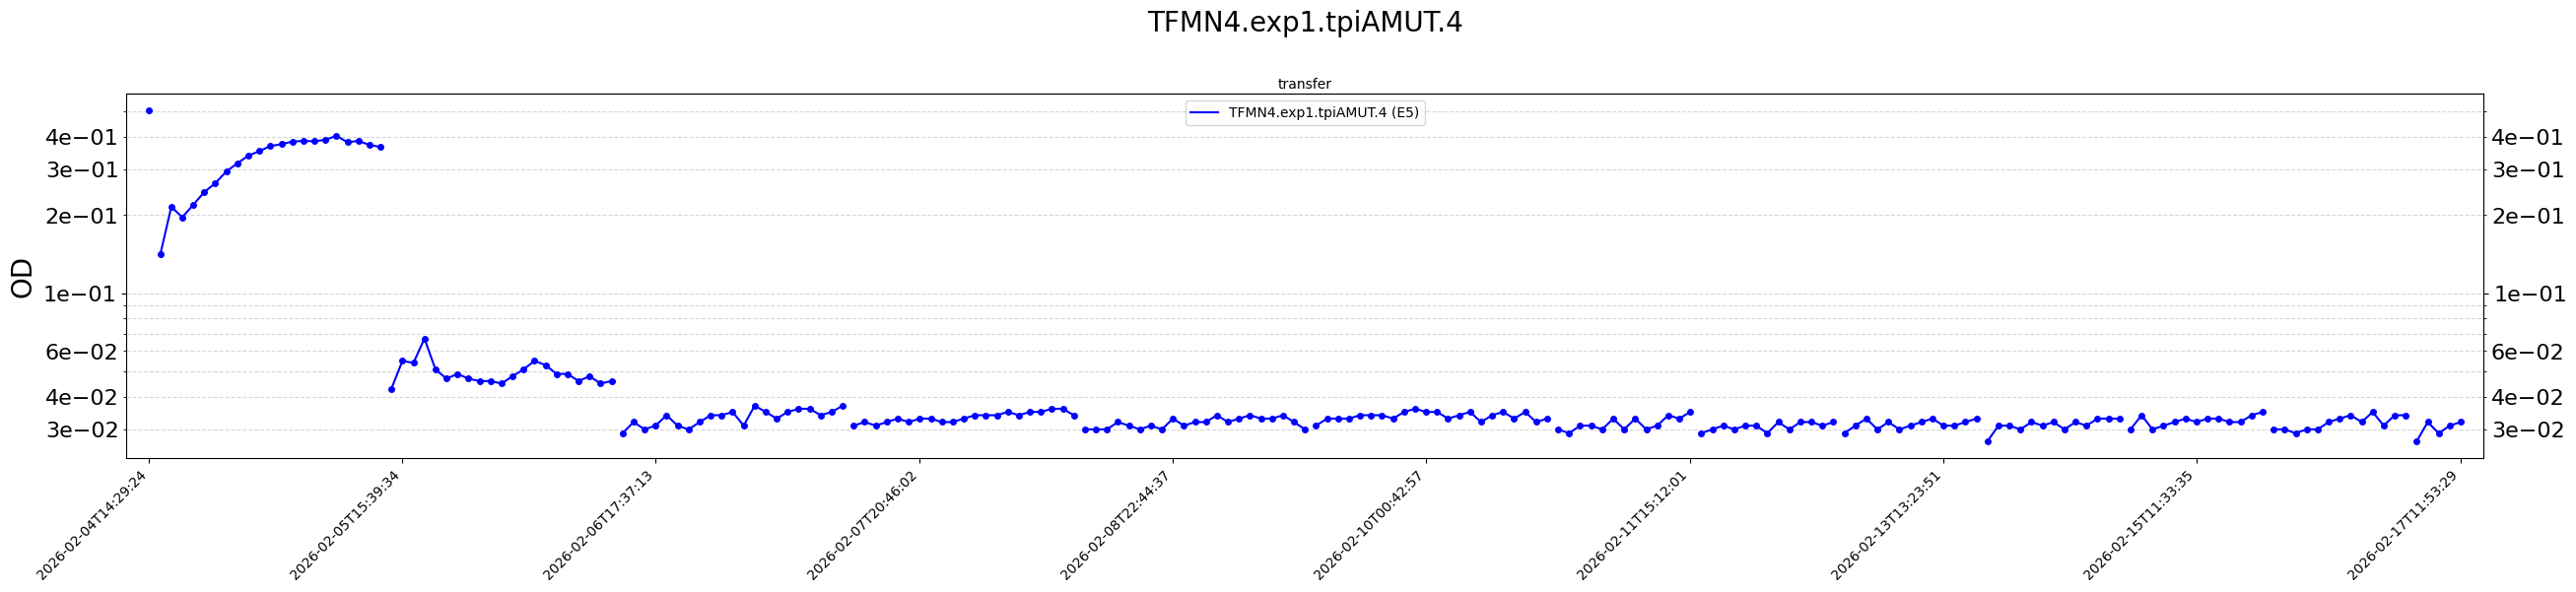

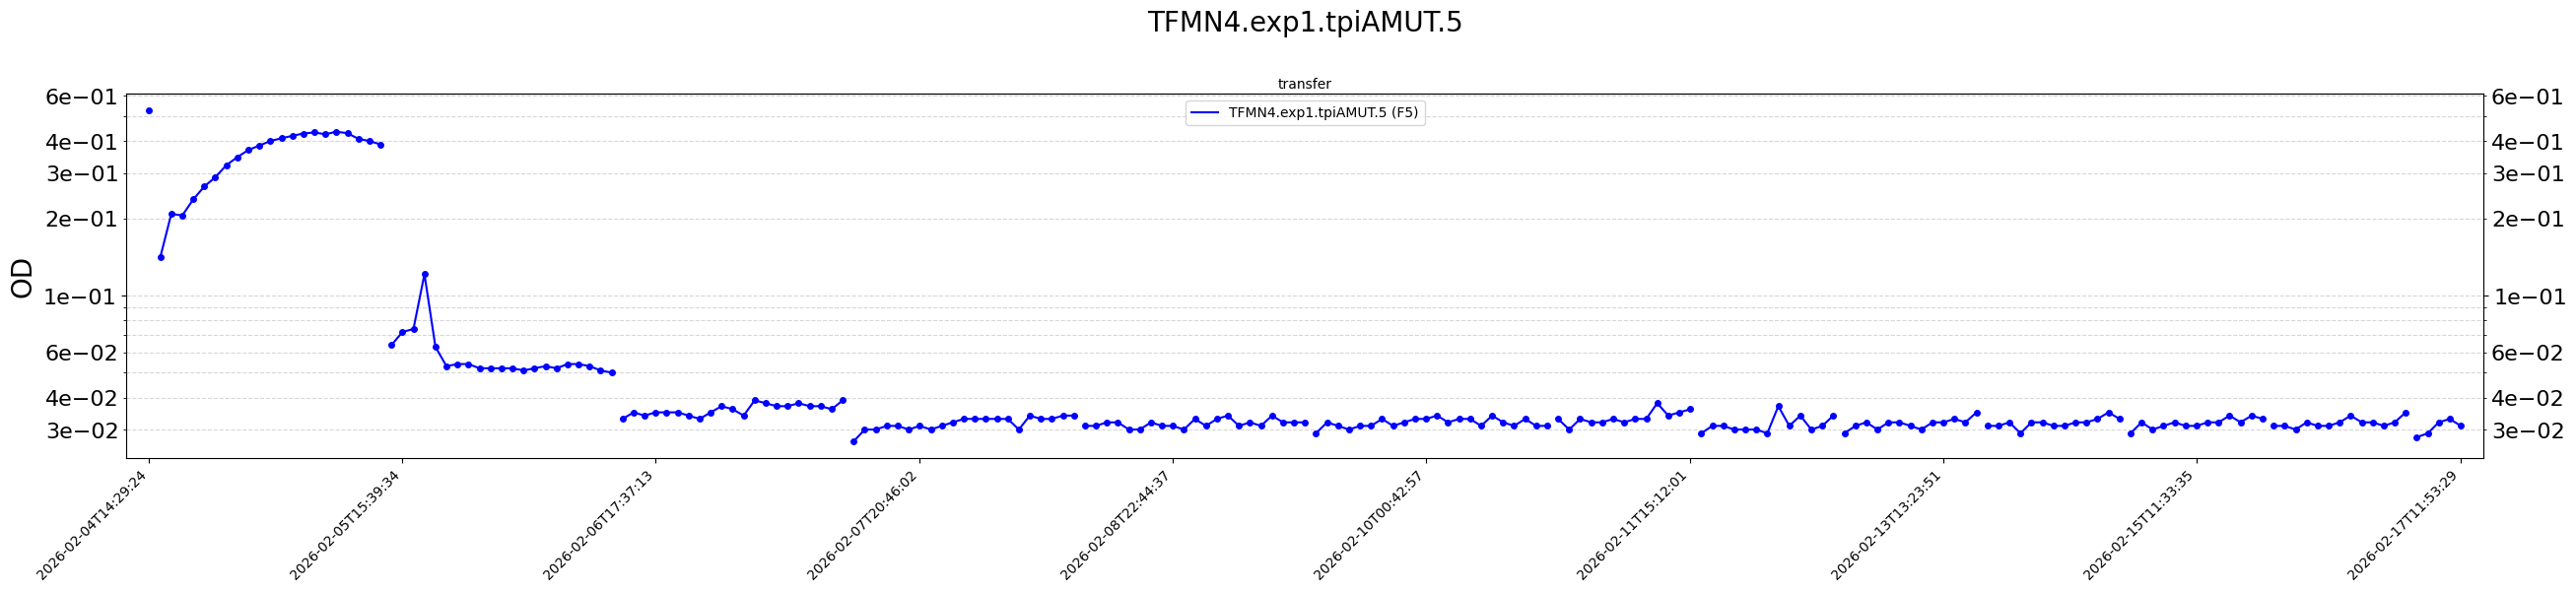

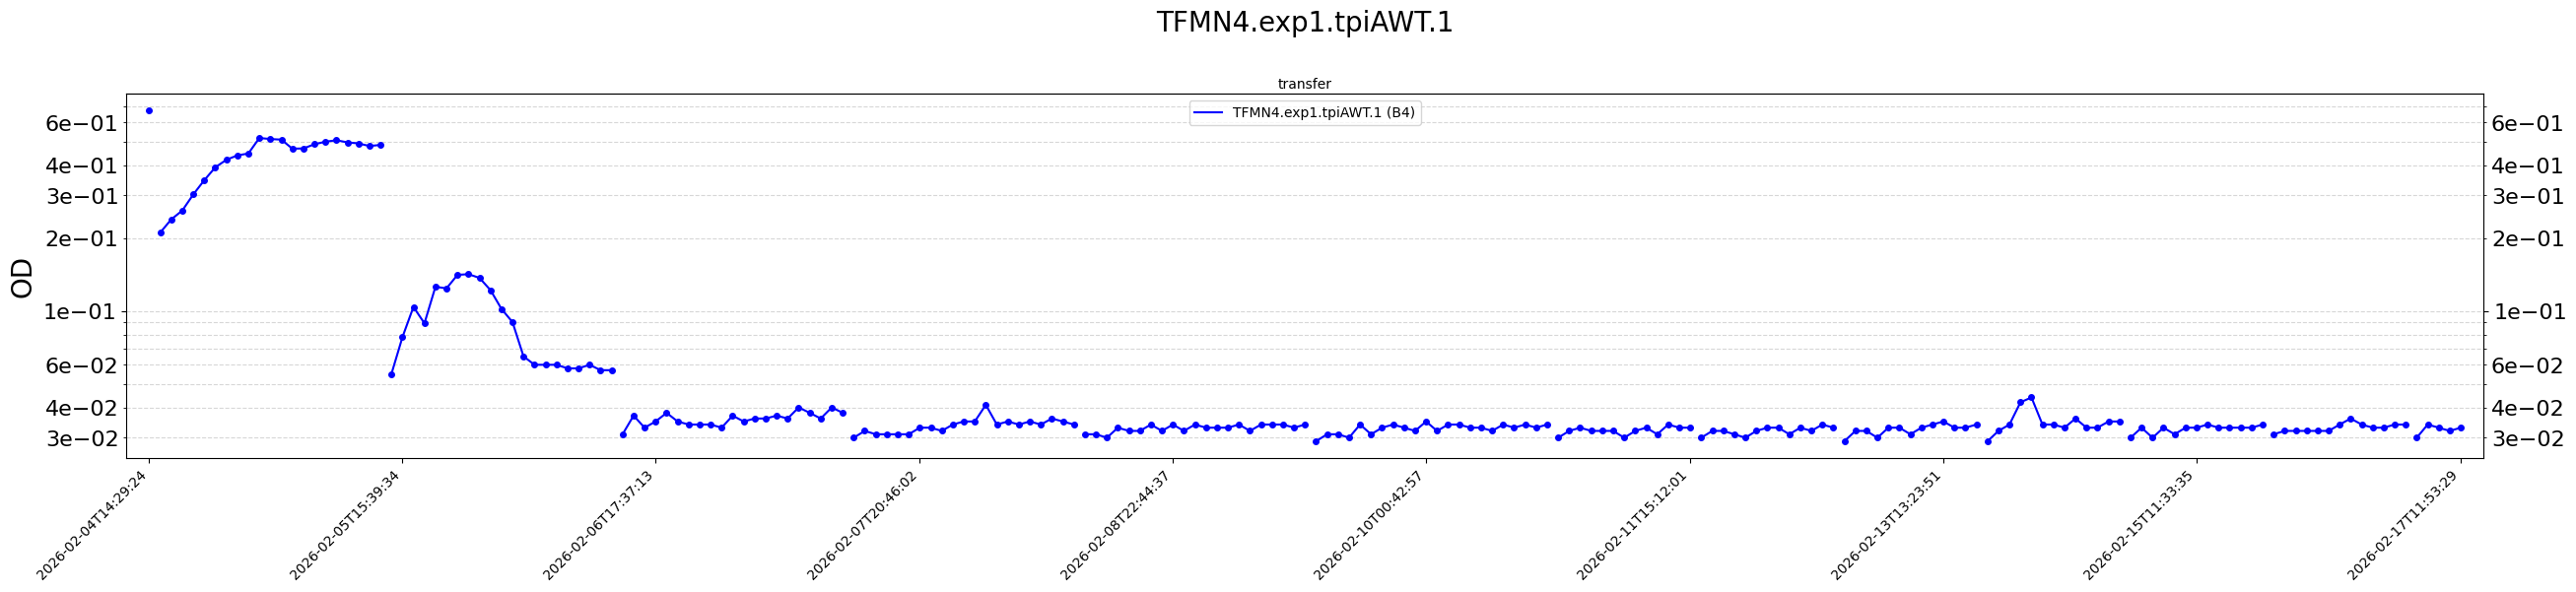

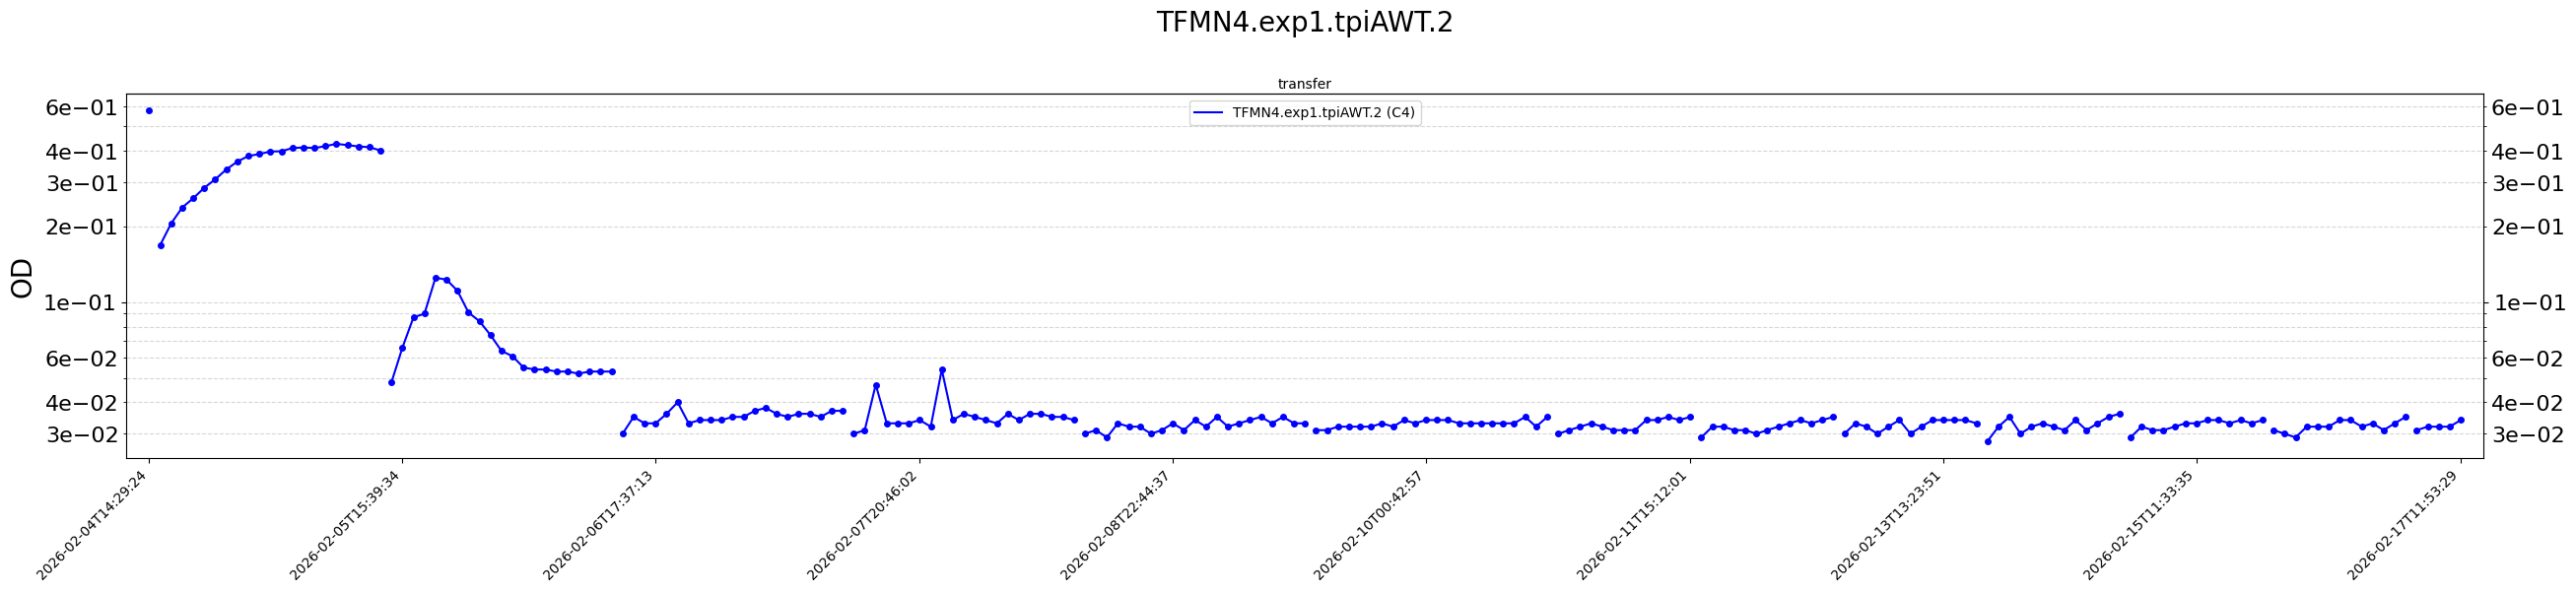

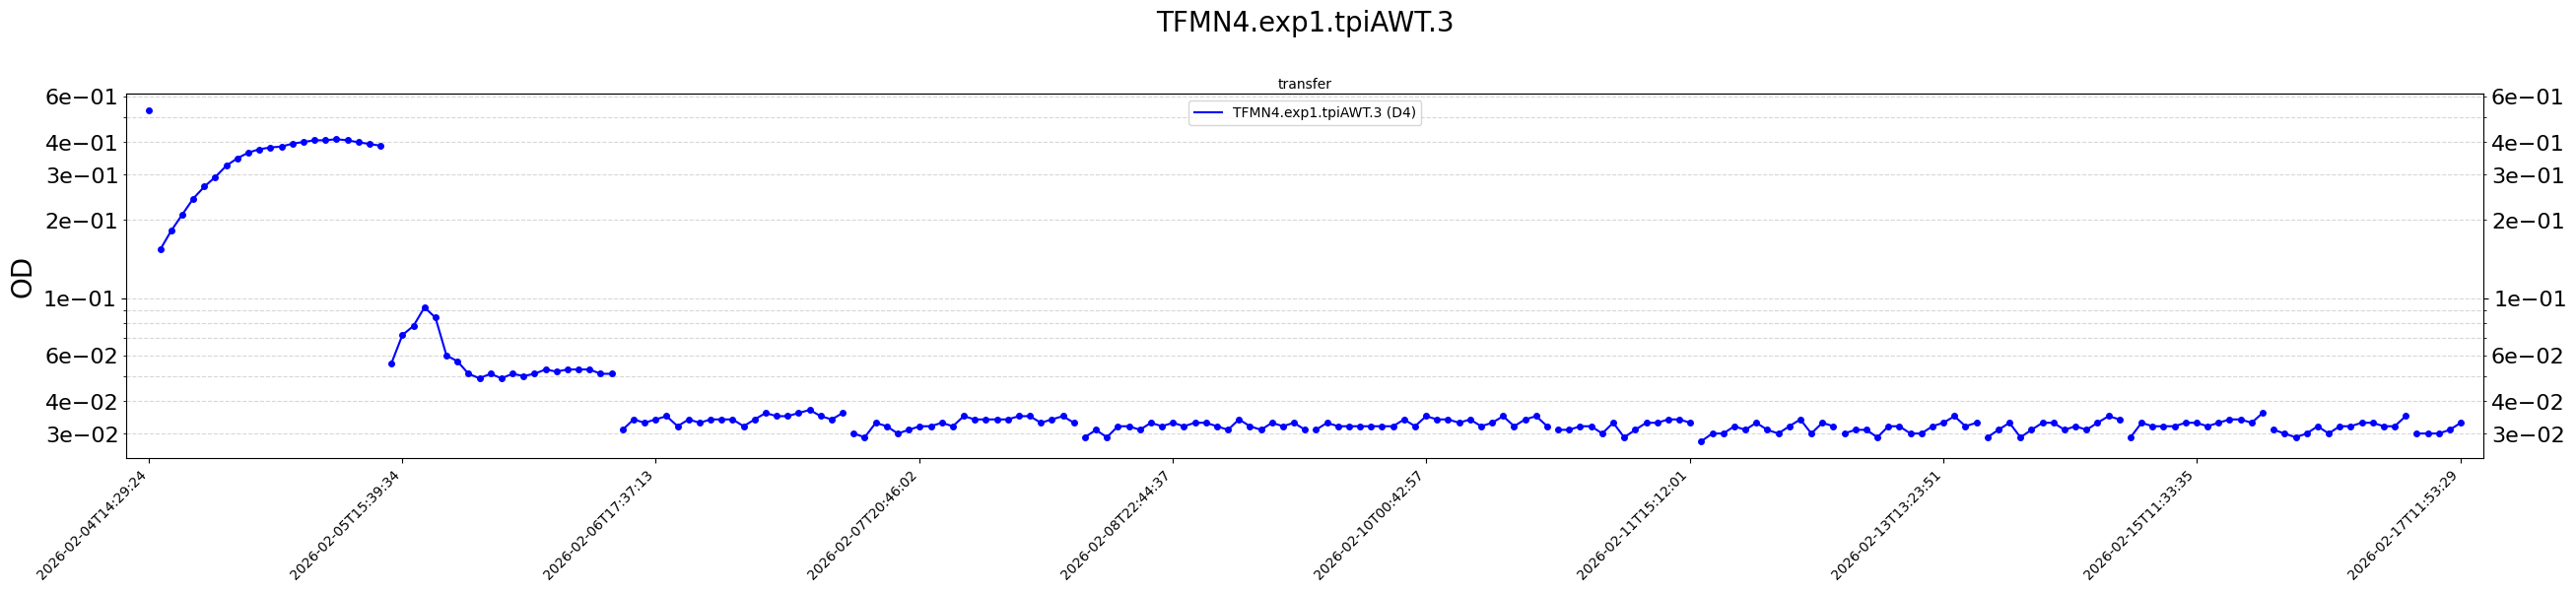

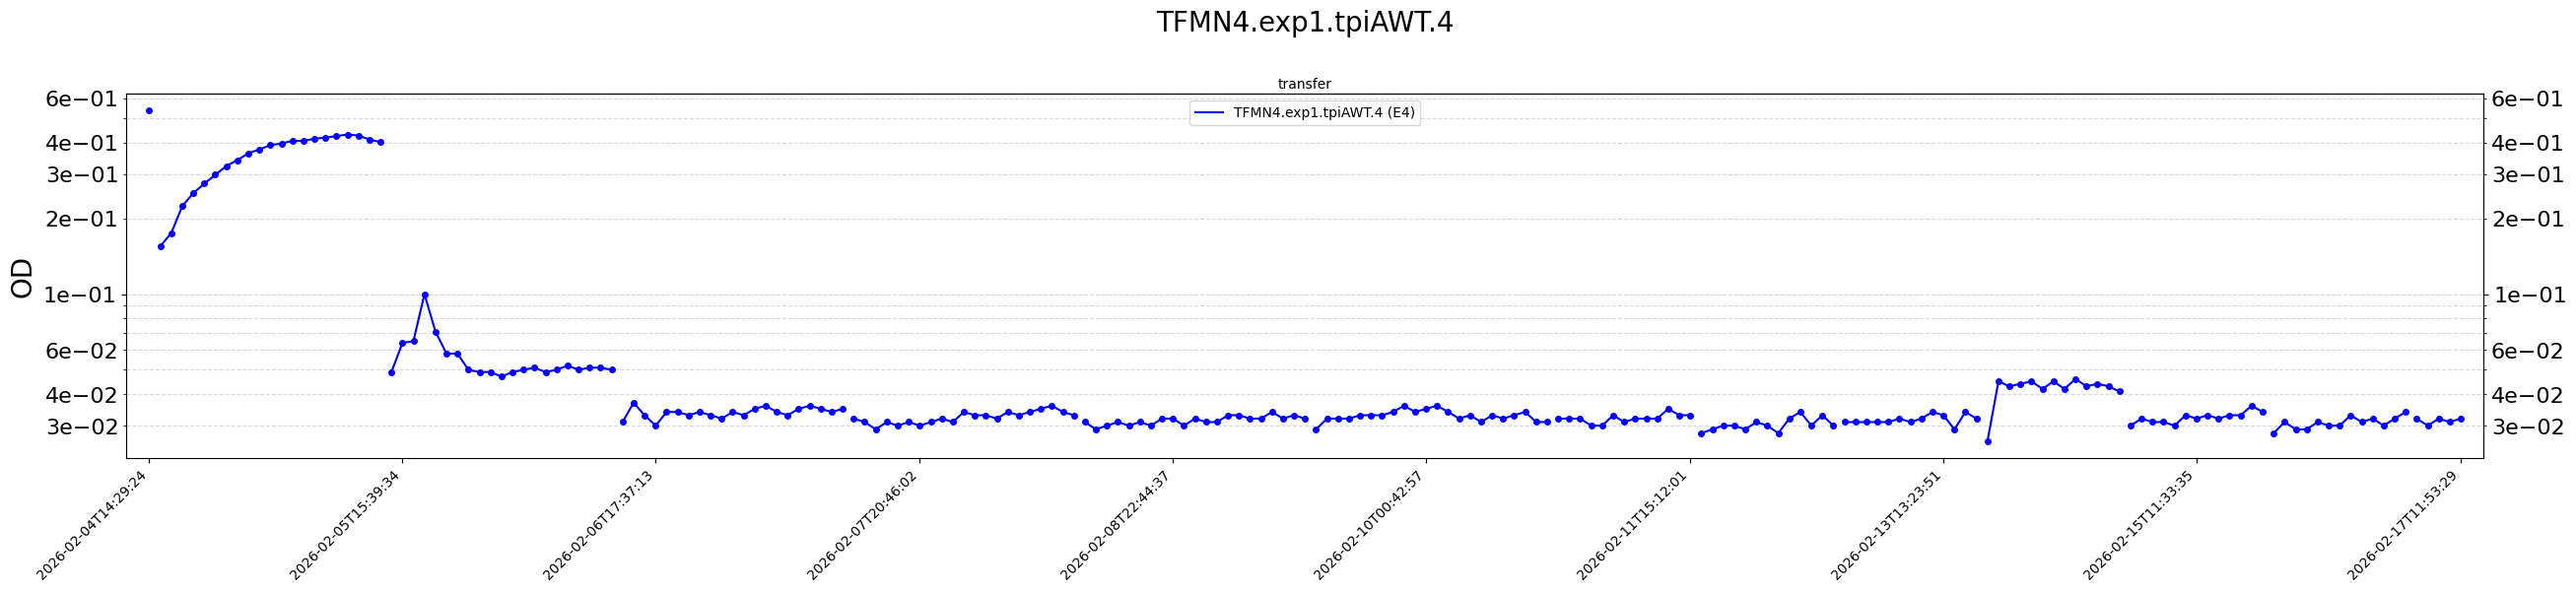

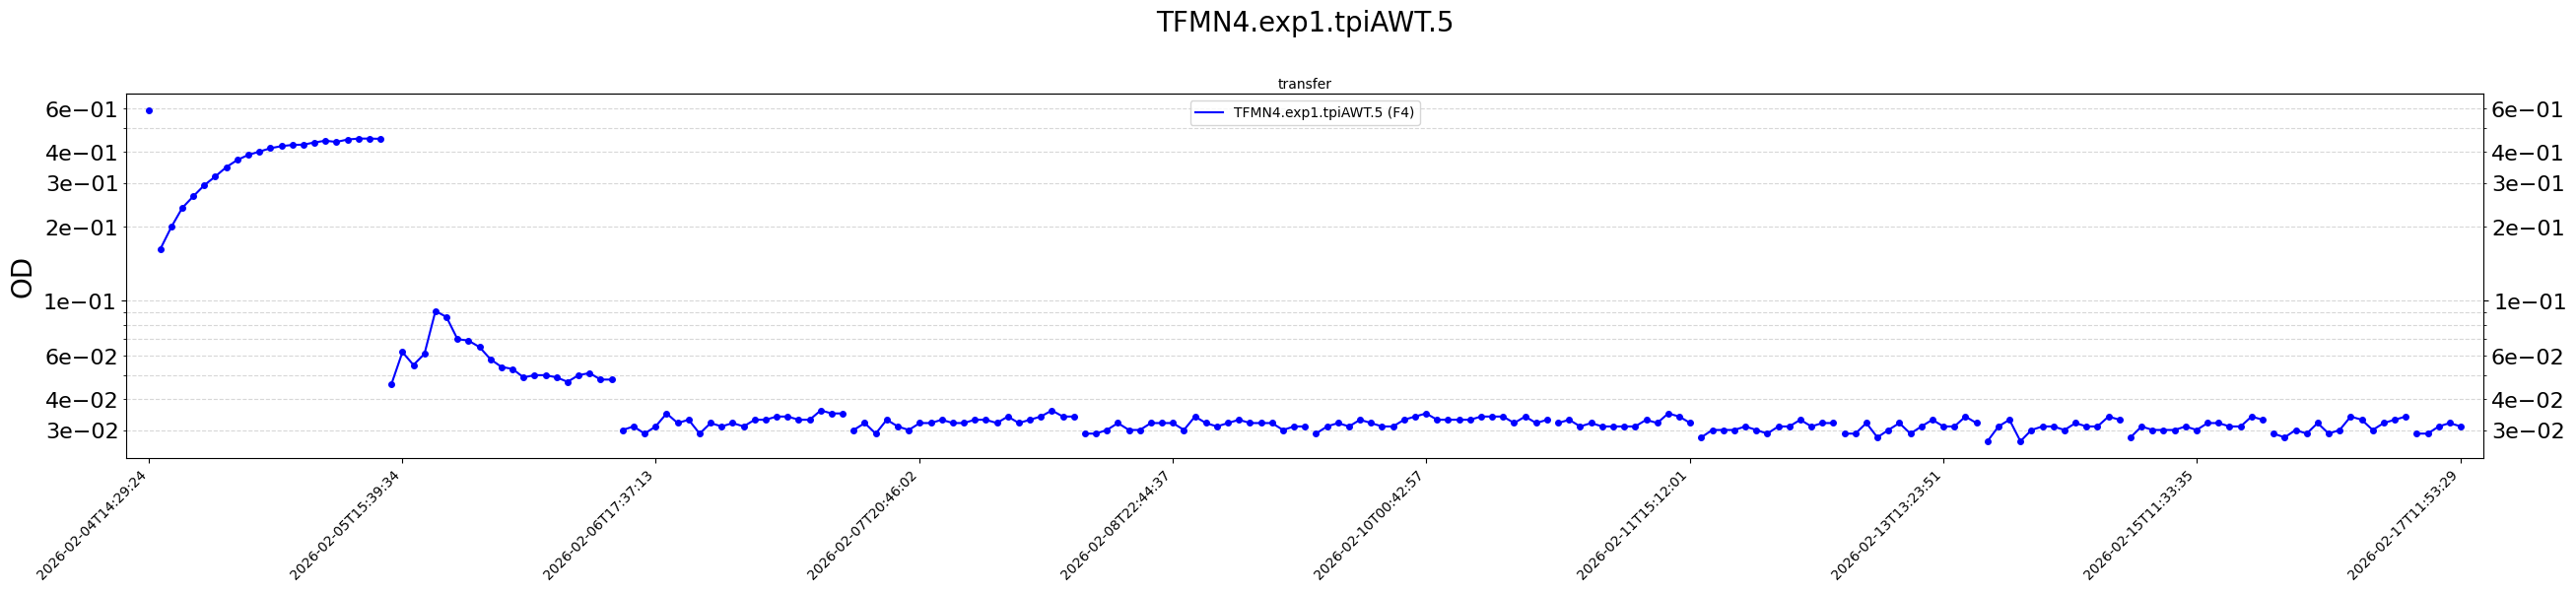

In [171]:
from growth_curve_plotting import plot_OD_replicates

for plate_name, exp in test.groupby('Plate name', sort=False):
    for name, group in exp.groupby('Name'):
        plot_OD_replicates(group, subtract_background=False, blank=False,
                            yscale='log', append_title=name, pdf=None)

        

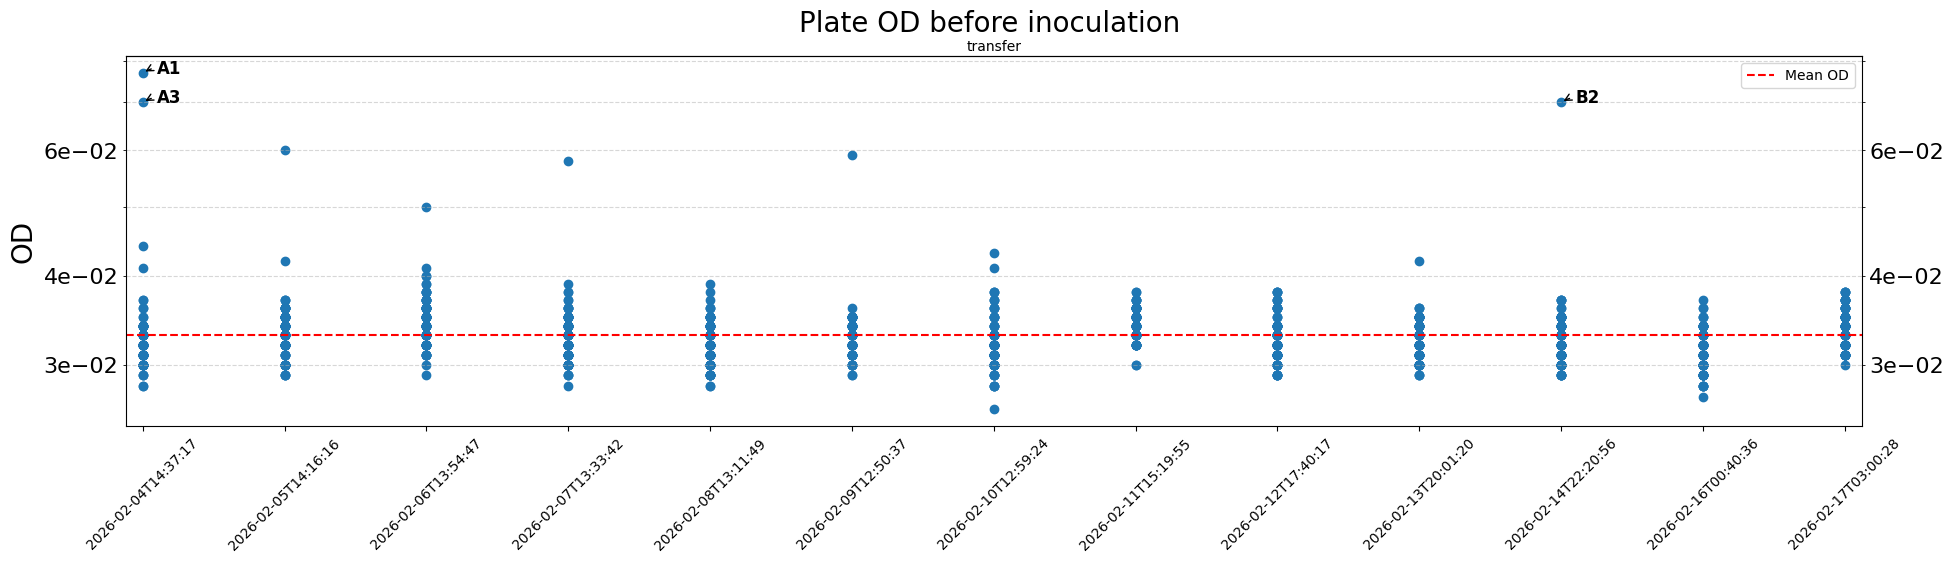

In [166]:
from growth_curve_plotting import plot_OD_contam

plot_OD_contam(contam, subtract_background=False,
                yscale='log', append_title='Plate OD before inoculation', pdf=None)

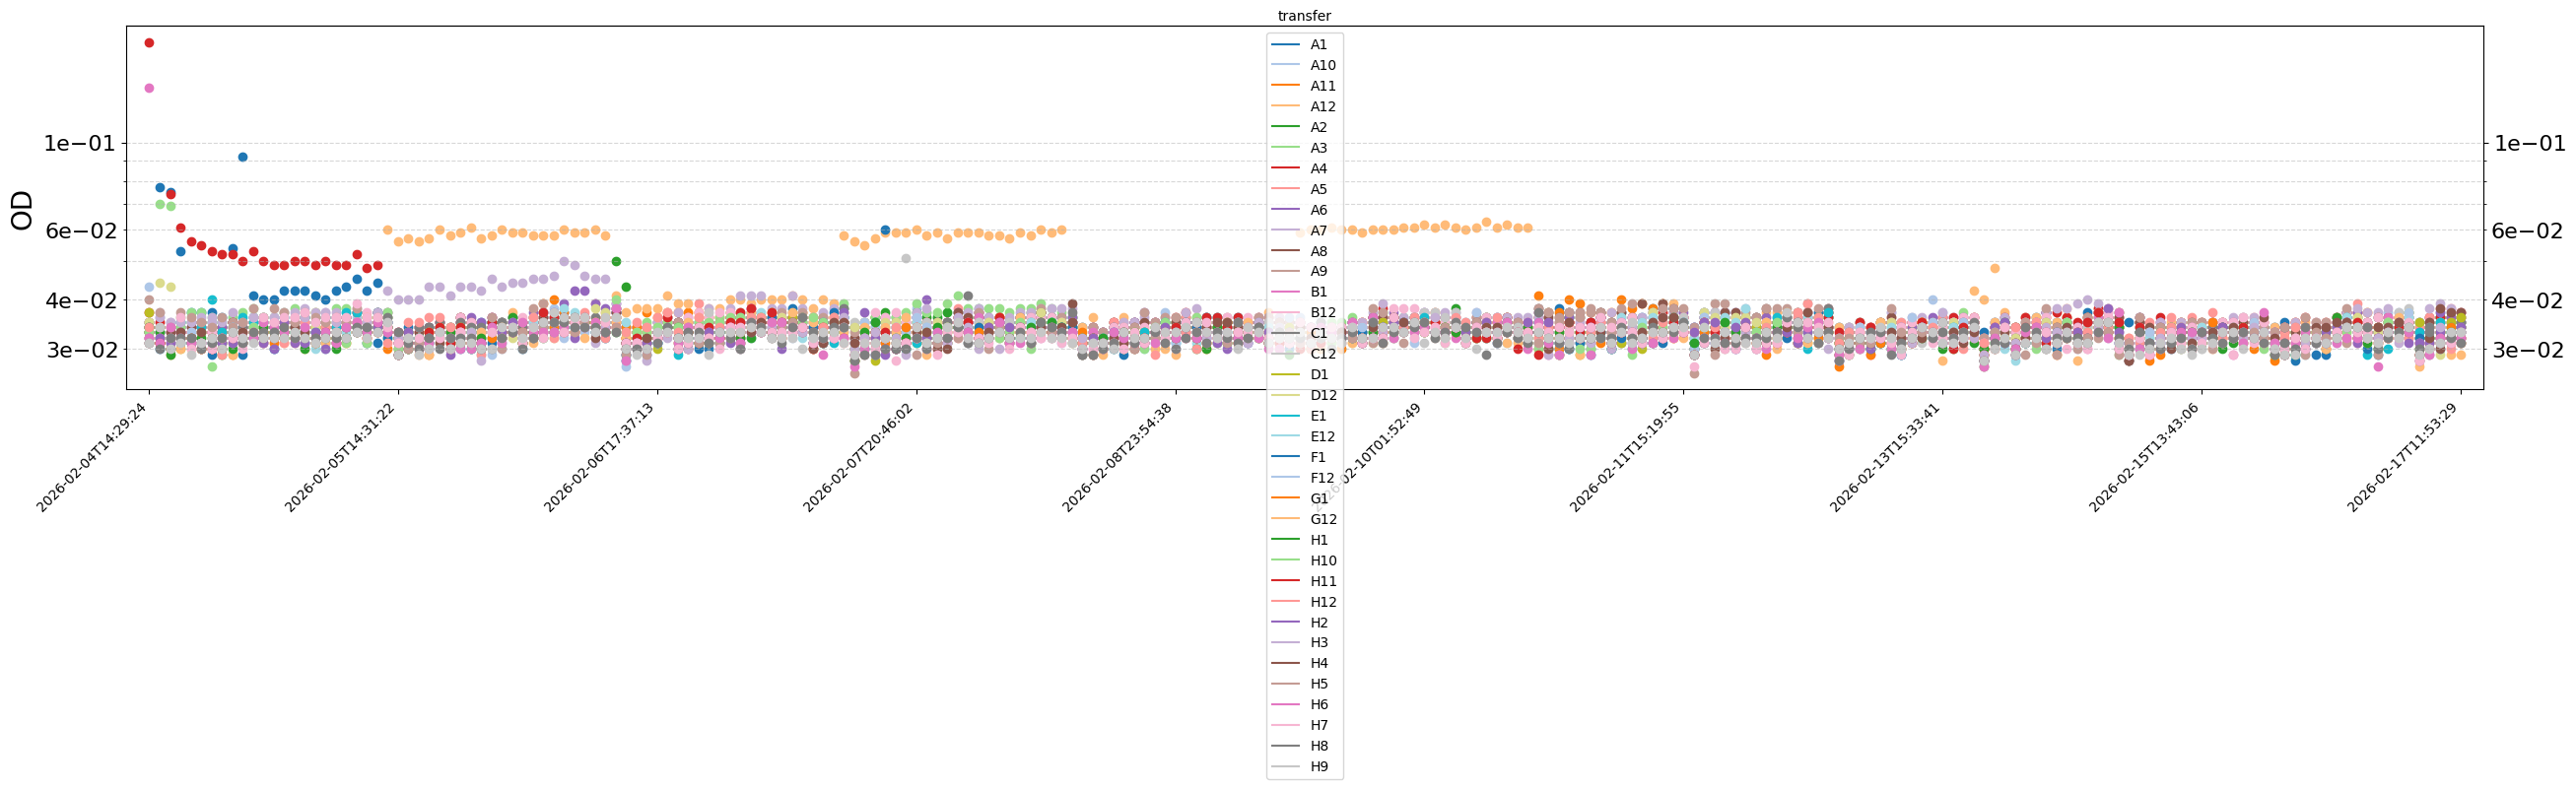

In [169]:
plot_OD_replicates(blank, subtract_background=False, blank=True,
                    yscale='log', append_title="", pdf=None)

## Testing Google Drive upload

In [ ]:
## Necessary for running locally (Natascha's laptop)
## Make sure running in amiga_env

import sys

sys.path.append('/Users/nataschaspahr/code/aisynbiopipeline/aisynbiopipeline/limsapi')


In [4]:
%load_ext autoreload
%autoreload 2

In [9]:
from aisynbiopipeline.limsapi.sheets import SheetsReader

ModuleNotFoundError: No module named 'jsonschema'

In [8]:
from aisynbiopipeline.limsapi.googledrive import get_drive_service, find_file_in_folder, upload_or_replace

ModuleNotFoundError: No module named 'jsonschema'

In [13]:
import sys
sys.path.insert(0, '/Users/nataschaspahr/code/AISynbioPipeline/aisynbiopipeline/limsapi')

from googledrive import get_drive_service, find_file_in_folder, upload_or_replace

service = get_drive_service()

ImportError: attempted relative import with no known parent package

In [7]:
file_path = '/Users/nataschaspahr/Downloads/tmp/WTN32D_trimmed_multiqc_report.html'
folder_id = '19gvG0_brALNGVIKR-OALZpQRoIzd3xEH'

upload_or_replace(file_path, folder_id)

- somewhere (in the repo?) need a place to list google drive file IDs

What's working?
Using my exisiting auth token, can upload to our LIMS Drive.

I need to figure out at what point they get generated, what determines where they go, can I determine, where they go, am I uploading as nspahr08?

Make everything work on laptop from repo, only accessing files in repo. auth creds need to be in .gitignore
Make everything work on poplar from repo, only accessing files in repo. auth creds need to be in .gitignore


In [1]:
import sys
import os

# Add project root to path for access to workflows and tasks
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)

if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import os

# Must add environment's bin to the PATH inside the notebook
env_bin = os.path.join(os.path.dirname(sys.executable), "")
os.environ["PATH"] = env_bin + ":" + os.environ["PATH"]